In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from _aux import loadmat_h5
import os
import SimpleITK as sitk
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy import ndimage
from pandas import DataFrame

In [2]:
data_dir = 'D:/Wayan/LightBead/method paper/dico data/slices/zscored/2000/'                                                   
fname = '04032024_6f_a2_r5_n2000_labels.h5'   
labels = loadmat_h5(os.path.join(data_dir, fname))
# A path to a T1-weighted brain .nii image:
stack_file = f'{data_dir}04032024_6f_a2_r5_mean_G.nii'


In [3]:
l = labels['labels']
#reshape into dimensions of stack (voxels in each ROI)
roi_pos_raw = l.reshape((226,512,27)) # For LBM 28Hz
#roi_pos_raw = l.reshape((226,216,27)) # For LBM 60Hz
#roi_pos_raw = l.reshape((256,128,47)) # For conventional 2p
# rotate image
roi_pos = np.rot90(roi_pos_raw,k=2,axes=(0,1))
roi_pos = np.flip(roi_pos,axis = 1)


In [4]:
# read in a volumetric image 

# Read the .nii image containing the volume with SimpleITK:
sitk_t1 = sitk.ReadImage(stack_file)

# and access the numpy array: (z, x, y)
volume_img_raw = sitk.GetArrayFromImage(sitk_t1)

volume_img_reordered = np.moveaxis(volume_img_raw, [0], [2])

# rotate image
volume_img = np.rot90(volume_img_reordered,k=1,axes=(0,1))



In [5]:
# LIGHTBEAD ONLY: handle the offset (~5 pixels per slice in X, two stacks: 0-12, 13-27) WIP, how many overlaps
first_slice_center_idx = 6 #: 0-12, 13 slices
second_slice_start = 13
second_slice_center_idx = 20 #: 13-27, 15 slices

step_size = 5 #pixels
stack_offset = 10 #pixels
stack_yoffset = 25 #pixels 25

volume_shifted = np.zeros_like(volume_img)

for idx in range(27):
    if idx <= first_slice_center_idx:
        xoffset = (first_slice_center_idx-idx)*5
        volume_shifted[:,:,idx] = np.pad(volume_img[:,:,idx],((0,xoffset),(0,0)), mode = 'minimum')[xoffset:(226+xoffset),:]
    elif idx > first_slice_center_idx and idx < second_slice_start:
        xoffset = (idx-first_slice_center_idx)*5
        volume_shifted[:,:,idx] = np.pad(volume_img[:,:,idx],((xoffset,0),(0,0)), mode = 'minimum')[0:226,:]
    elif idx >= second_slice_start and idx <= second_slice_center_idx:
        xoffset = (second_slice_center_idx-idx)*5 + stack_offset
        volume_shifted[:,:,idx] = np.pad(volume_img[:,:,idx],
                                         ((0,xoffset),(0,stack_yoffset)),
                                         mode = 'minimum')[xoffset:(226+xoffset),stack_yoffset:(512+stack_yoffset)]
    elif idx > second_slice_center_idx:
        xoffset = (idx-second_slice_center_idx)*5 + stack_offset
        volume_shifted[:,:,idx] = np.pad(volume_img[:,:,idx],
                                         ((xoffset,0),(0,stack_yoffset)),
                                         mode = 'minimum')[xoffset:(226+xoffset),stack_yoffset:(512+stack_yoffset)]



# after padding, delete slices 9 is about the same as 13? let's delete slices 10-13 for now
#volume_shifted_cut = np.delete(volume_shifted,[10, 11, 12, 13], axis=2)

In [6]:
#Import auditory ROIs
data = pd.read_csv(data_dir + 'audio_roi_04032024_6f_a2_r5_pval_7s.csv',usecols=['ROI'])
audio_correlated = data['ROI'] # cast as series



In [7]:
# This gives the the roi number and the slice it is located in for each of the auditory rois (conversion by ROI num/frame, NO z flip)
slice_audio = (audio_correlated//2000)
roi_audio = audio_correlated - (2000 * (audio_correlated//2000))

In [8]:
# precompute masked ROI volume by finding audio-correlated ROIs

audio_rois = np.zeros_like(roi_pos)

for slice_idx in range(np.size(roi_pos,2)):
    for s,r in zip(slice_audio, roi_audio):
        if s == slice_idx:
            #print(r)
            save_filter = (roi_pos[:,:,s] == r)
            audio_rois[save_filter,s] = r

audio_rois_masked = np.ma.masked_where(audio_rois == 0, audio_rois)

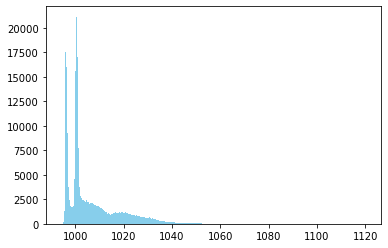

In [32]:
brain_mask = np.zeros_like(volume_img)

for slice_idx in range(0,np.size(roi_pos,2)):
    image = volume_img[:,:,slice_idx]

    pixels = image.flatten()
    # Plot the histogram
    plt.hist(pixels, bins=256, color='skyblue')

    thresh = np.mean(pixels)*1

    brain_mask[:,:,slice_idx] = np.where(volume_img[:,:,slice_idx] >= thresh, 1, brain_mask[:,:,slice_idx])
    



(-0.5, 215.5, 225.5, -0.5)

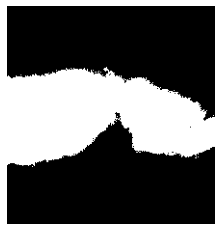

In [31]:
im1 = plt.imshow(brain_mask[:,:,6],cmap = 'gray')

plt.axis('off')

In [23]:
rois_masked = np.ma.masked_where(brain_mask == 0, roi_pos) 

In [33]:
audio_rois_masked_brain = np.ma.masked_where(brain_mask == 0, roi_pos) & np.ma.masked_where(audio_rois == 0, audio_rois)

In [29]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

cmap_base = 'jet' #gnuplot
vmin, vmax = 0.0, 3.0  # -0.8, 1
cmap = truncate_colormap(cmap_base, vmin, vmax)

<ipython-input-34-c11d964c82d7>:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


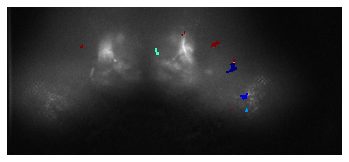

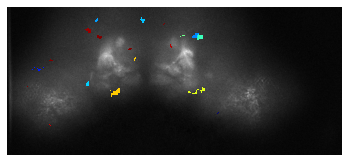

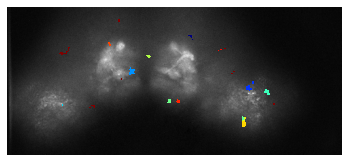

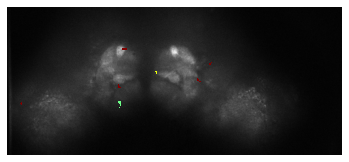

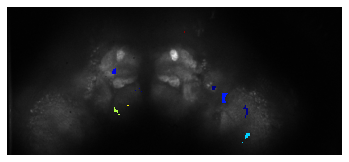

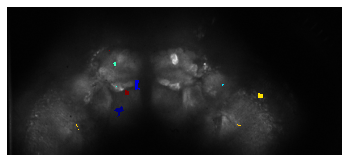

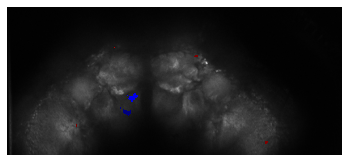

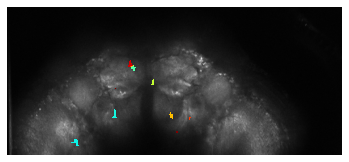

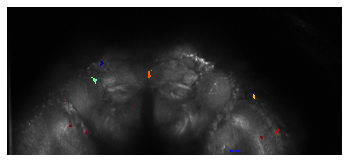

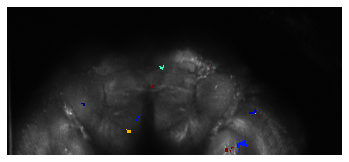

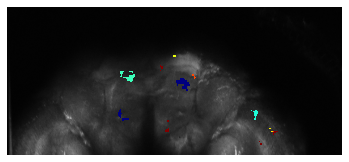

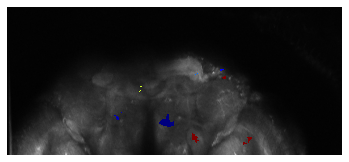

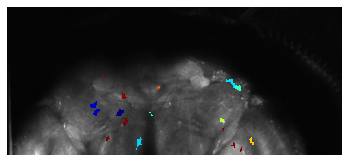

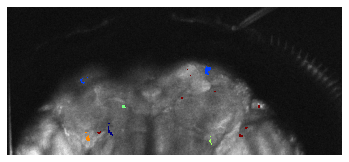

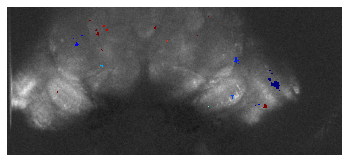

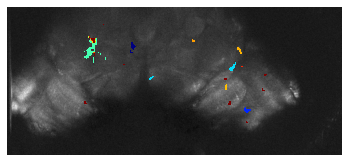

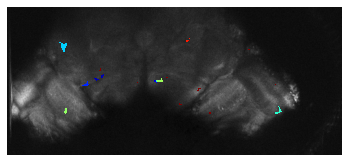

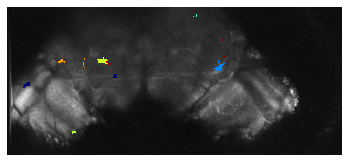

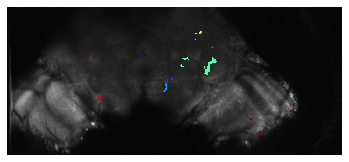

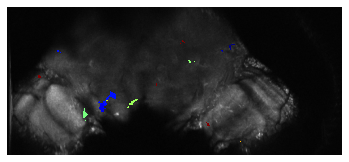

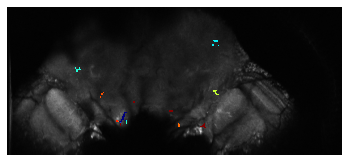

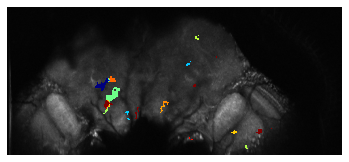

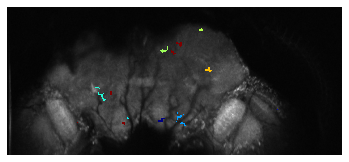

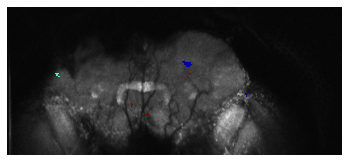

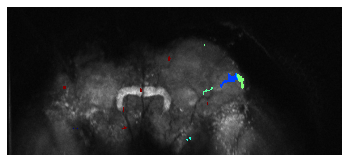

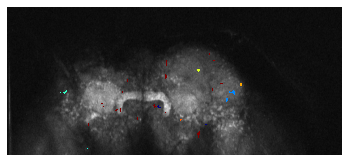

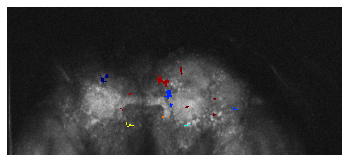

In [34]:
# Plot all rois for each slice no ticks for 3d vis
#path = 'D:/Wayan/LightBead/method paper/dico data/slices/zscored/2000/plots/customized/04032024_6f_a2_r5/'
path = 'C:/Users/wayan.CHRISTAPNI/Princeton Dropbox/Wayan Gauthey/Princeton/Lightbead/Method paper/Figures/Panels/Figure 2/14012025/Revision round 1/suppl corr/slices/04032024_a2_r1/7s/'
#path = 'D:/Wayan/LightBead/method paper/dico data/slices/zscored/60Hz/06202024_a1_r2/'


for slice_idx in range(0,np.size(roi_pos,2)):
    matplotlib.rcParams['pdf.fonttype']=42
    plt.figure()
    im1 = plt.imshow(volume_img[:,:,slice_idx],cmap = 'gray')

    im2 = plt.imshow(audio_rois_masked_brain[:,:,slice_idx], alpha = 1, cmap = cmap) # jet use clim to limit the color range
    #plt.title('Roi {} slice {}'.format(roi_audio[i],slice_audio[i]))

    plt.axis('off')
    
    #plt.savefig(f"{plot_dir}/{slice_idx}_audiocorr_rois.pdf", format="pdf", bbox_inches="tight")
    #plt.savefig(f"{path}/{slice_idx}.png", format="png", bbox_inches="tight", pad_inches=0)
    #plt.savefig(path+str(slice_idx)+'.png',dpi = 300, format="png", pad_inches=0, bbox_inches='tight')

Text(0.5, 1.0, 'Roi 5 slice 491')

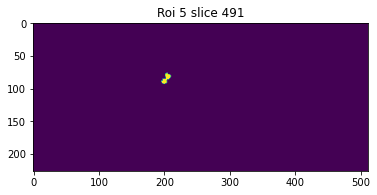

In [29]:
plt.figure()
plt.imshow(roi_pos[:,:,5]==491)
plt.title('Roi {} slice {}'.format(5,491))

<ipython-input-50-f3b6ac4922e8>:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


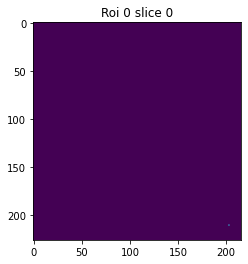

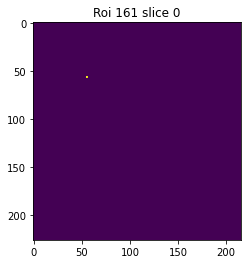

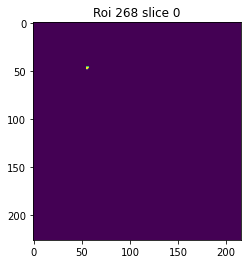

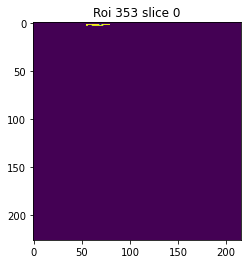

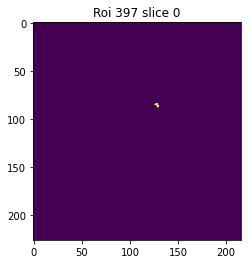

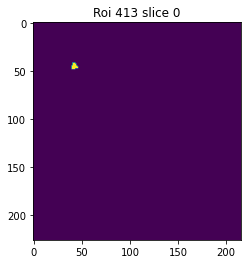

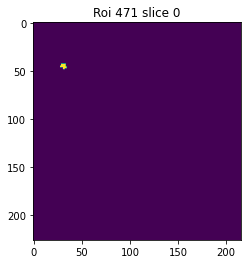

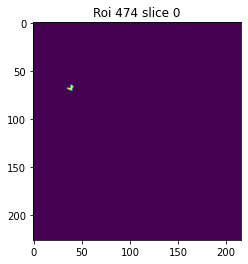

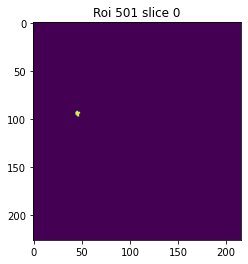

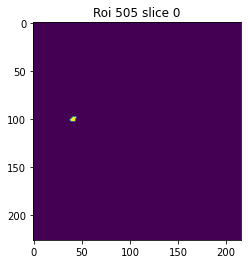

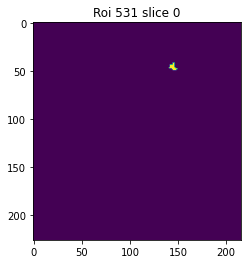

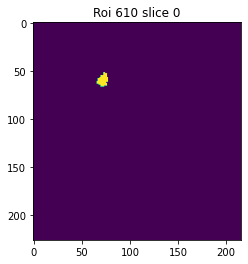

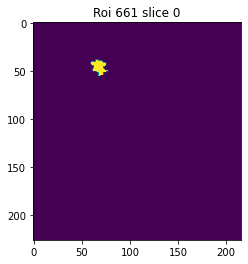

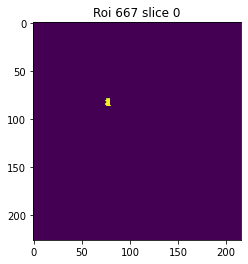

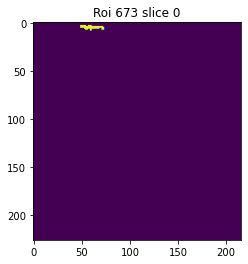

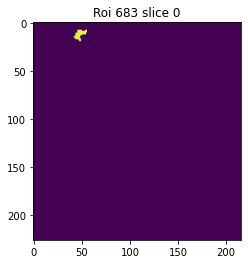

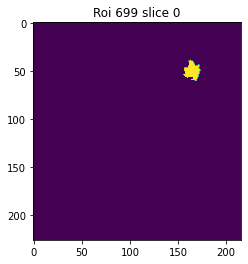

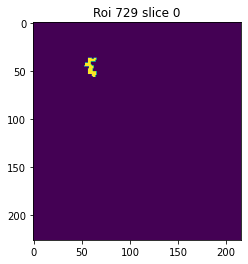

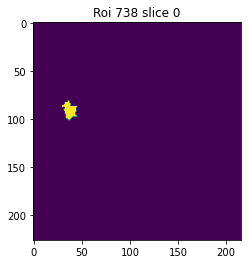

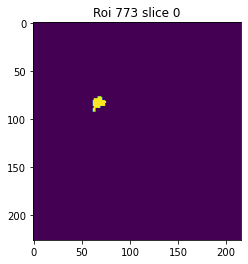

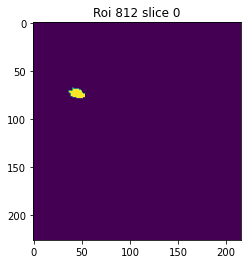

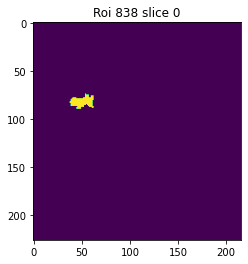

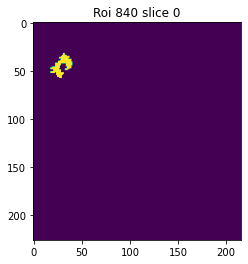

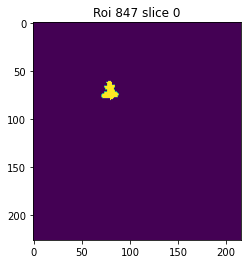

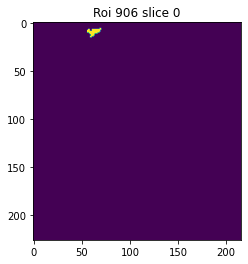

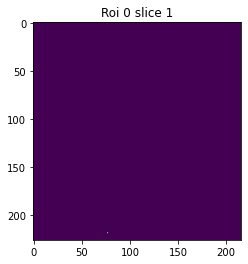

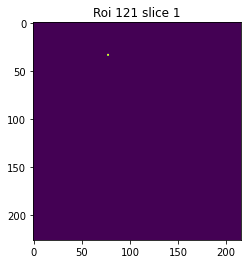

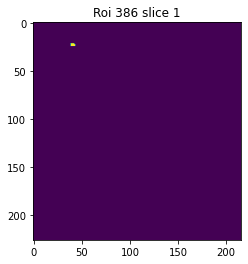

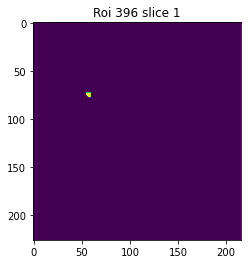

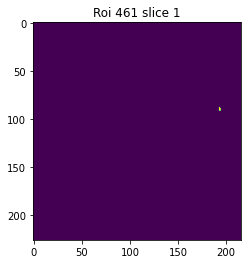

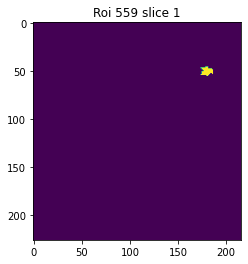

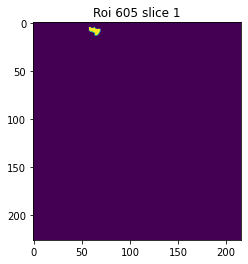

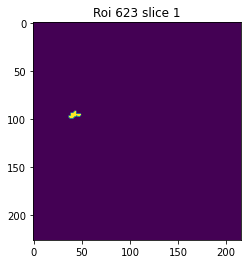

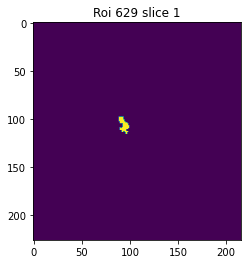

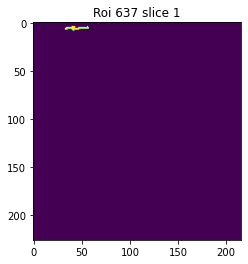

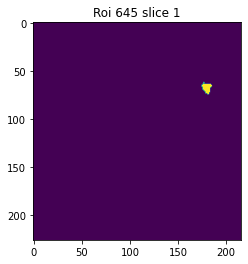

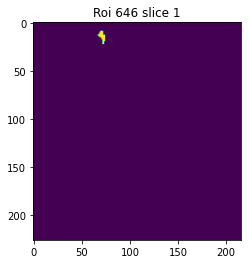

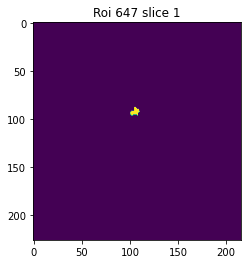

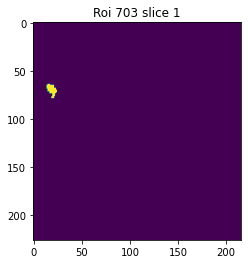

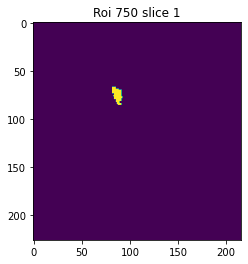

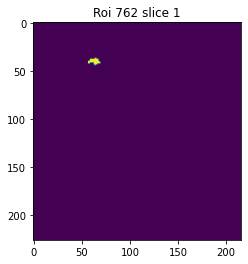

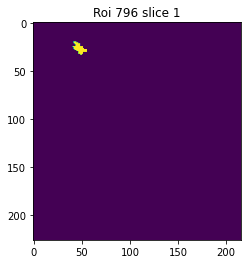

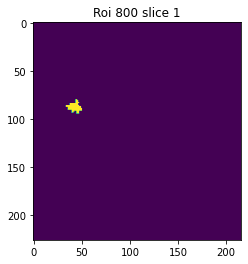

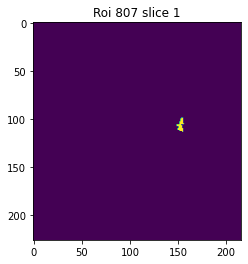

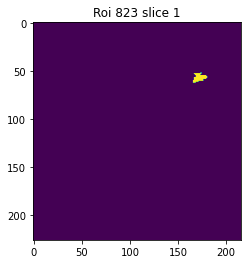

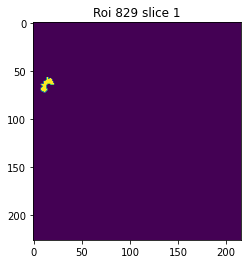

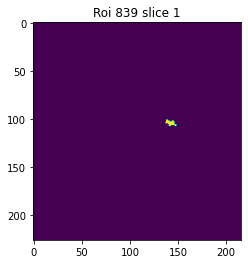

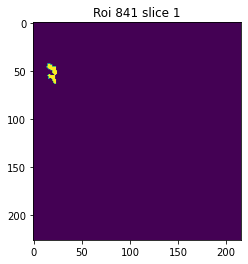

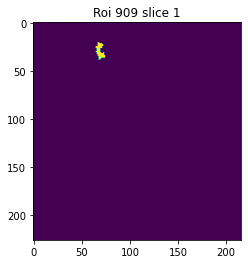

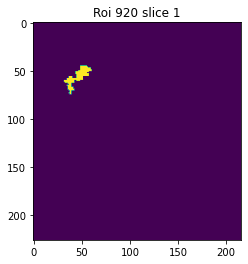

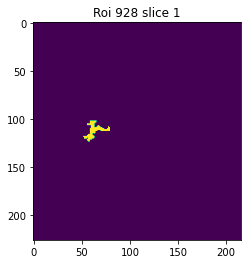

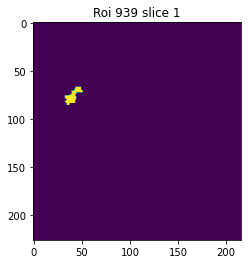

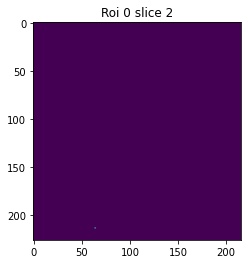

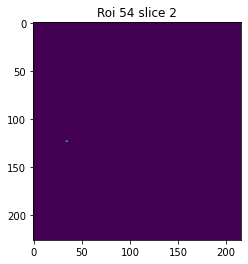

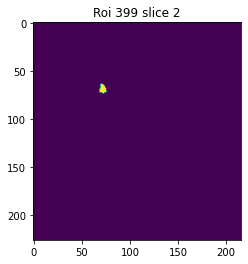

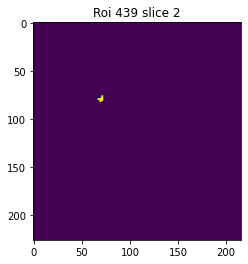

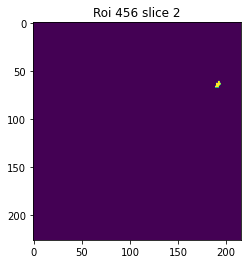

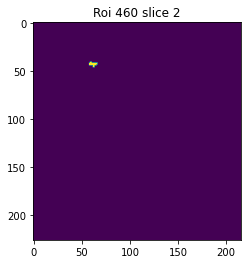

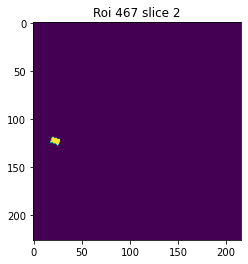

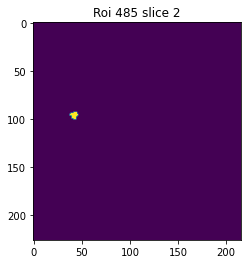

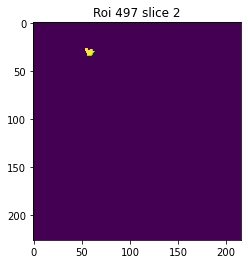

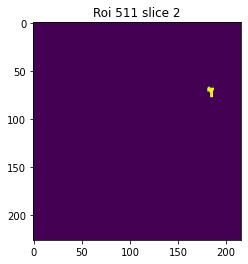

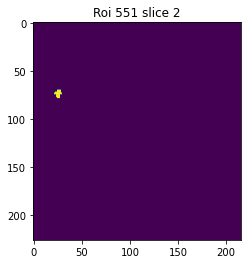

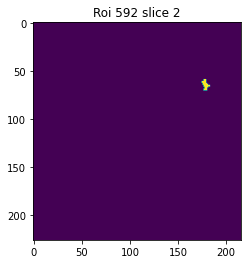

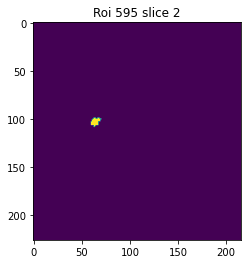

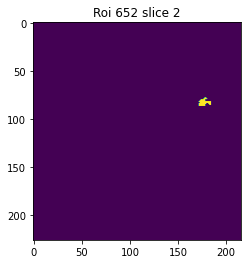

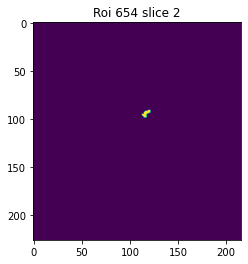

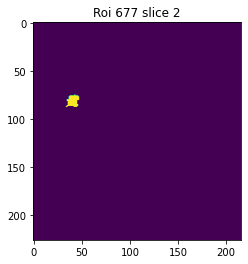

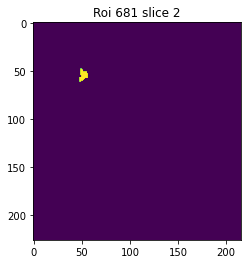

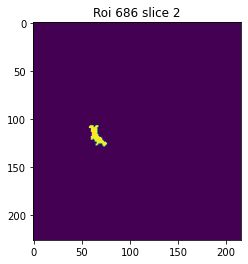

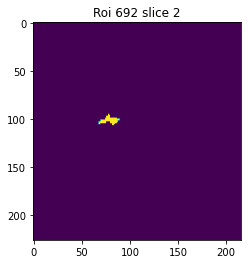

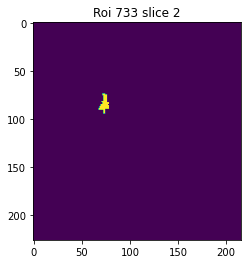

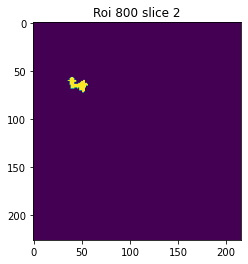

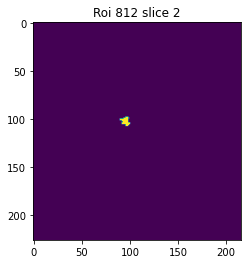

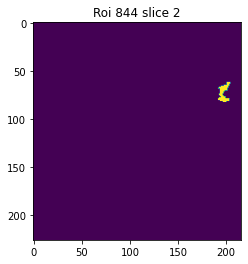

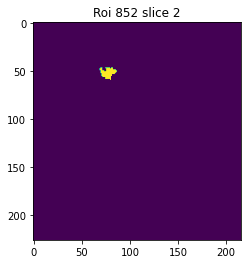

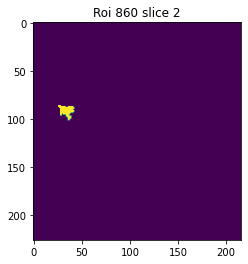

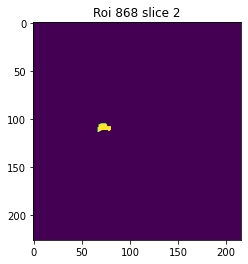

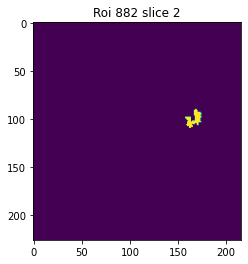

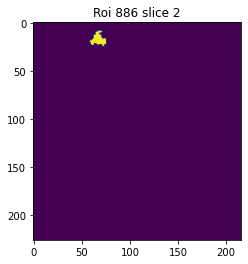

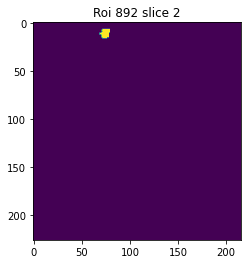

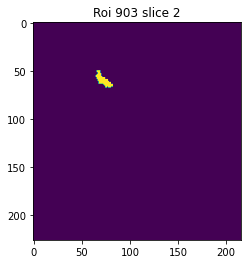

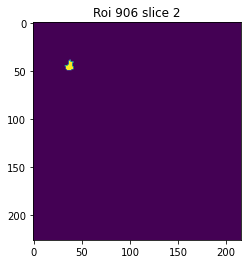

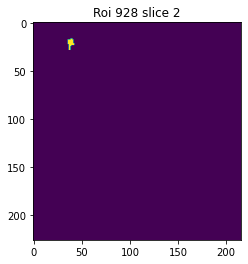

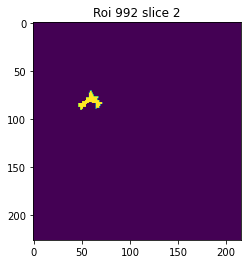

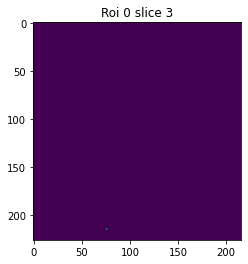

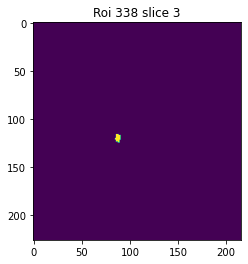

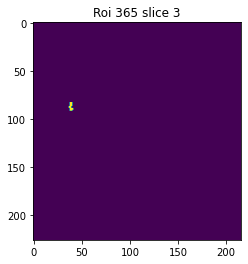

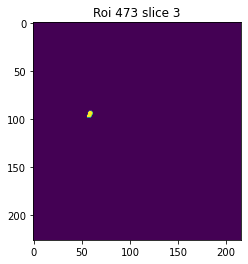

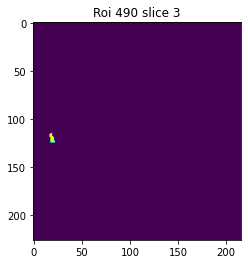

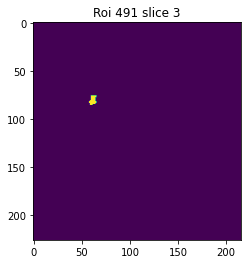

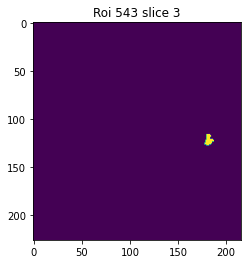

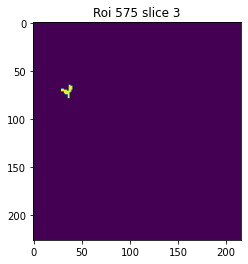

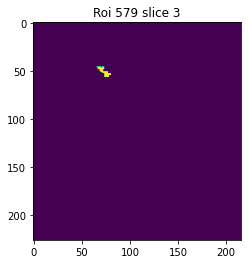

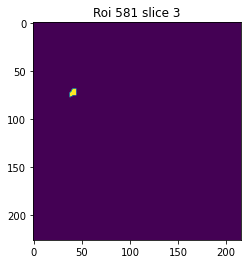

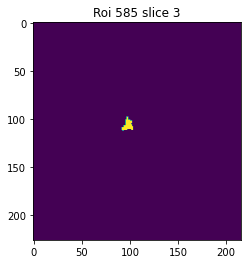

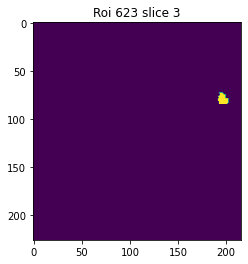

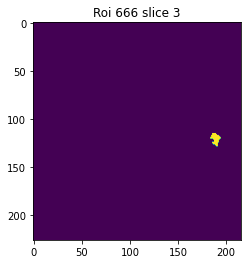

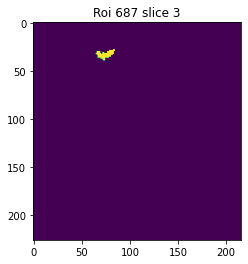

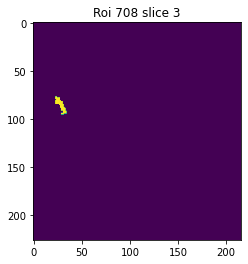

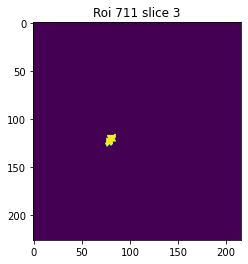

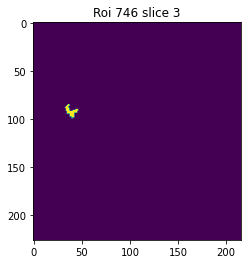

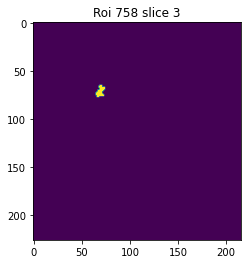

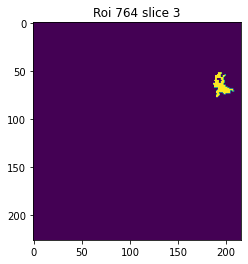

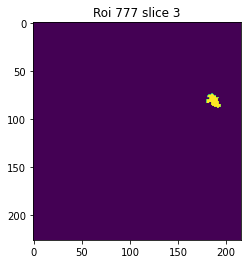

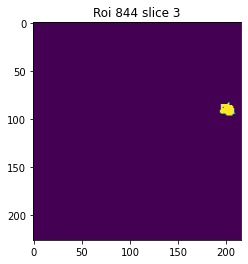

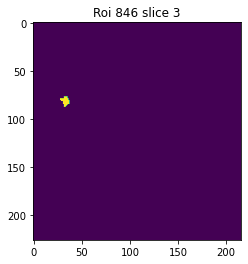

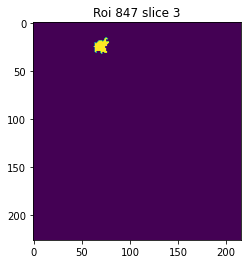

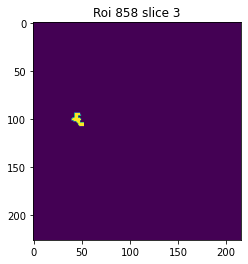

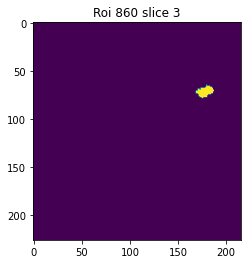

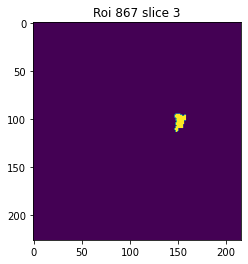

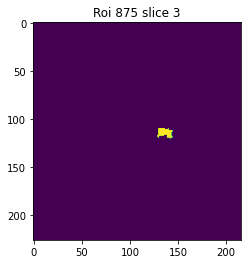

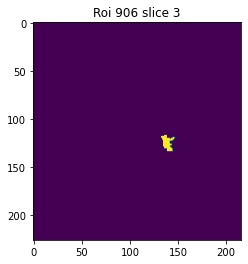

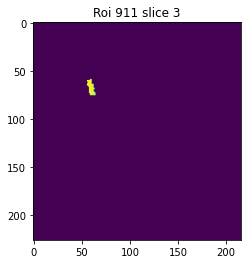

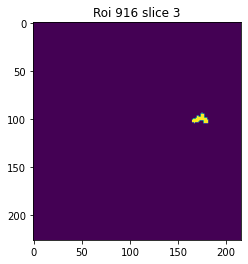

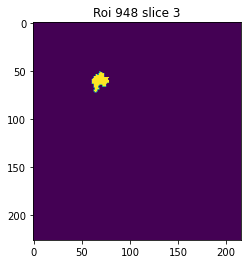

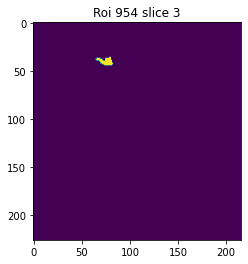

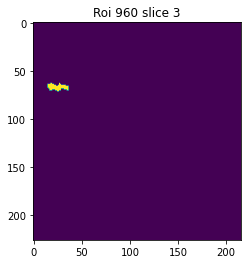

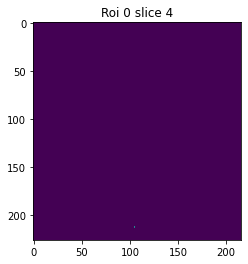

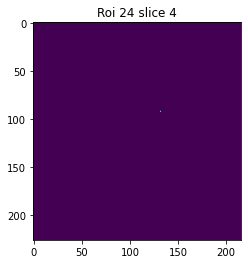

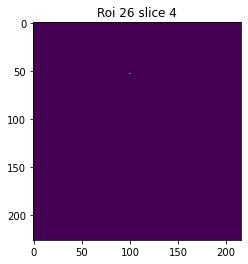

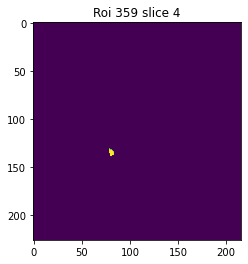

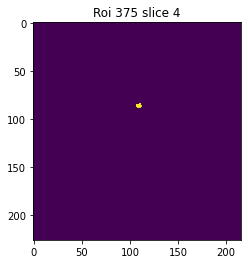

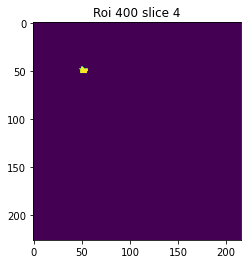

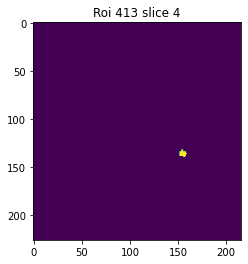

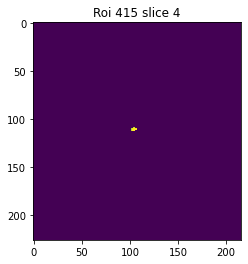

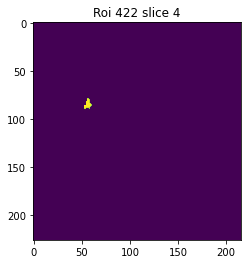

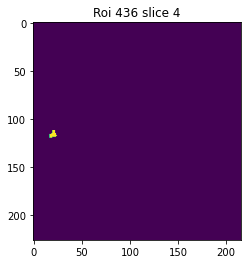

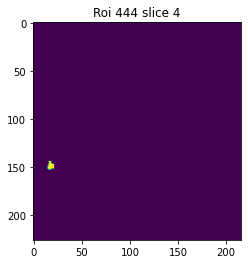

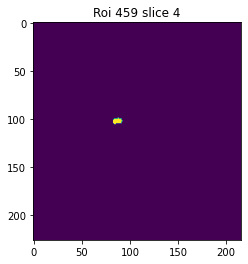

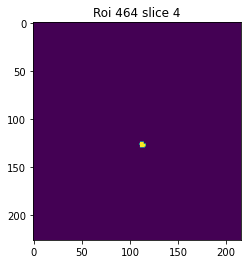

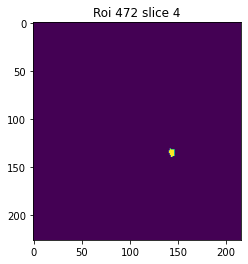

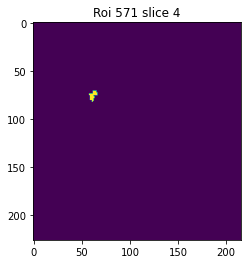

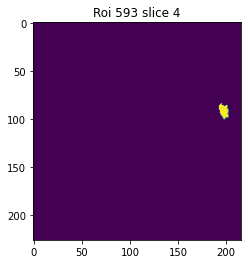

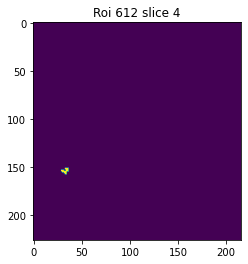

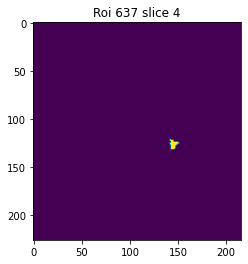

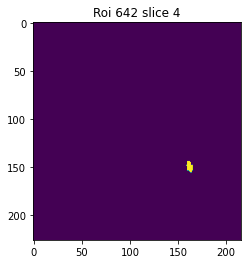

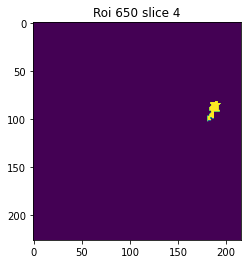

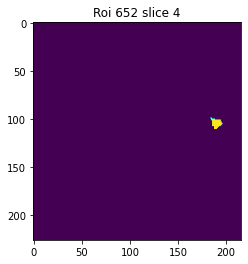

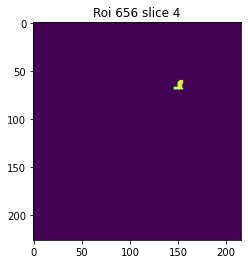

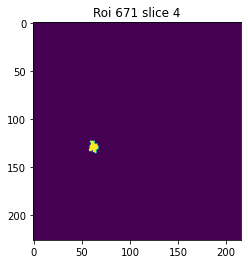

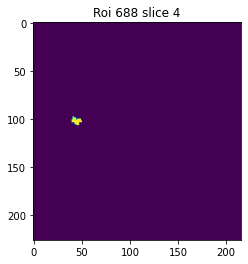

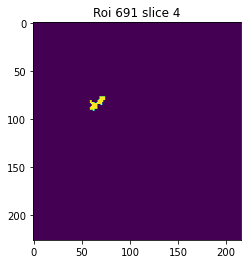

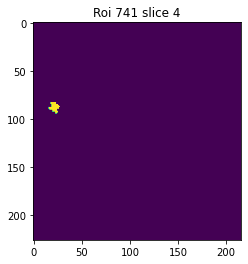

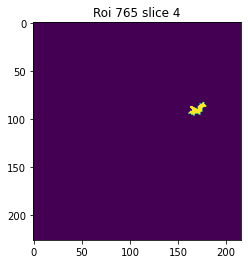

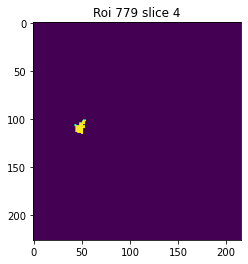

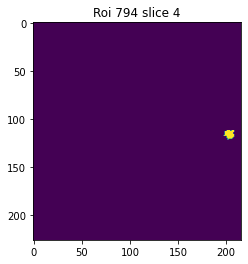

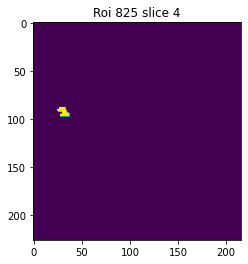

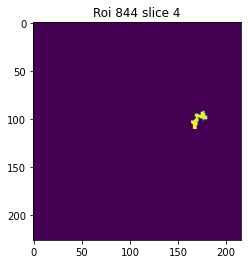

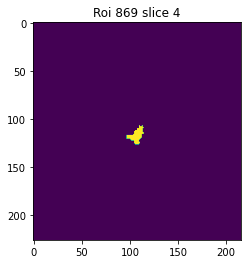

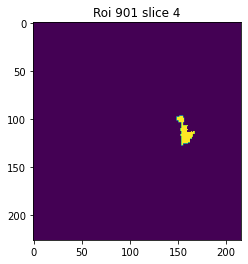

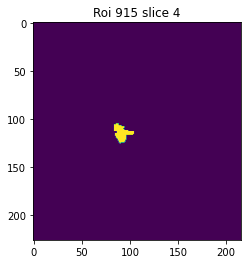

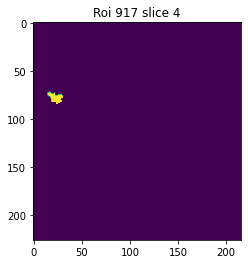

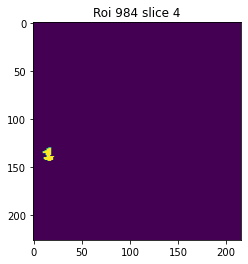

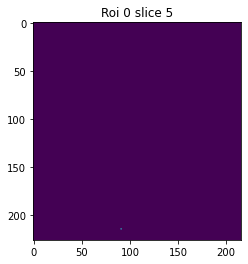

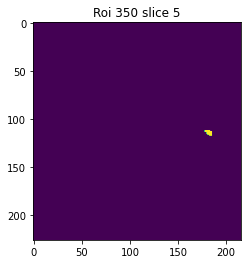

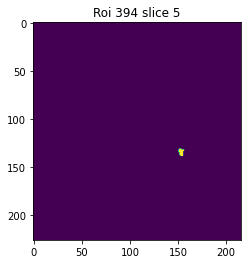

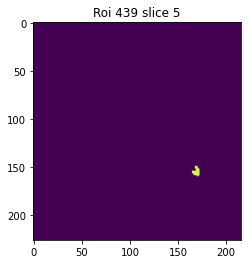

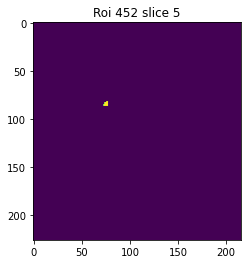

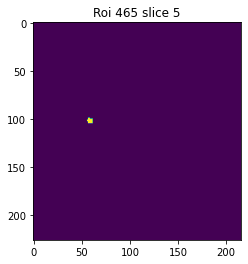

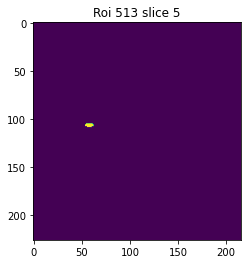

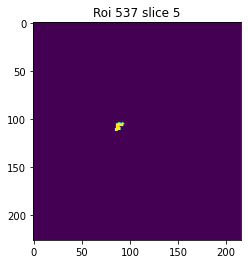

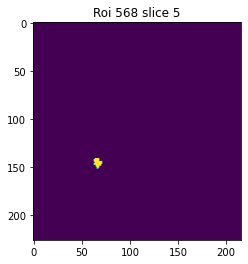

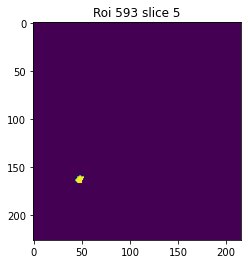

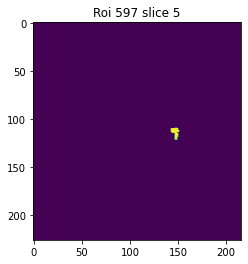

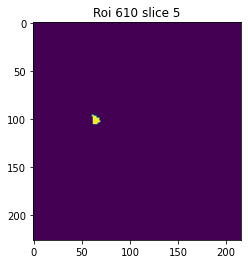

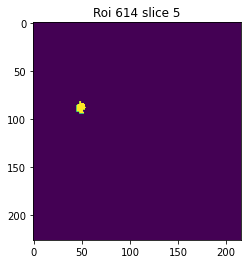

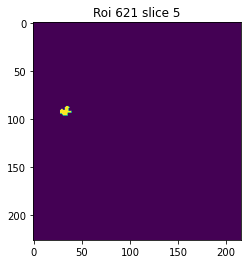

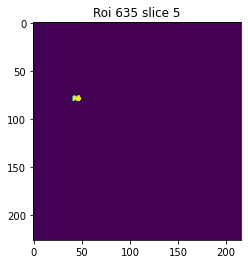

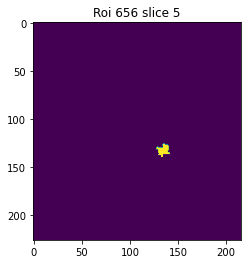

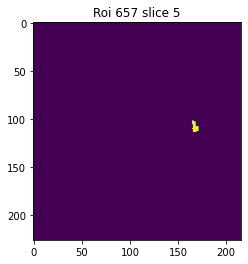

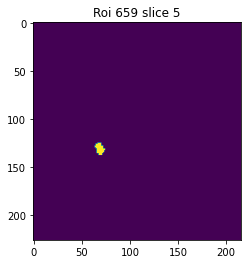

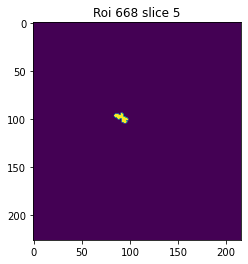

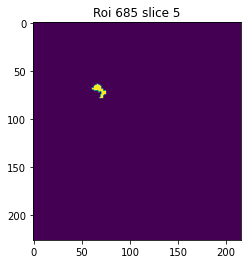

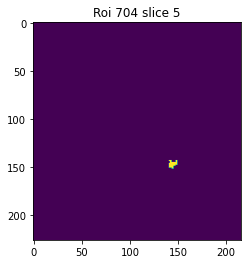

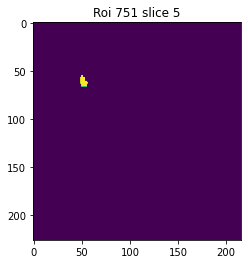

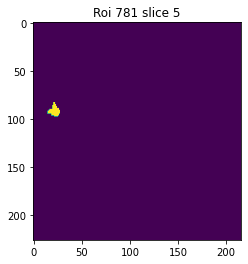

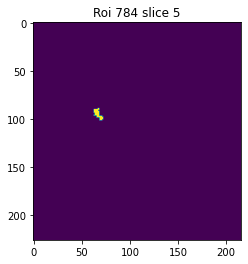

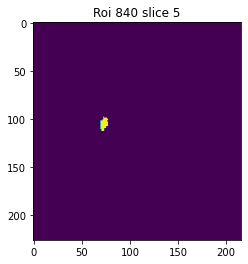

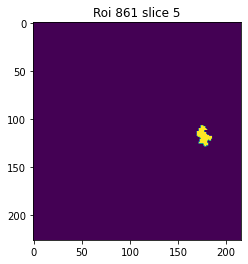

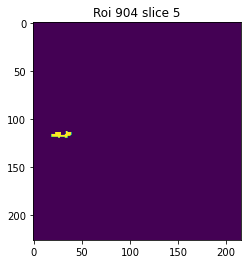

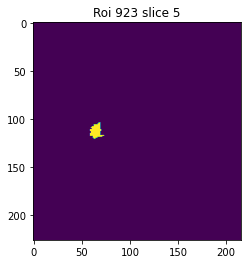

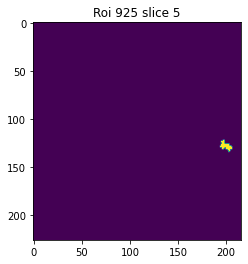

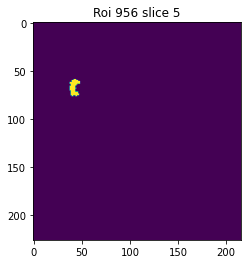

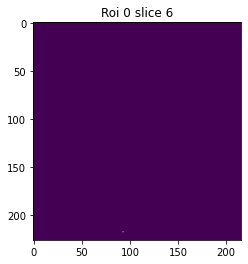

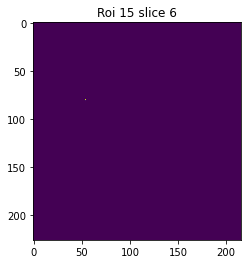

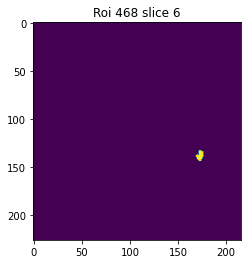

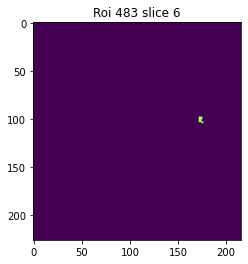

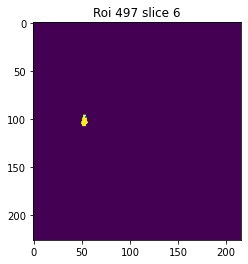

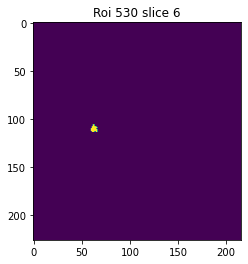

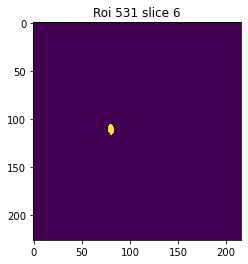

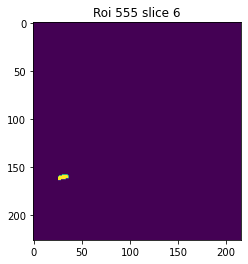

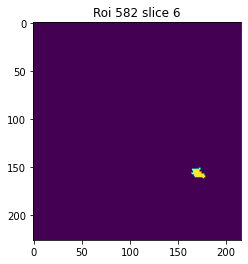

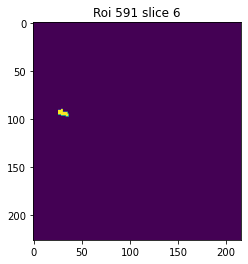

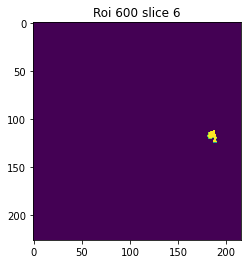

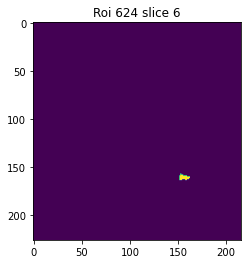

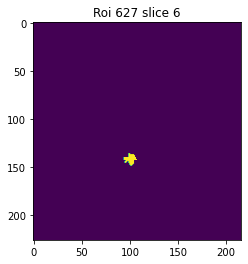

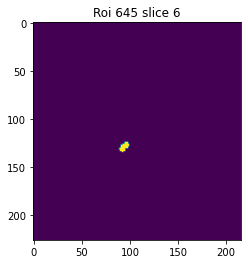

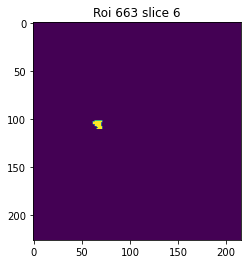

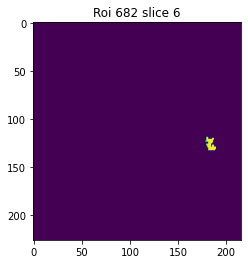

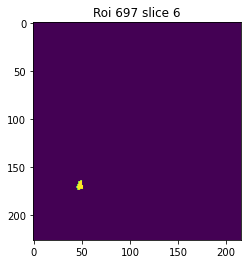

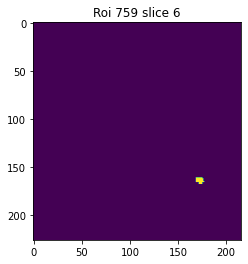

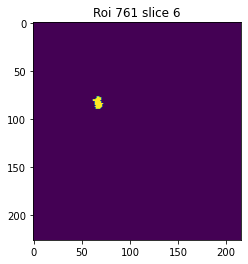

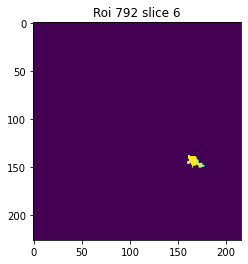

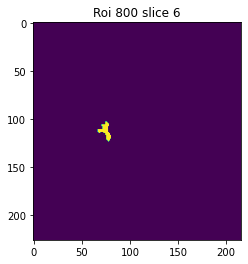

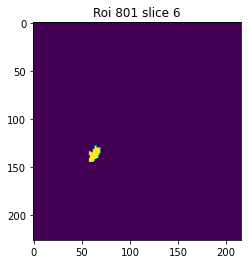

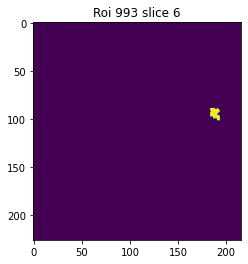

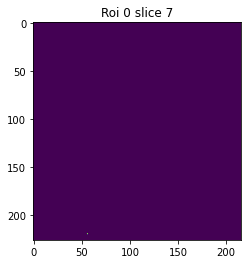

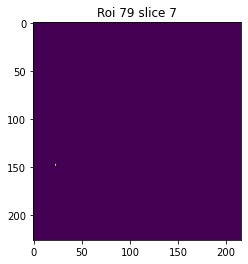

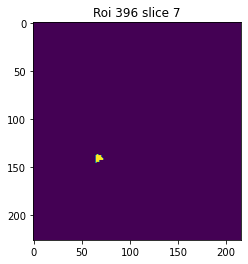

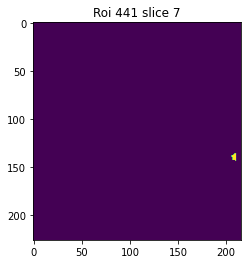

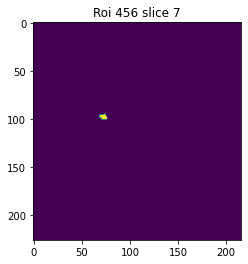

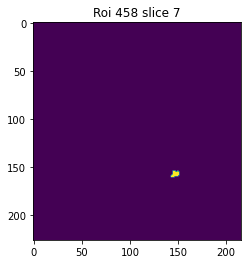

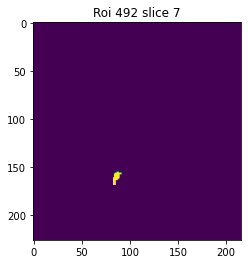

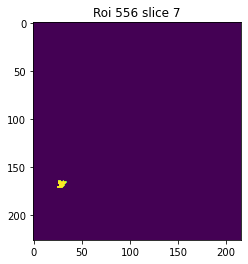

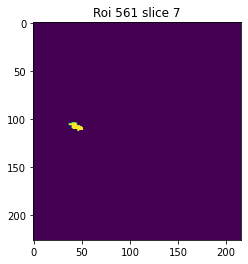

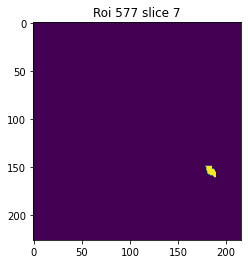

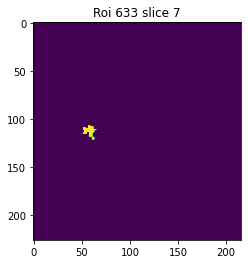

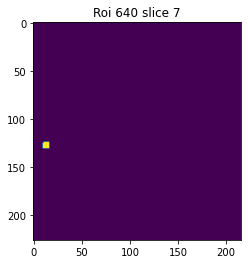

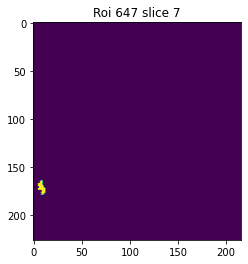

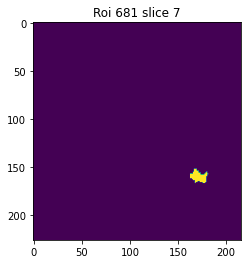

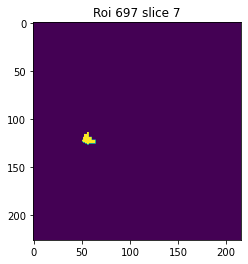

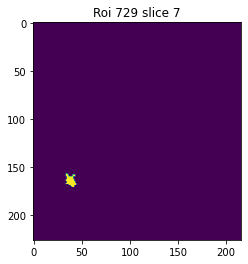

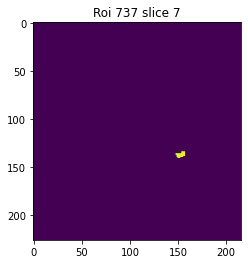

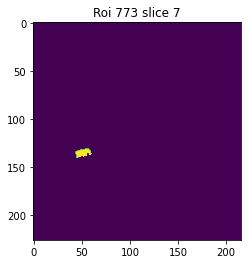

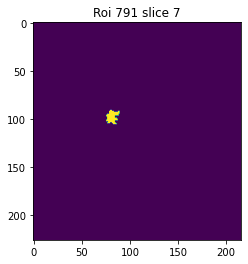

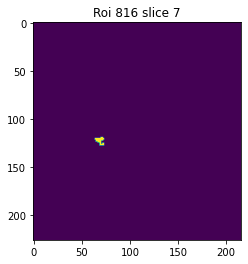

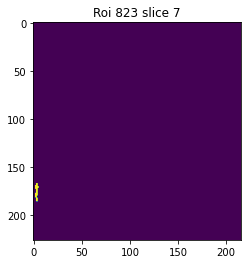

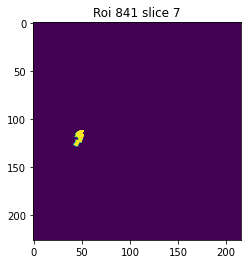

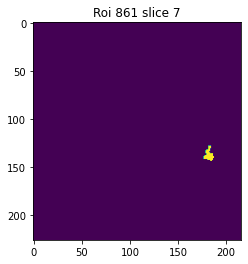

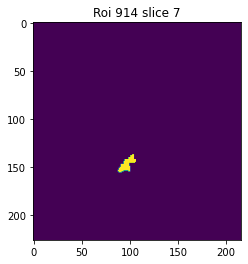

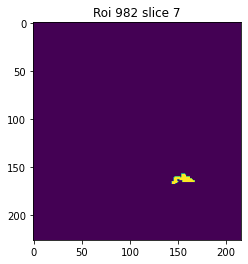

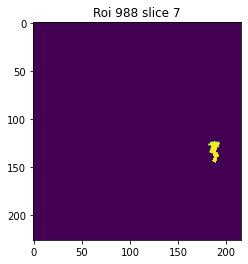

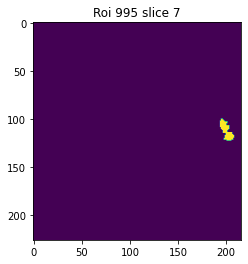

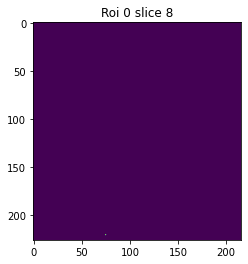

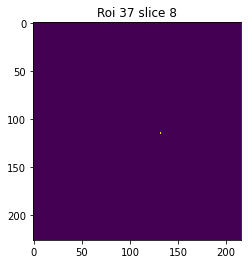

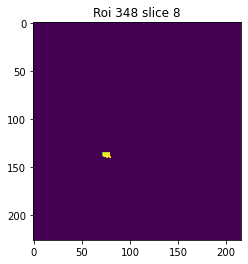

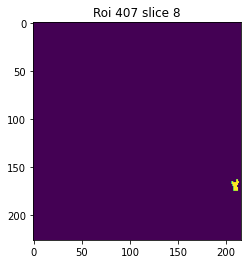

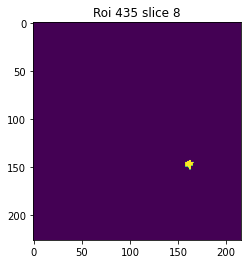

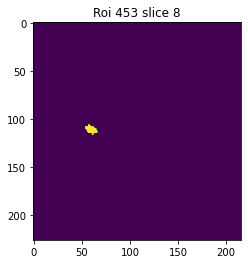

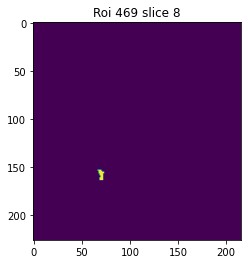

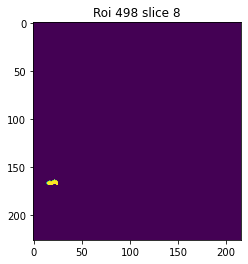

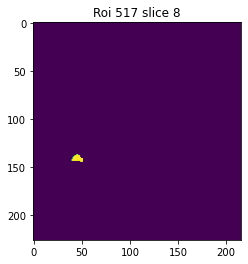

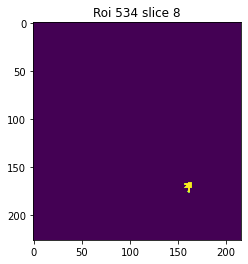

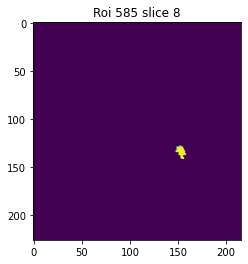

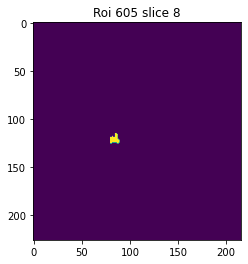

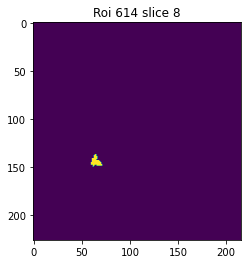

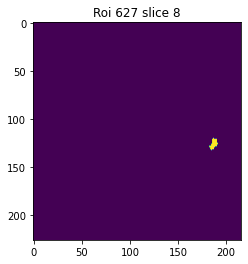

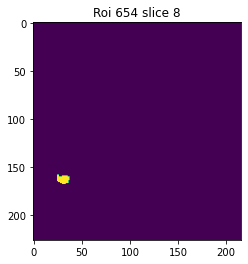

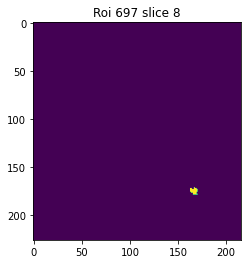

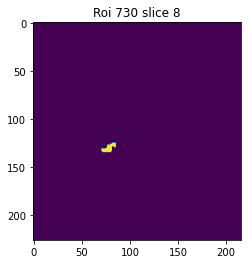

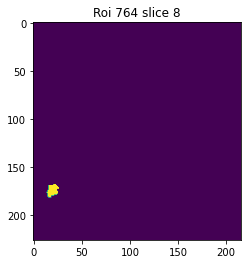

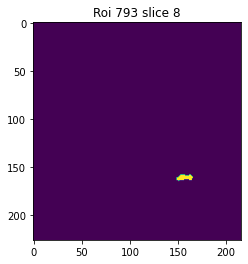

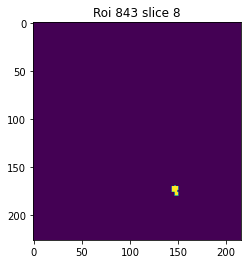

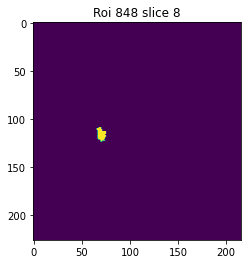

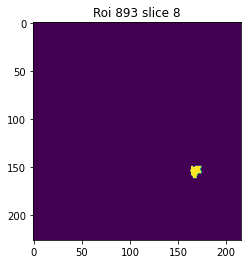

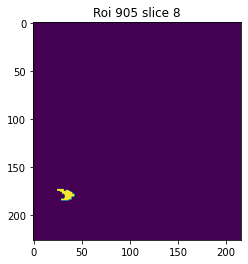

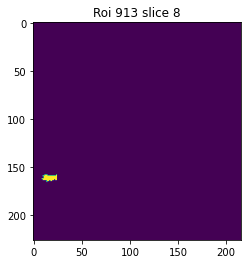

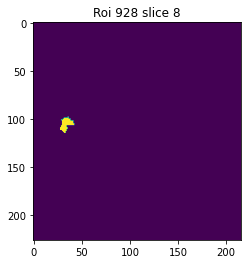

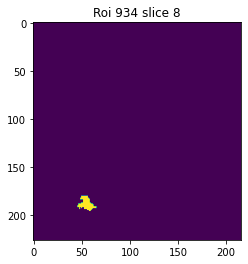

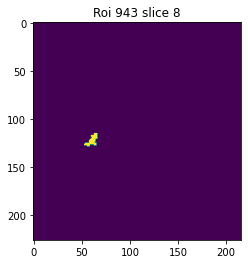

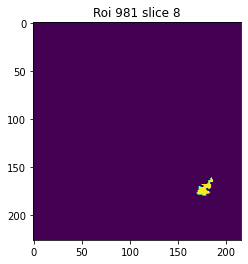

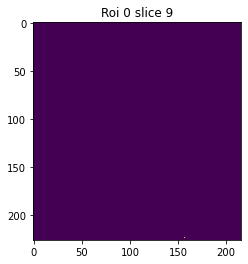

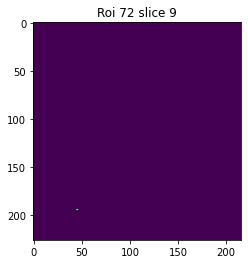

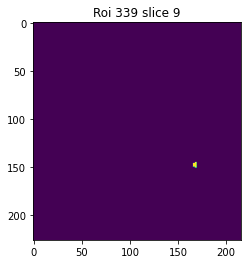

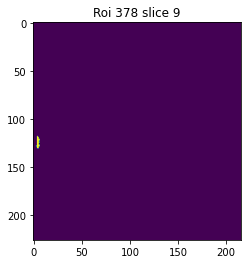

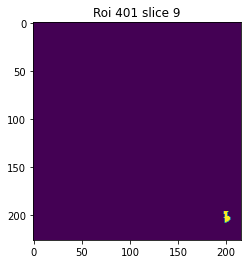

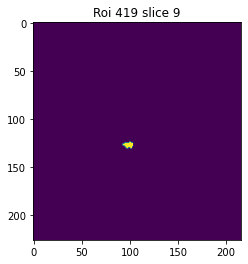

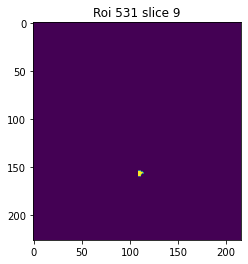

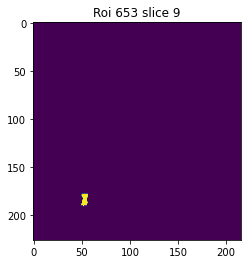

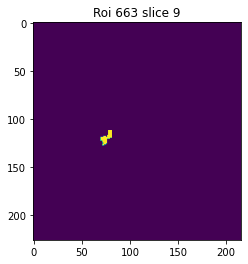

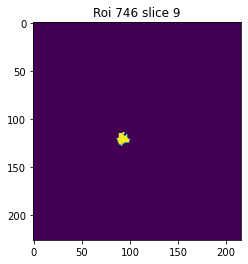

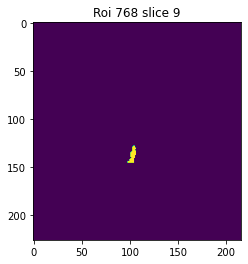

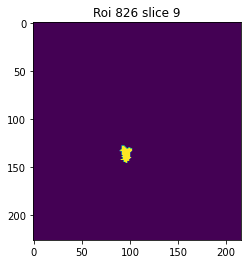

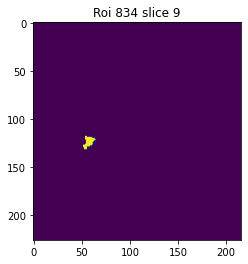

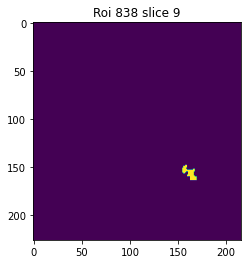

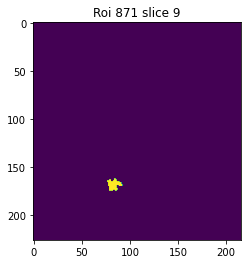

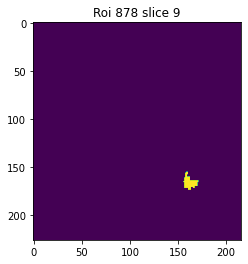

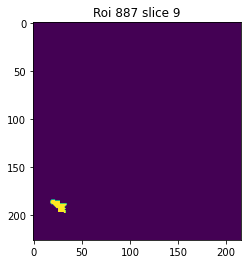

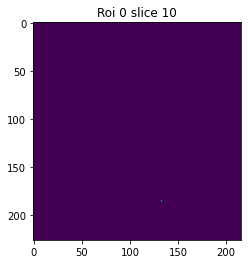

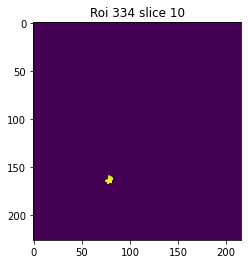

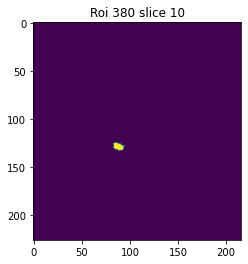

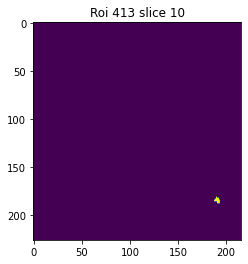

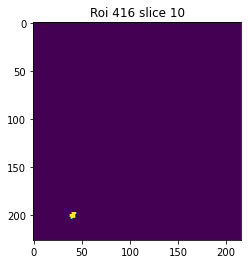

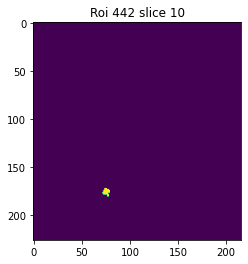

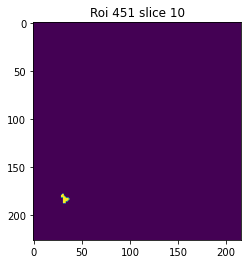

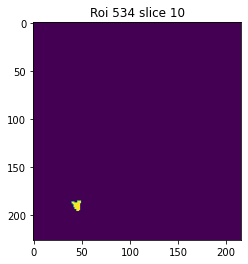

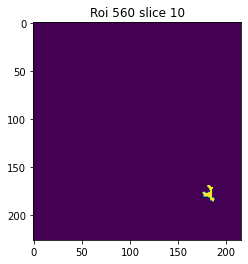

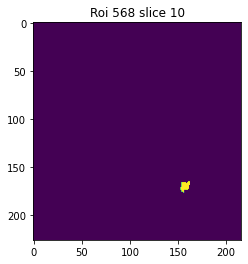

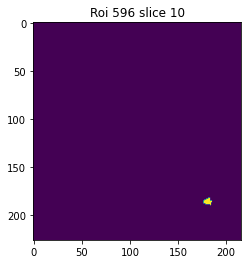

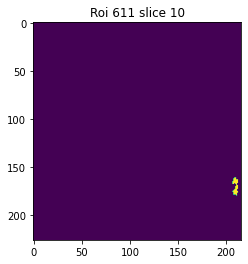

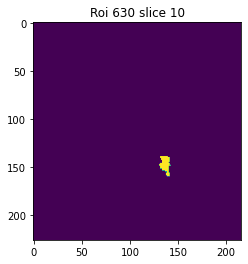

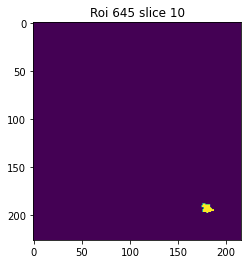

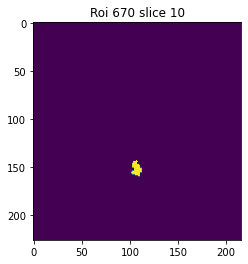

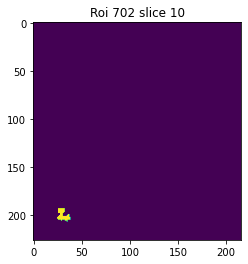

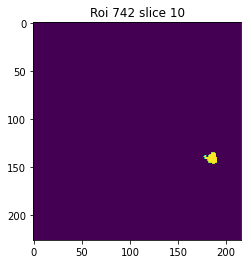

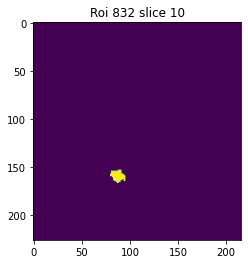

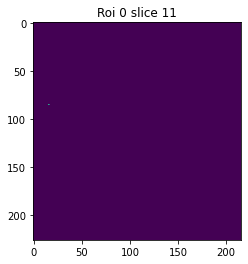

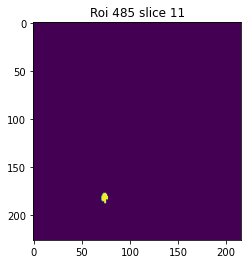

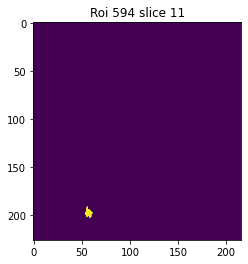

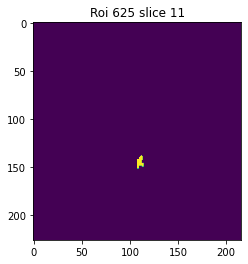

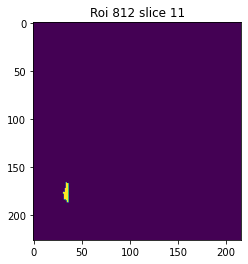

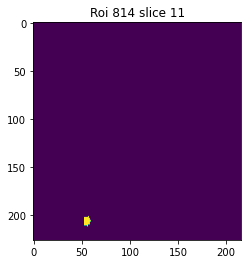

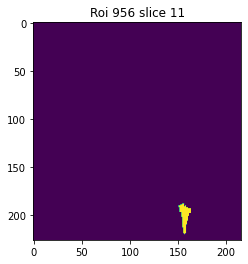

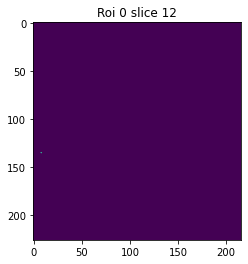

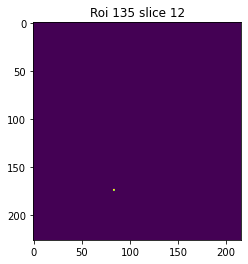

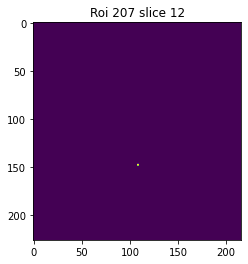

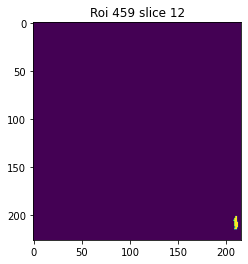

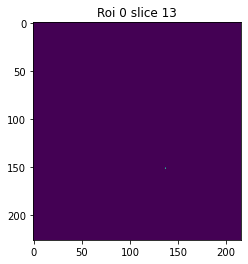

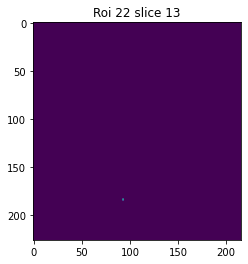

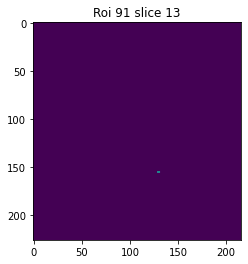

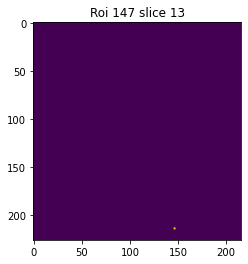

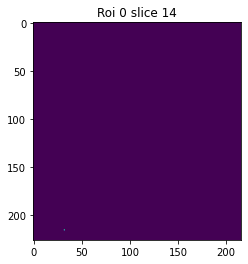

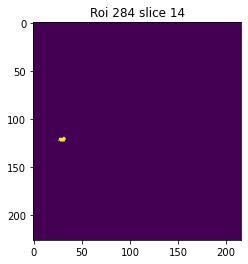

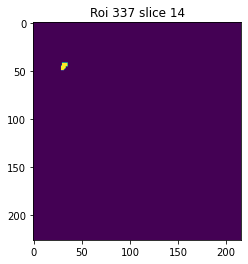

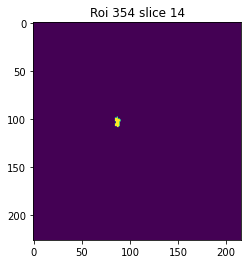

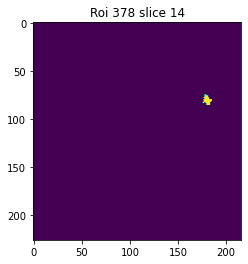

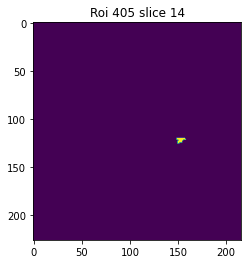

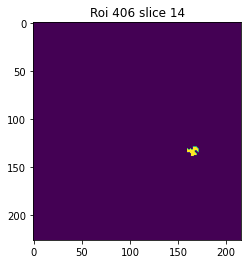

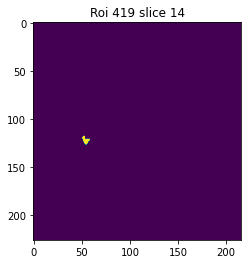

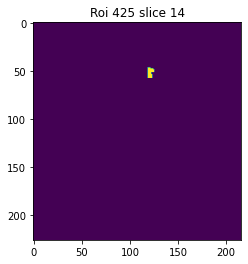

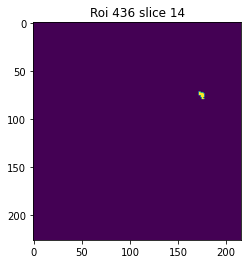

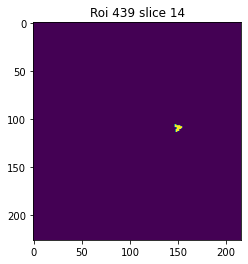

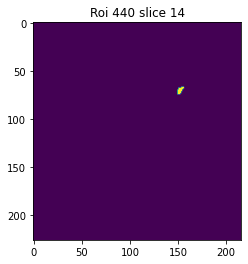

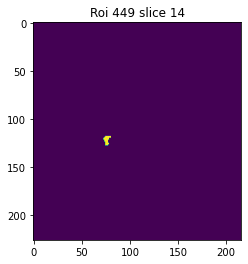

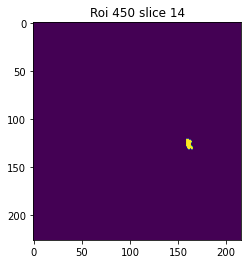

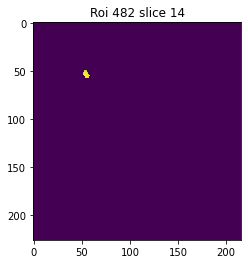

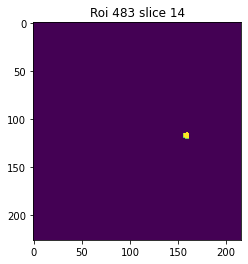

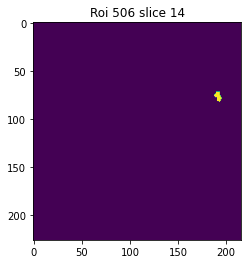

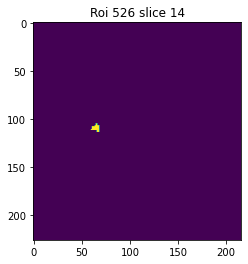

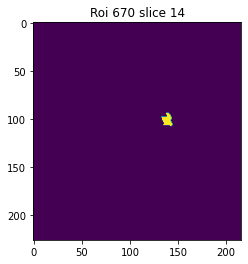

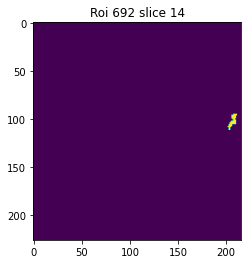

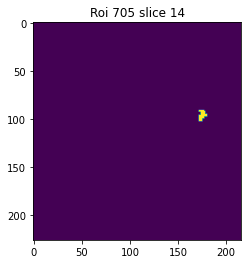

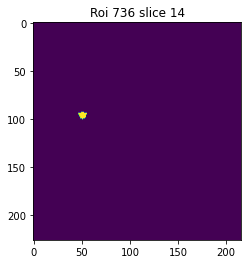

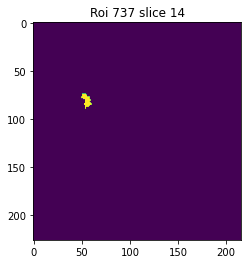

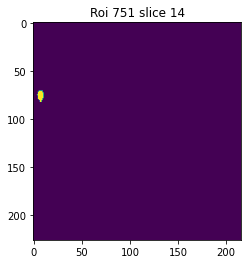

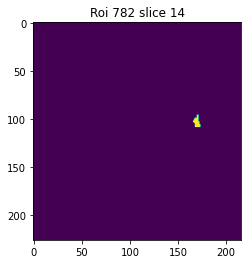

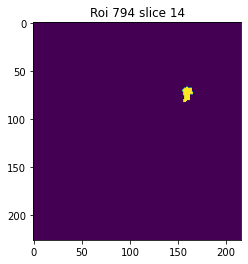

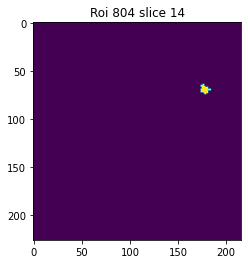

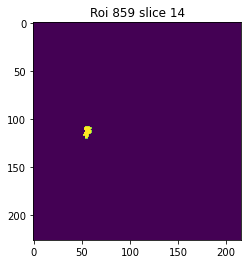

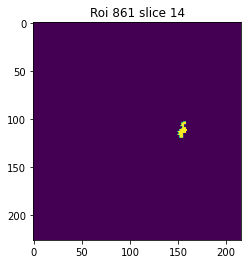

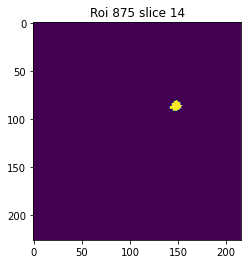

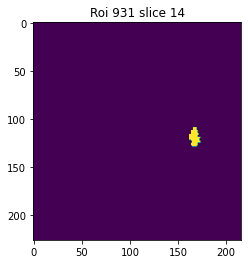

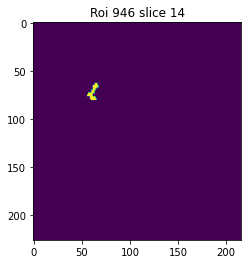

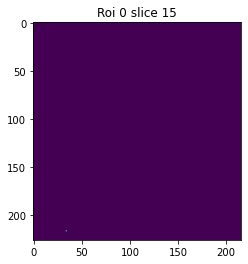

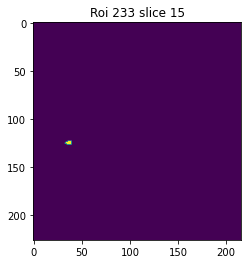

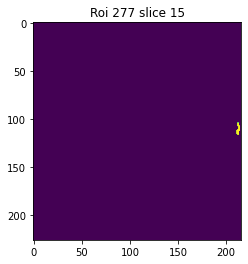

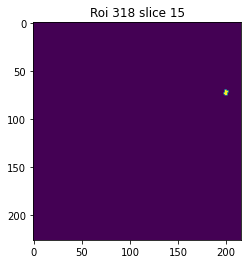

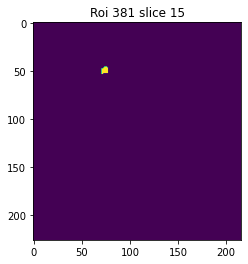

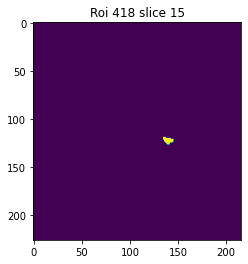

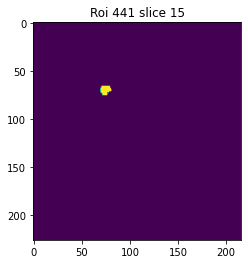

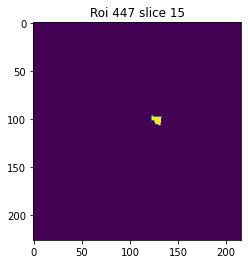

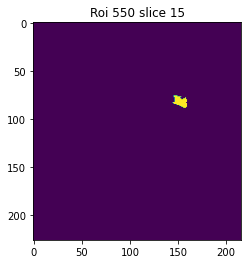

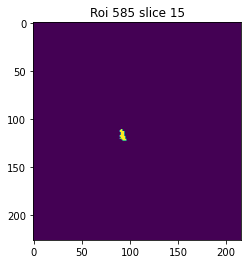

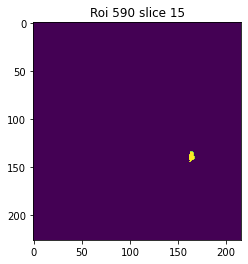

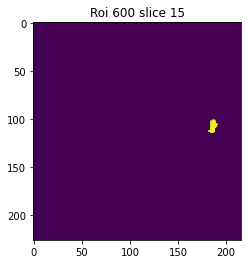

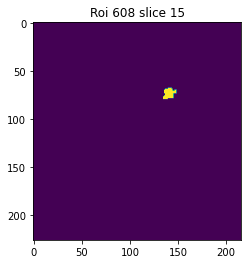

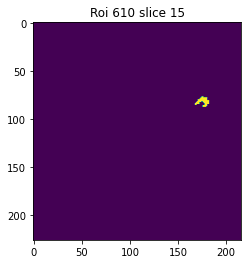

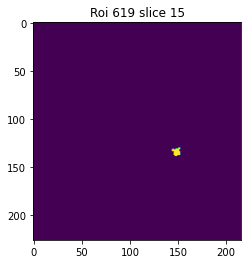

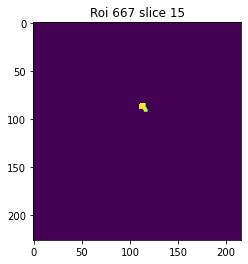

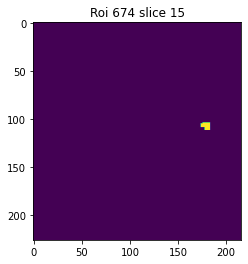

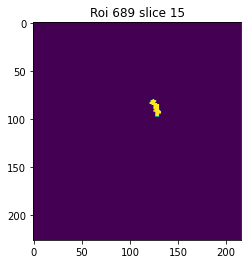

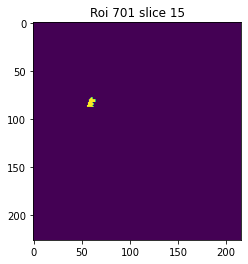

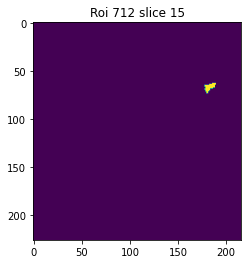

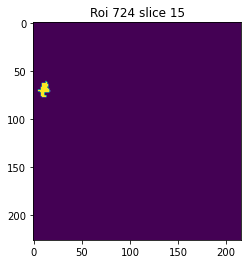

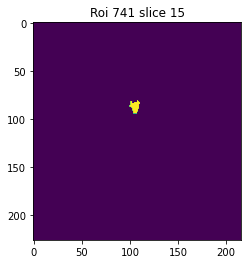

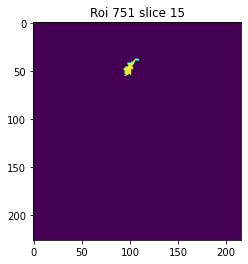

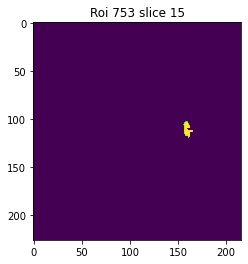

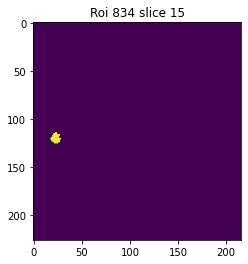

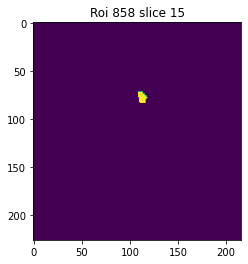

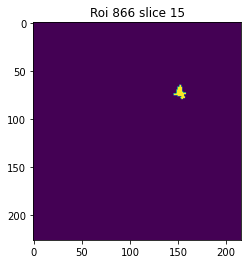

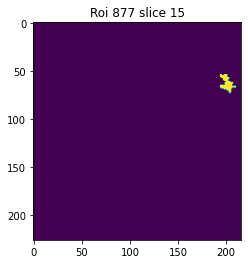

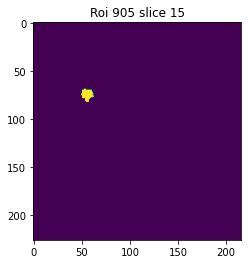

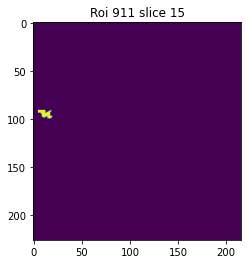

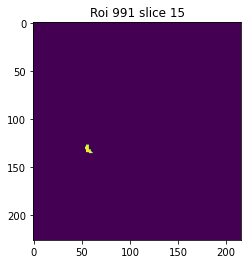

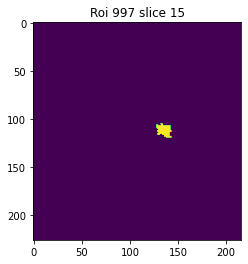

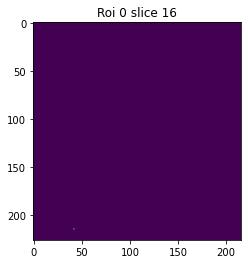

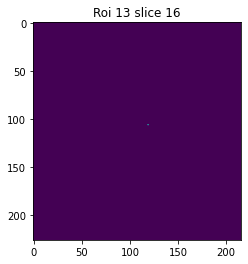

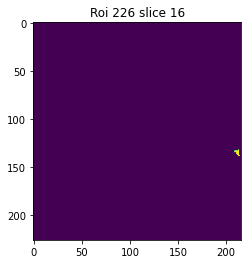

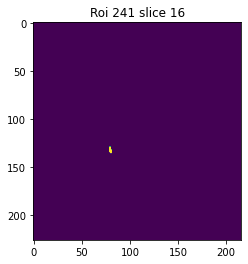

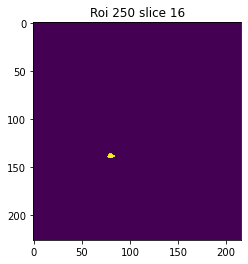

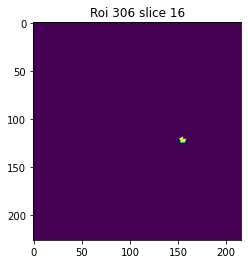

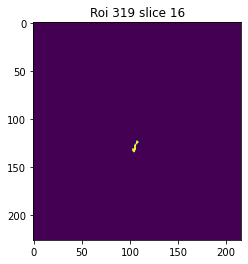

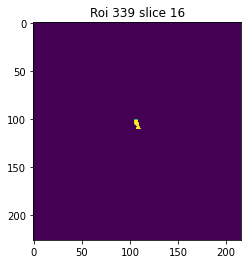

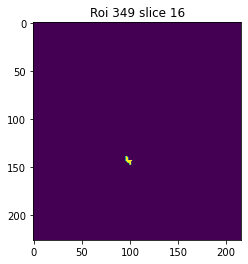

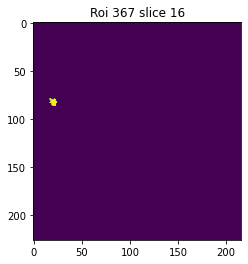

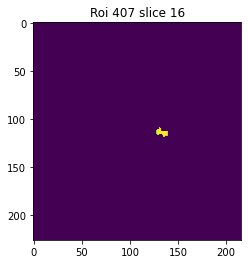

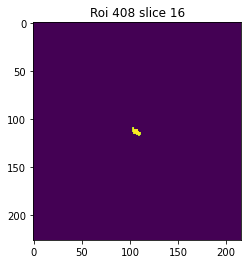

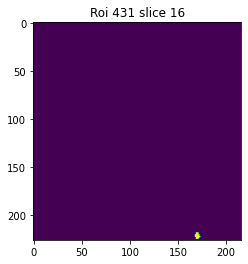

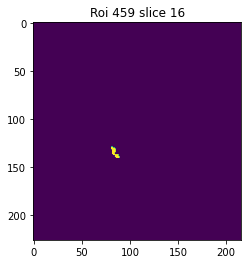

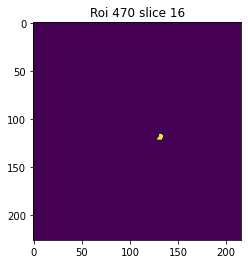

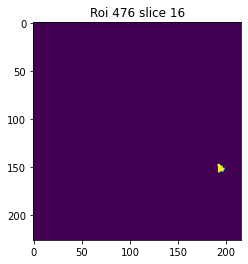

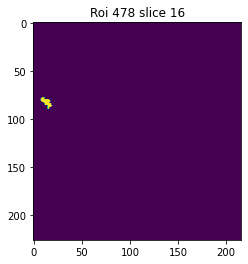

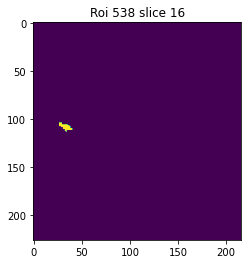

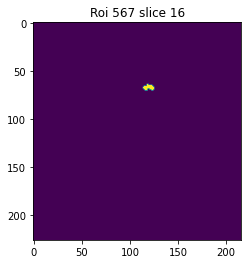

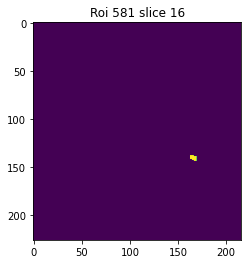

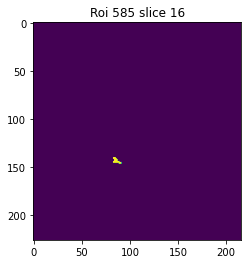

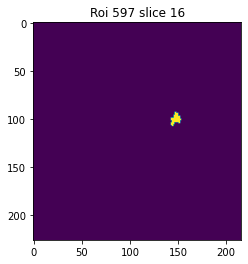

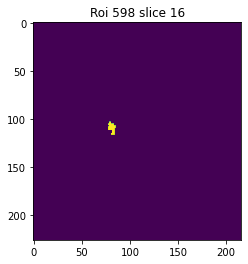

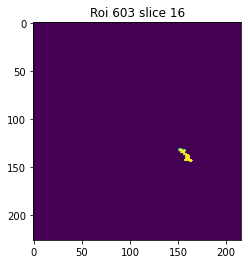

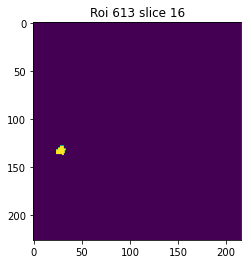

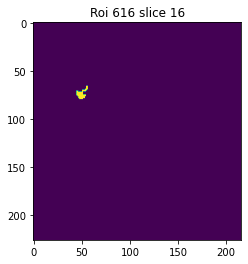

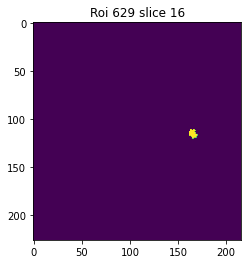

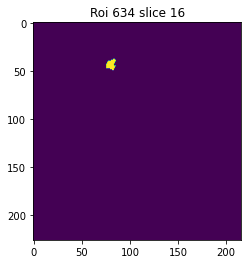

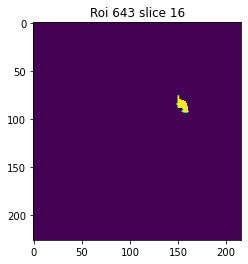

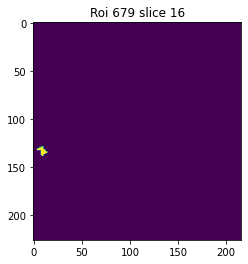

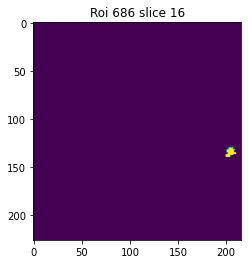

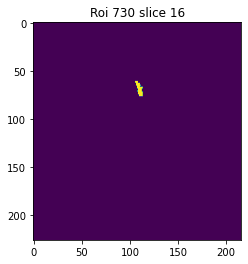

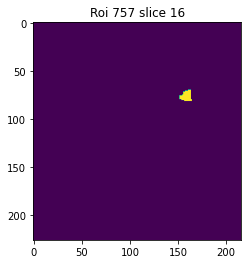

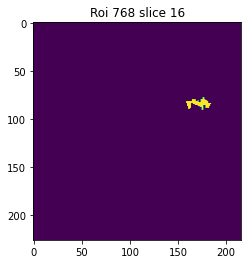

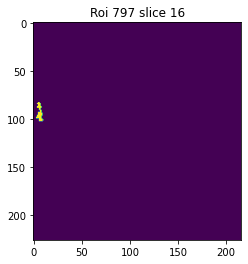

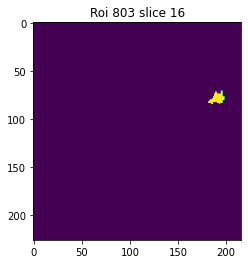

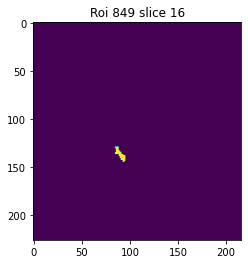

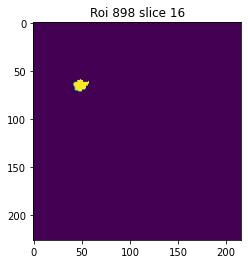

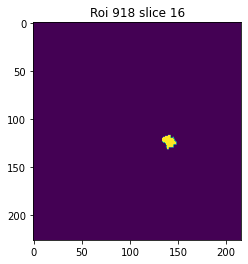

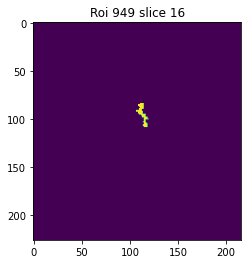

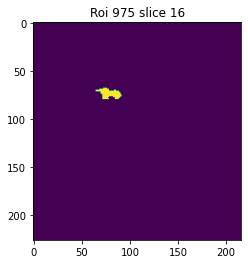

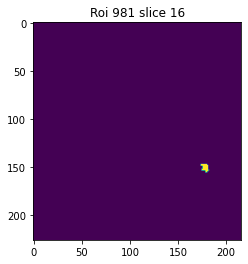

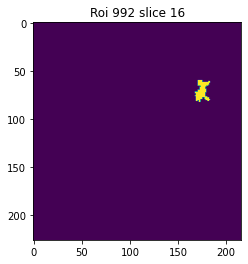

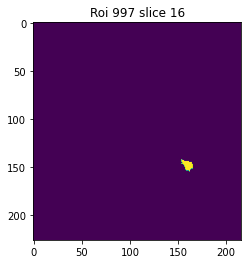

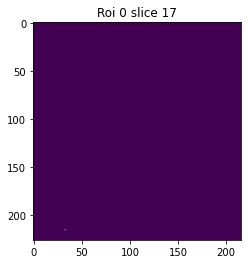

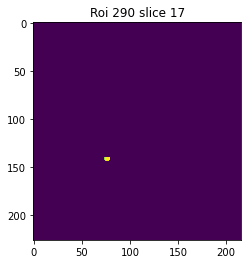

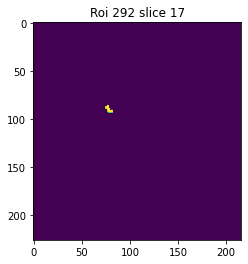

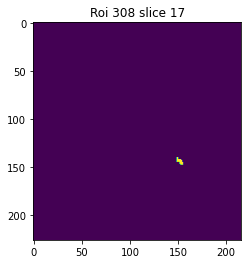

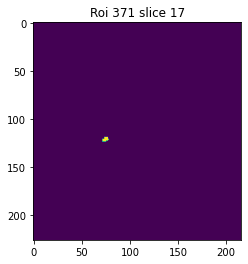

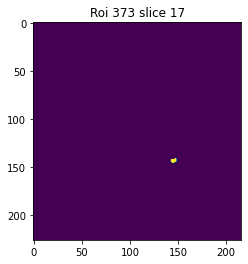

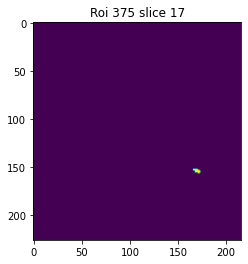

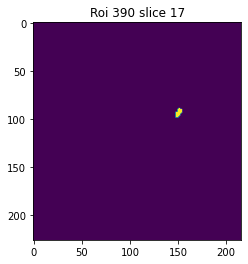

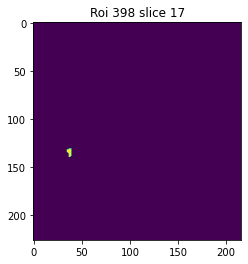

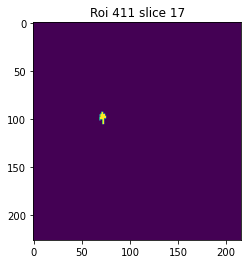

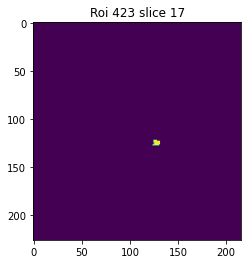

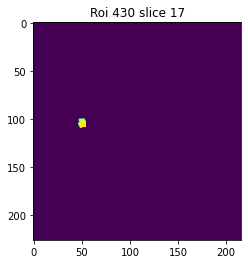

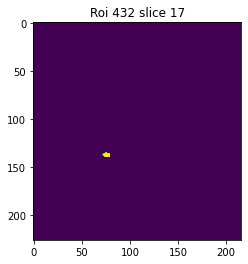

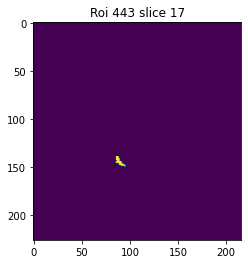

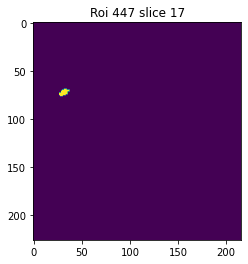

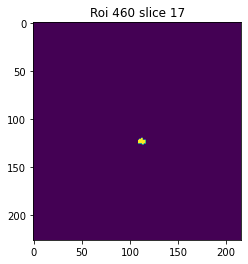

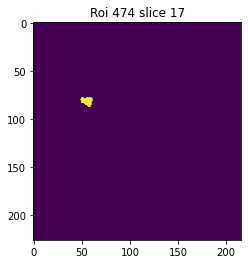

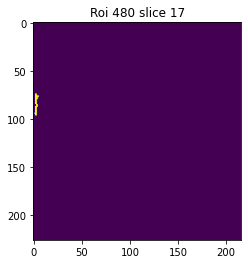

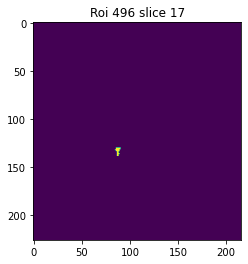

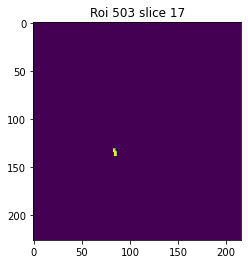

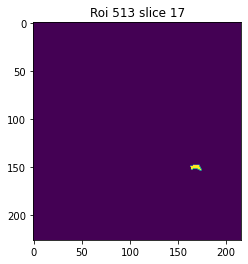

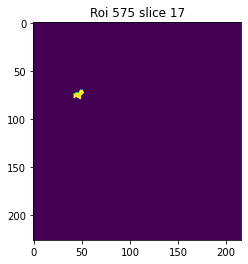

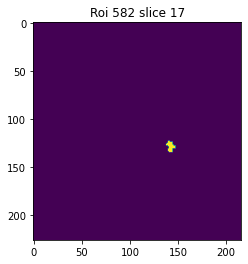

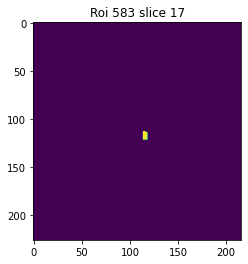

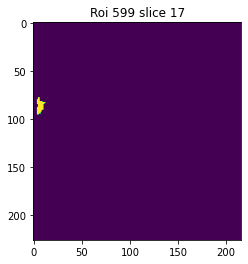

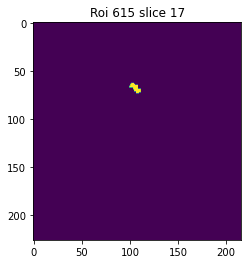

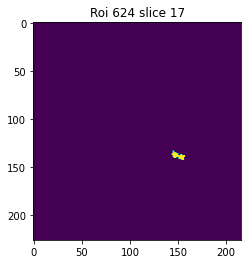

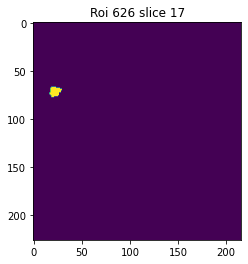

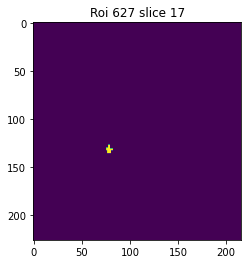

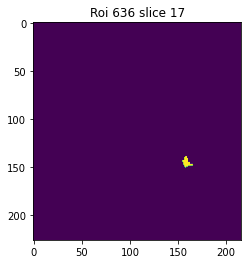

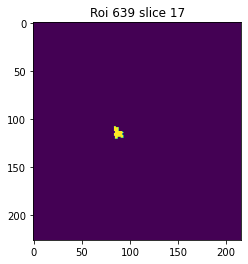

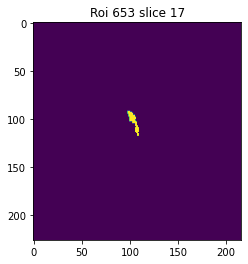

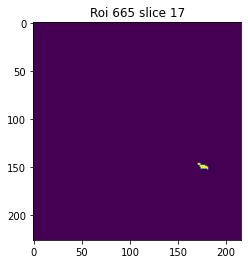

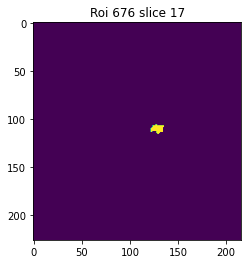

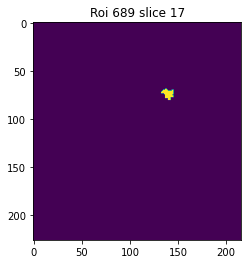

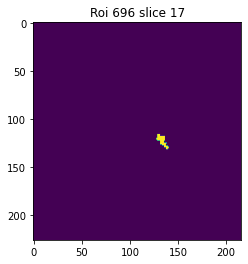

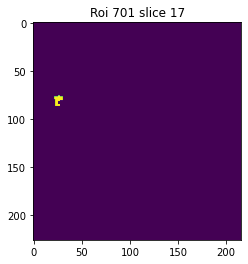

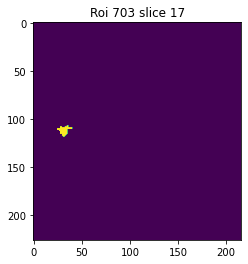

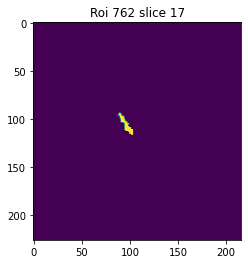

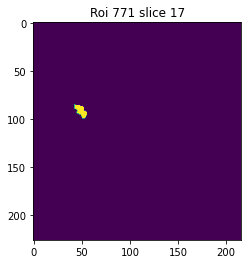

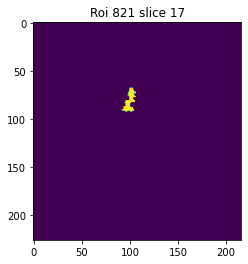

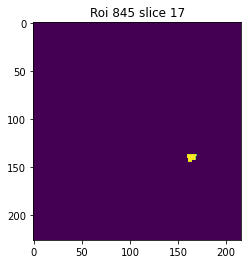

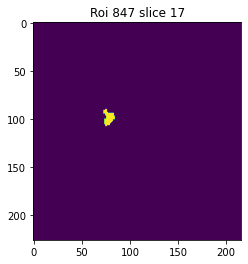

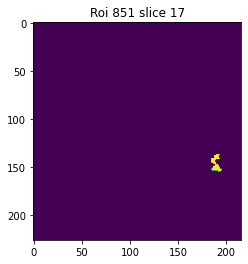

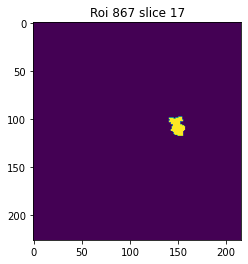

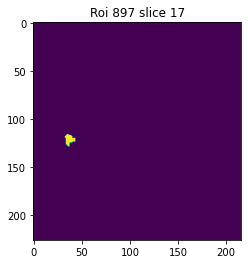

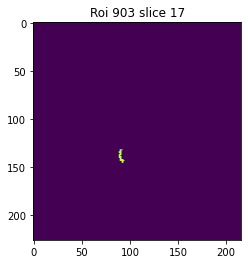

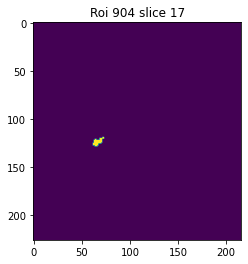

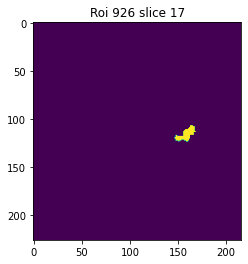

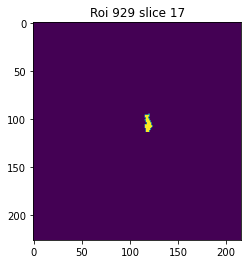

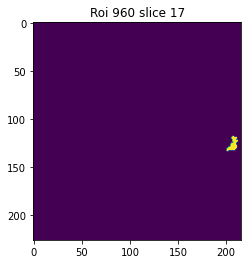

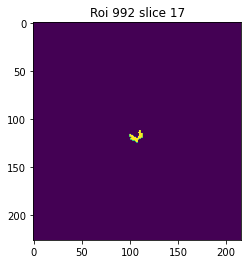

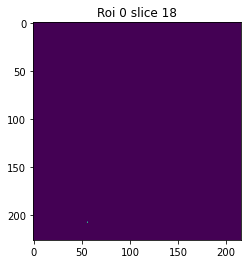

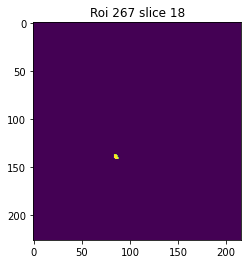

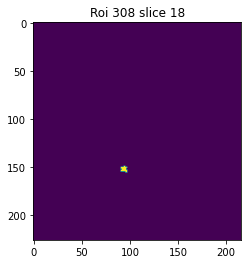

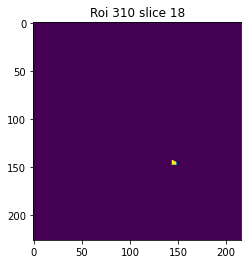

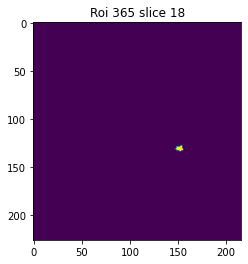

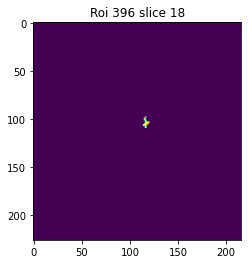

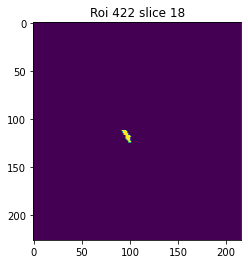

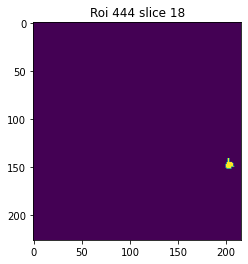

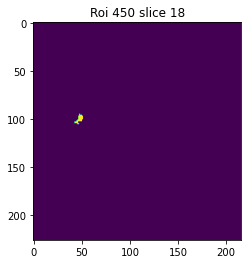

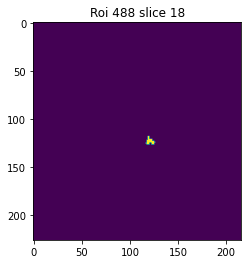

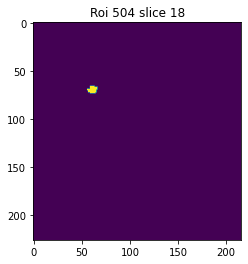

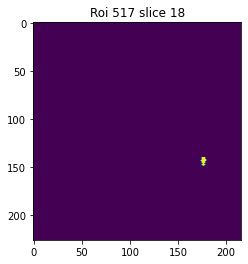

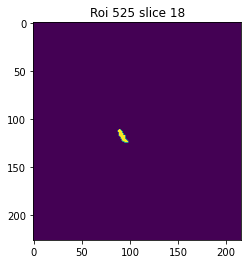

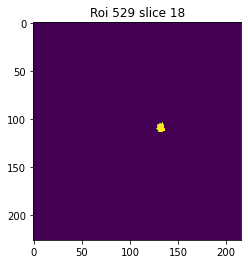

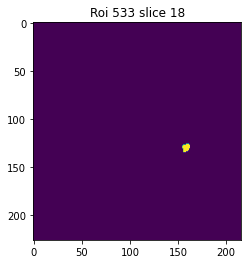

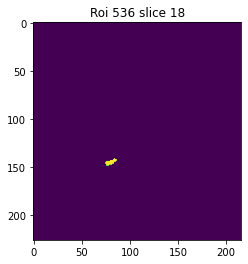

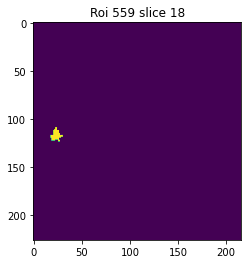

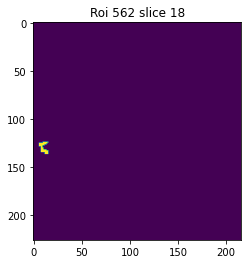

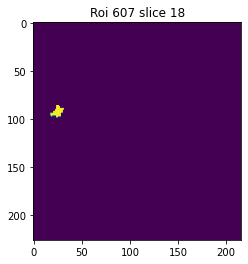

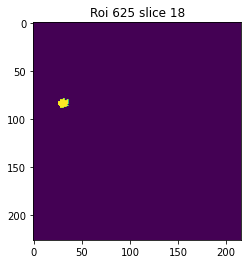

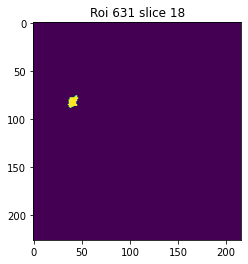

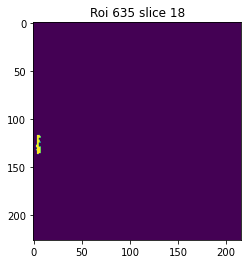

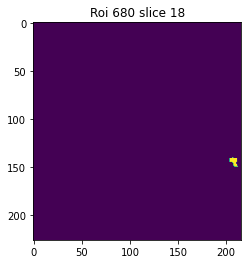

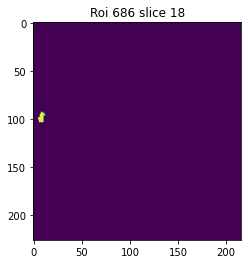

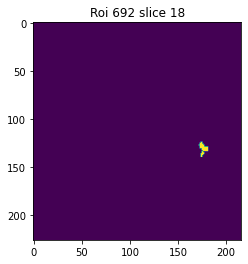

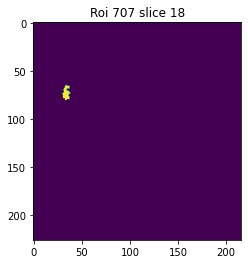

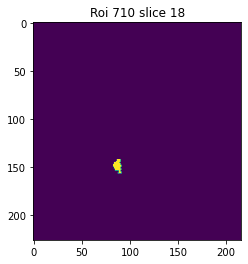

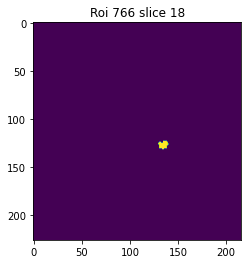

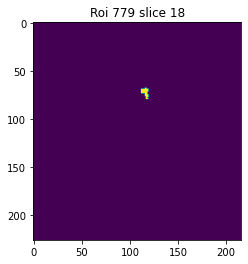

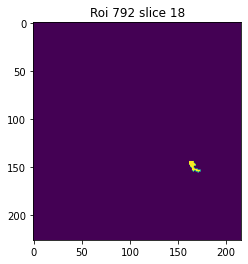

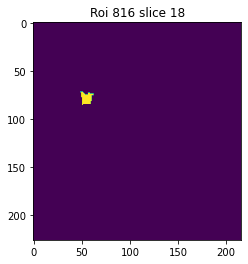

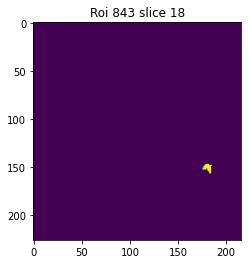

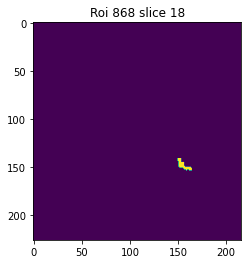

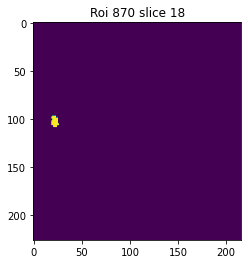

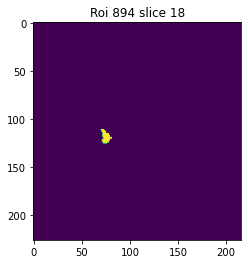

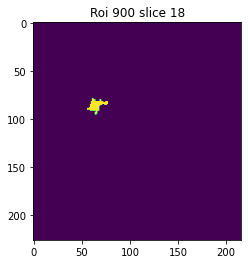

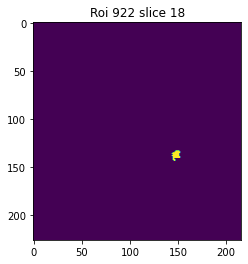

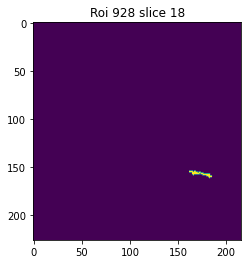

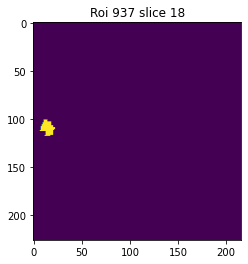

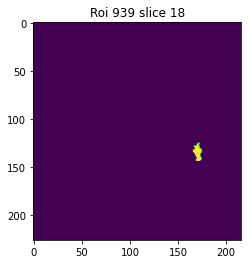

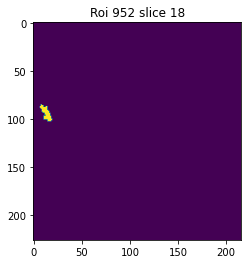

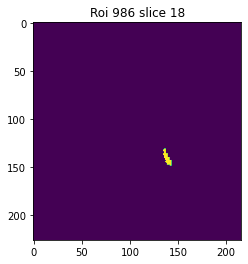

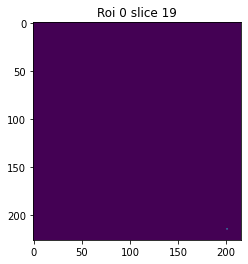

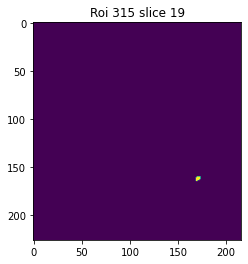

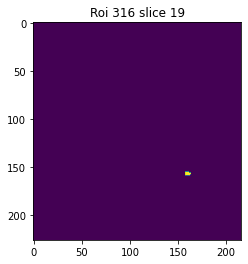

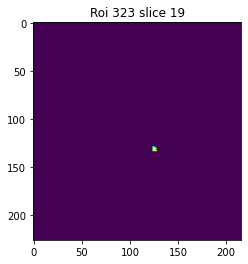

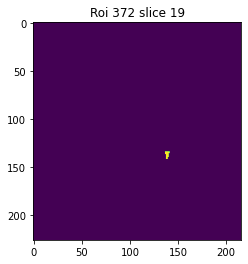

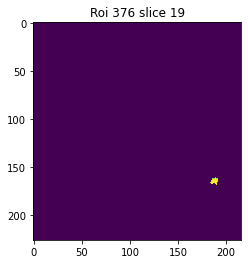

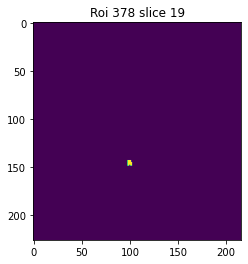

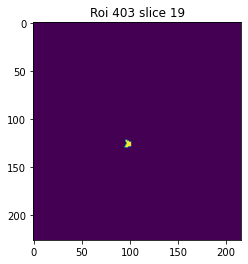

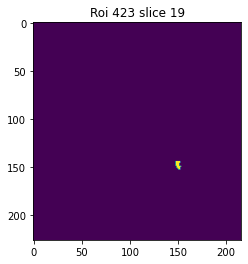

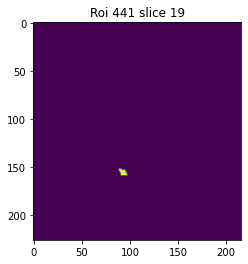

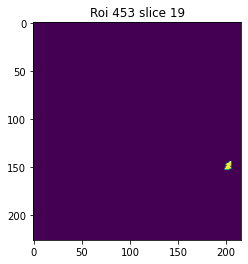

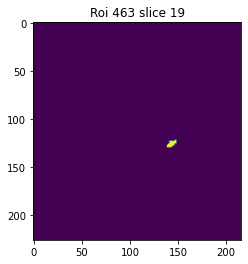

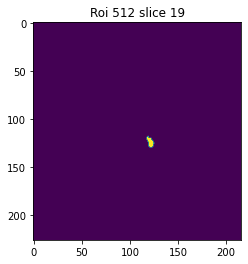

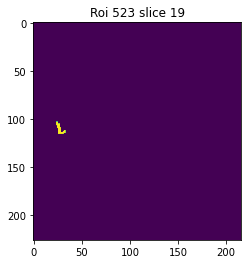

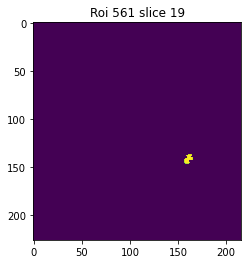

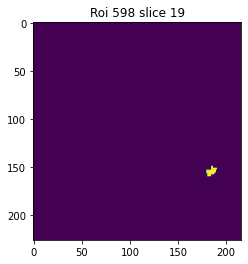

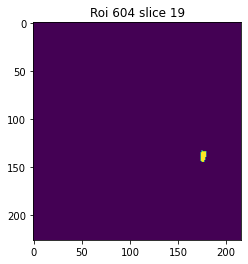

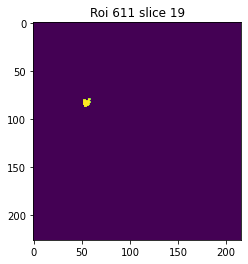

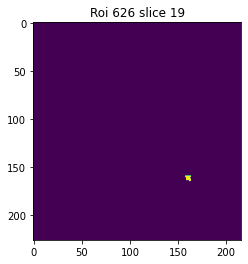

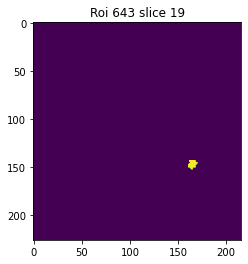

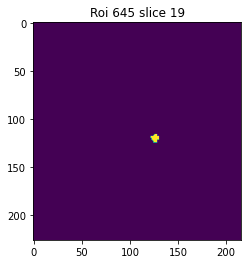

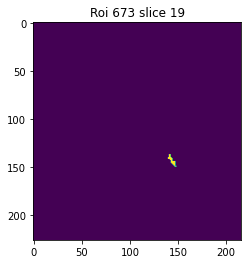

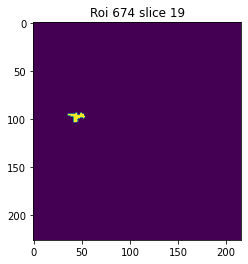

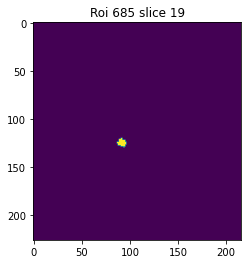

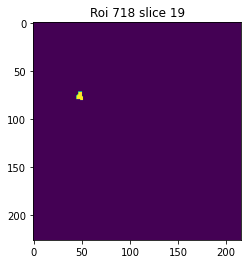

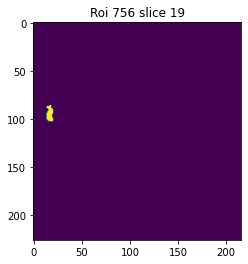

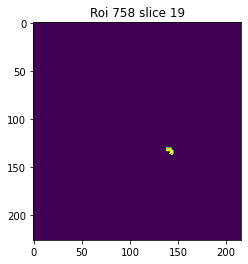

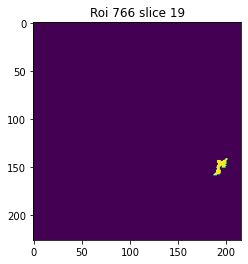

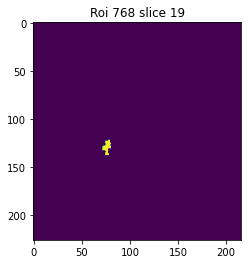

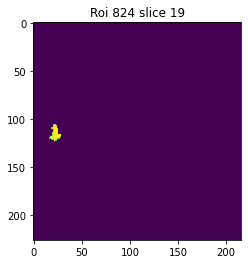

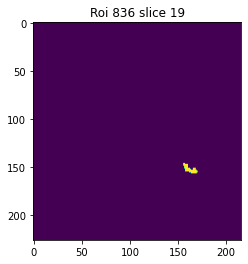

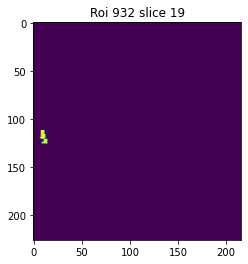

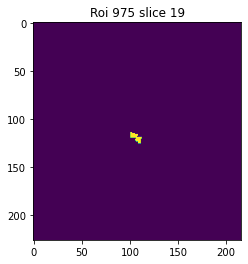

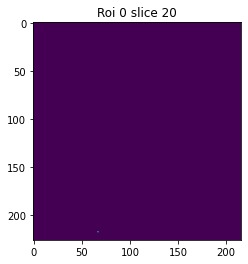

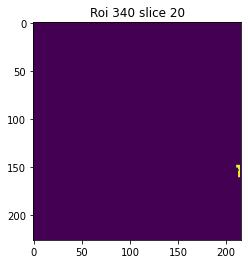

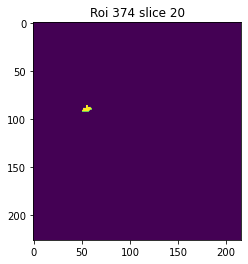

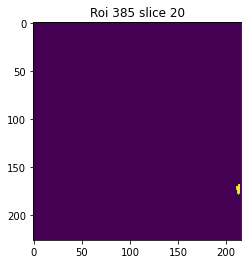

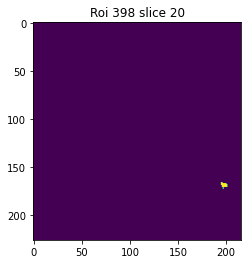

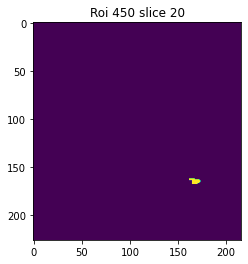

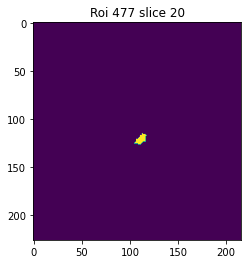

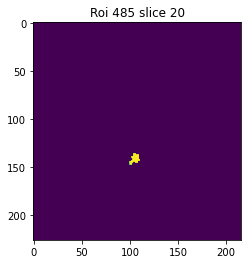

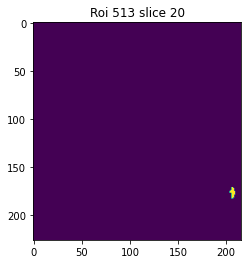

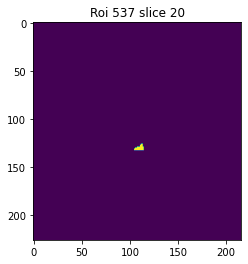

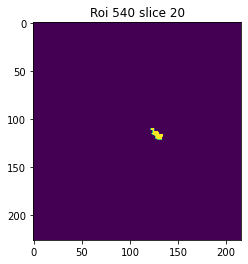

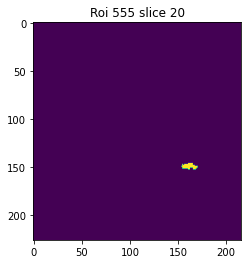

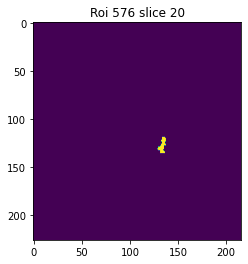

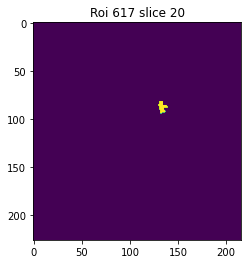

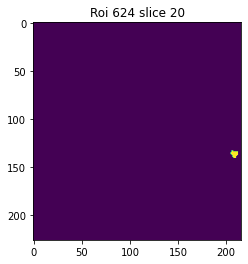

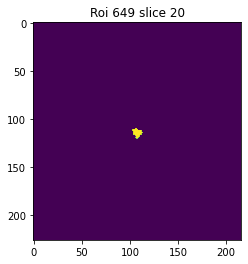

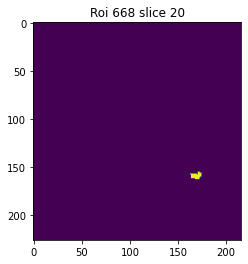

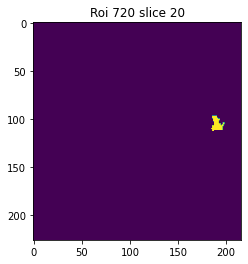

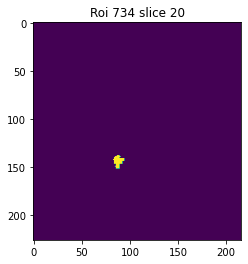

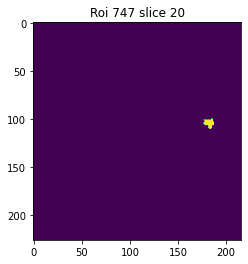

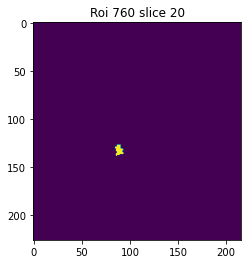

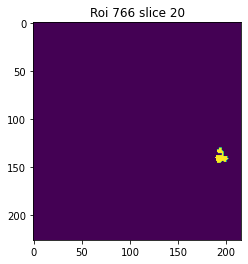

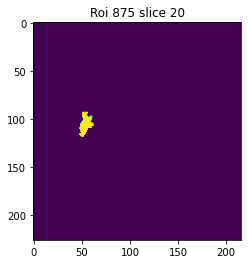

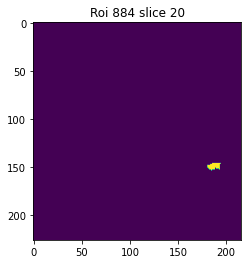

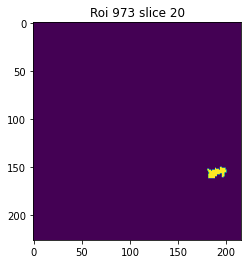

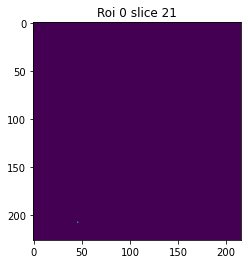

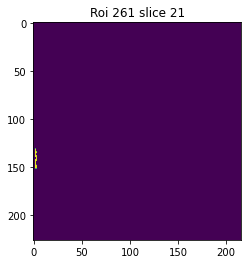

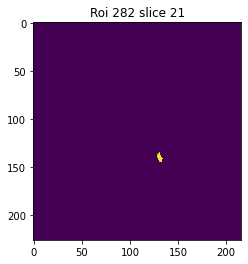

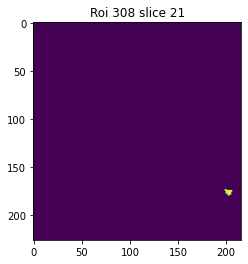

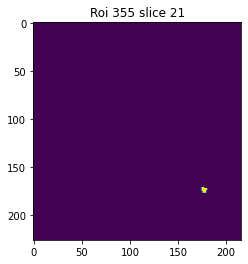

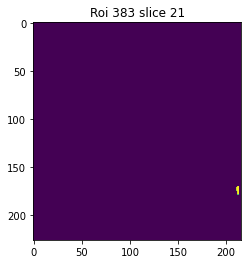

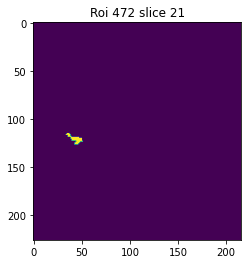

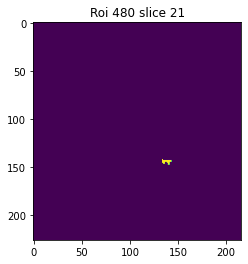

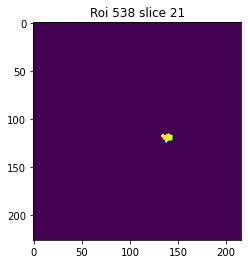

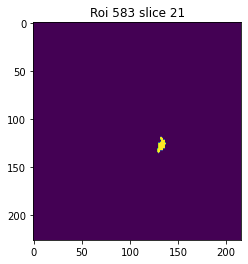

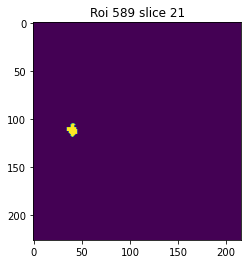

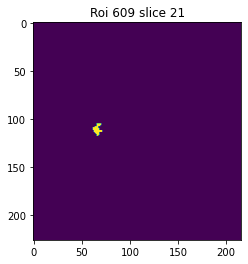

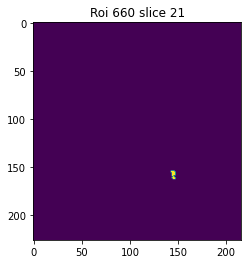

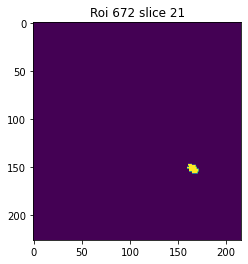

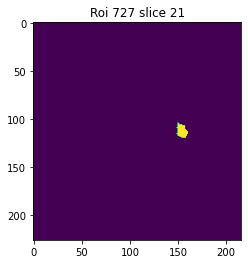

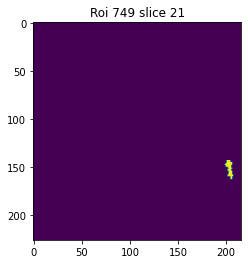

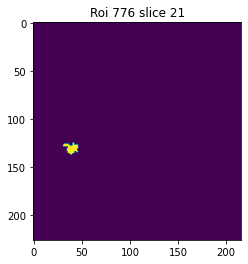

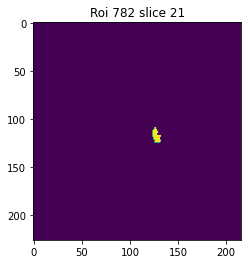

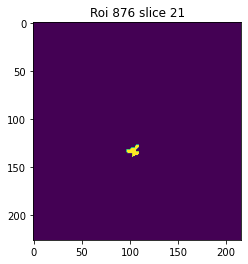

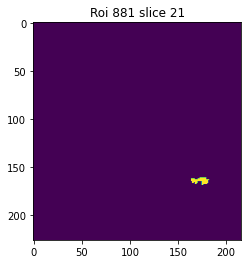

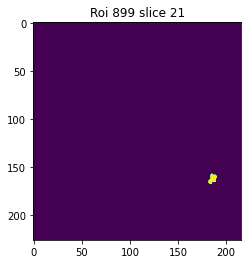

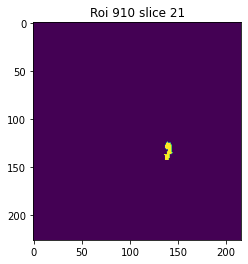

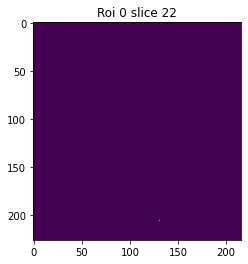

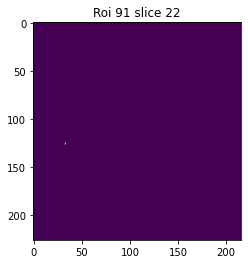

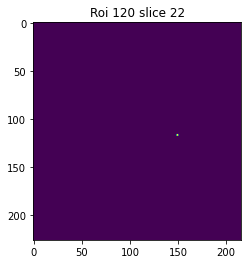

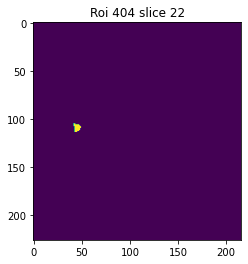

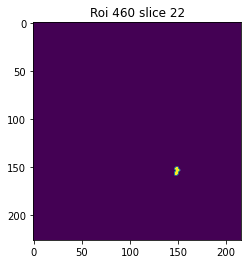

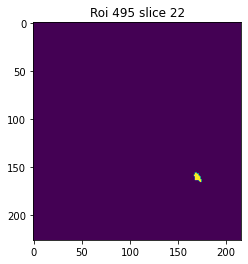

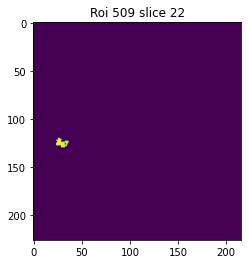

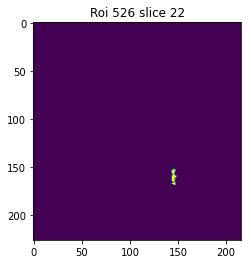

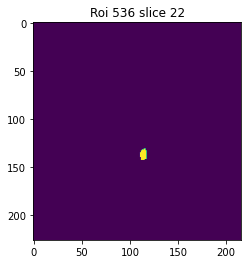

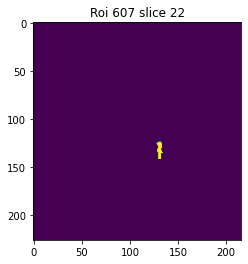

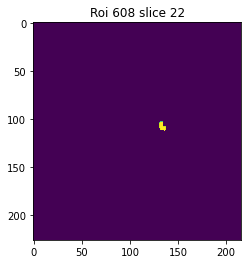

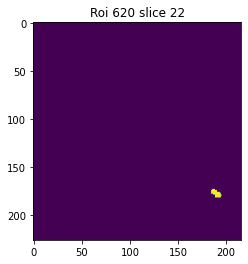

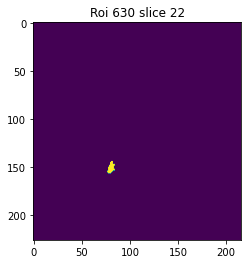

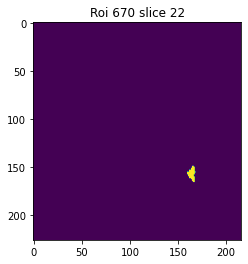

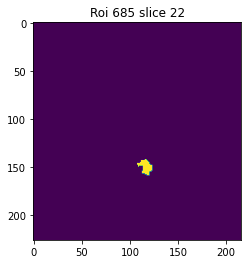

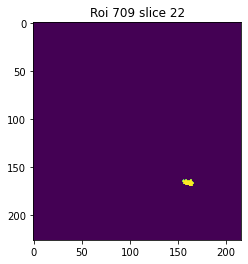

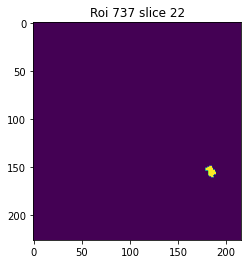

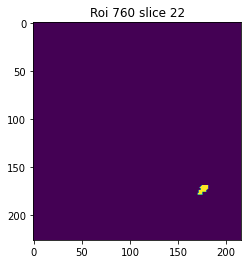

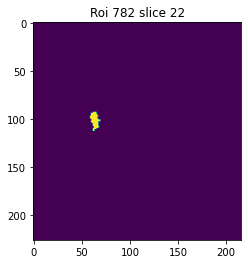

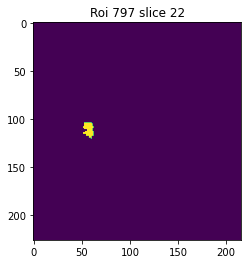

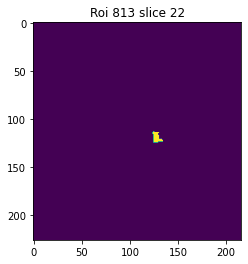

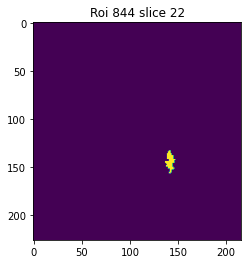

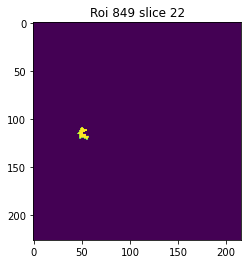

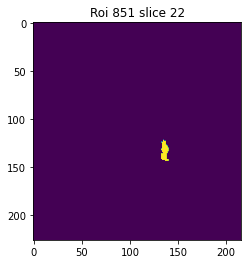

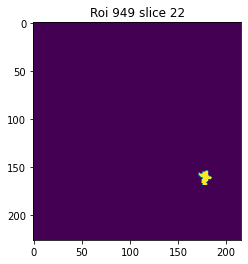

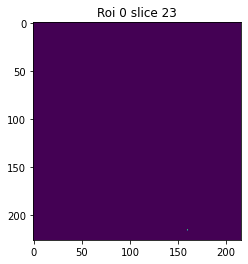

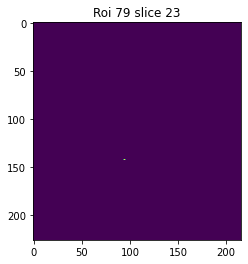

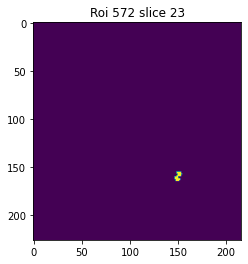

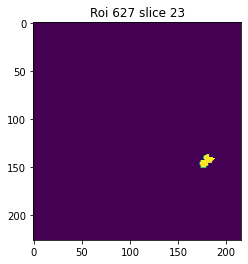

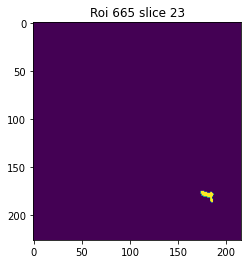

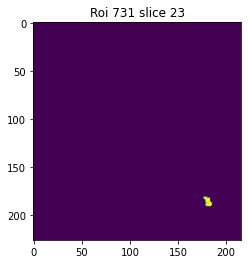

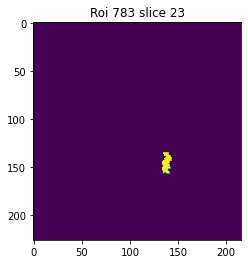

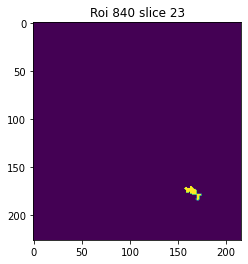

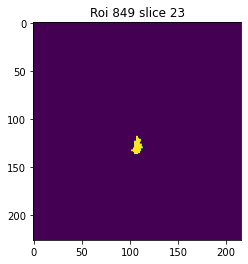

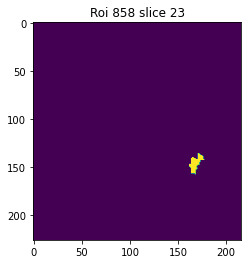

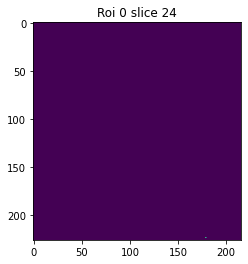

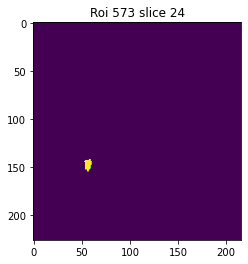

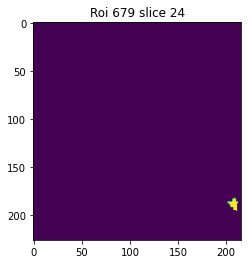

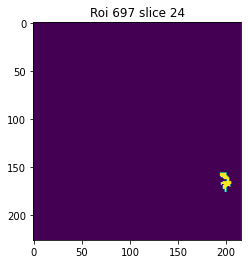

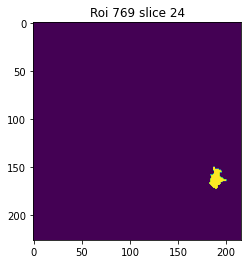

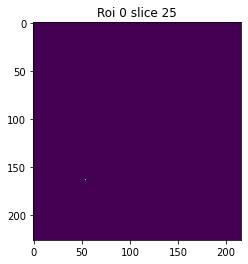

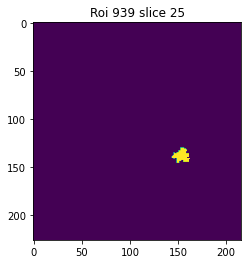

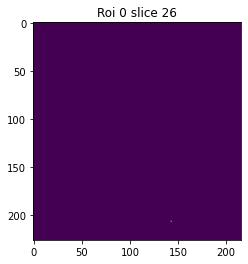

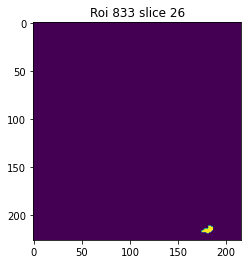

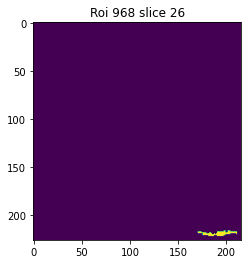

In [50]:
for i in np.arange(len(audio_correlated)):
    plt.figure()
    plt.imshow(roi_pos[:,:,slice_audio[i]]==roi_audio[i])
    plt.title('Roi {} slice {}'.format(roi_audio[i],slice_audio[i]))
    

<ipython-input-13-eba690fbebc0>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


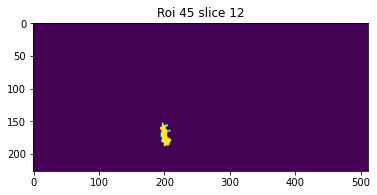

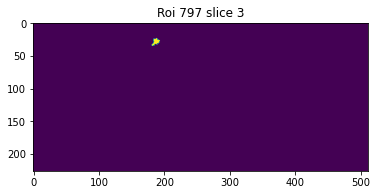

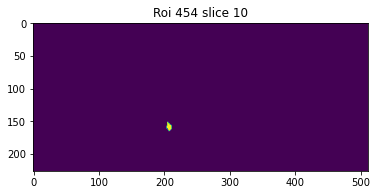

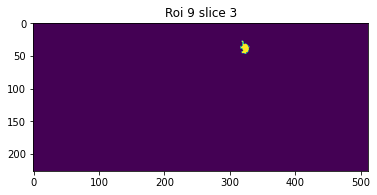

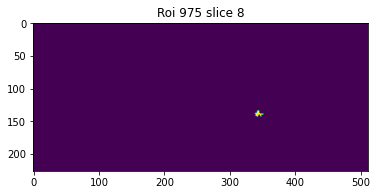

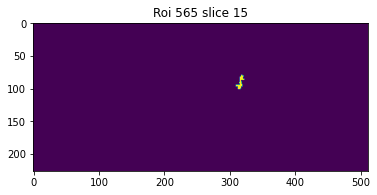

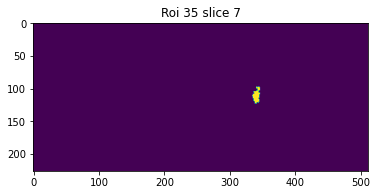

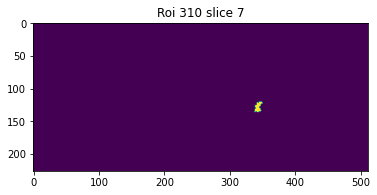

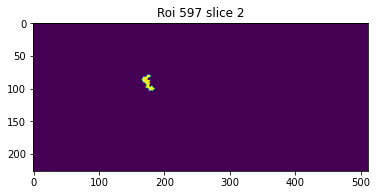

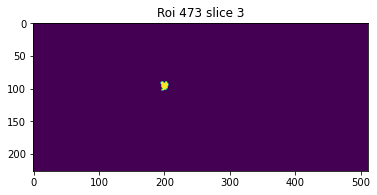

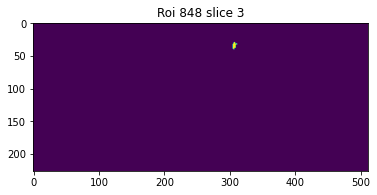

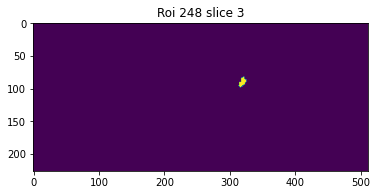

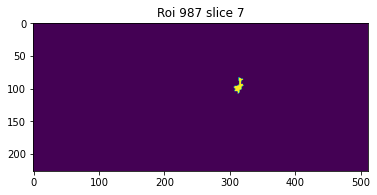

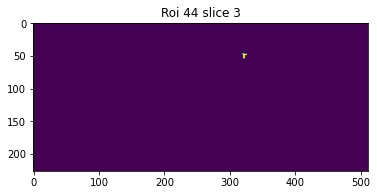

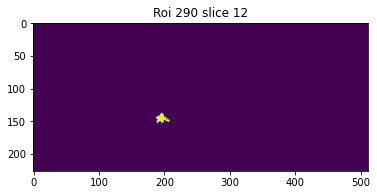

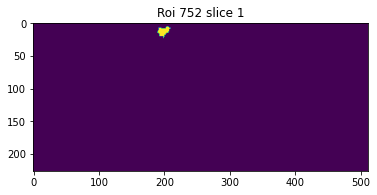

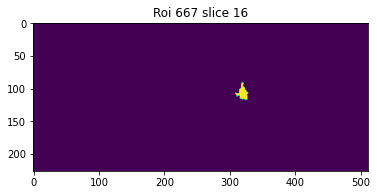

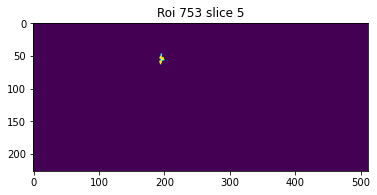

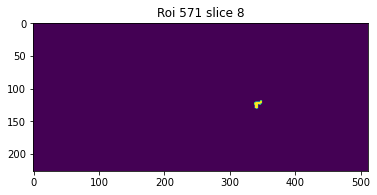

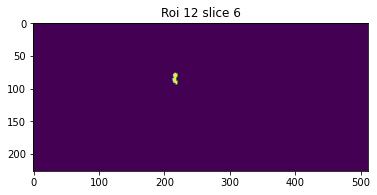

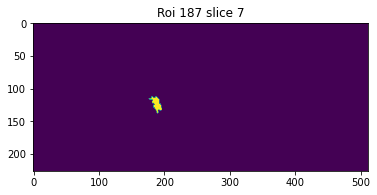

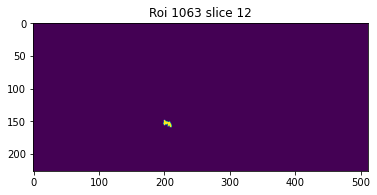

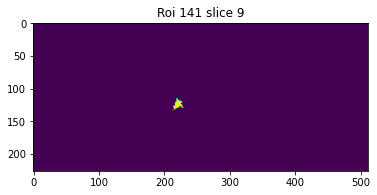

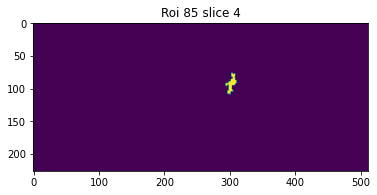

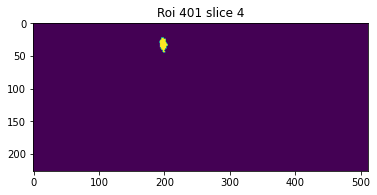

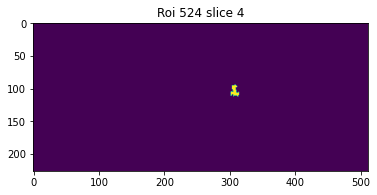

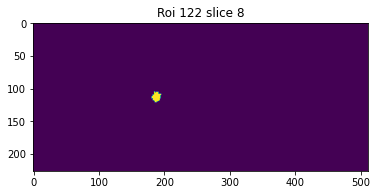

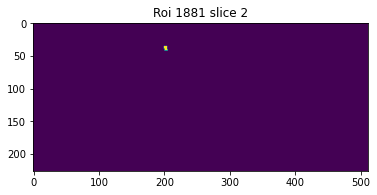

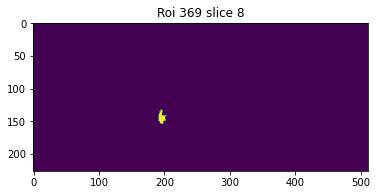

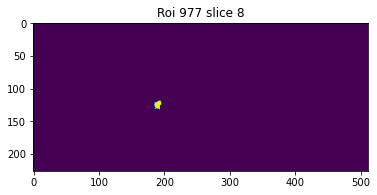

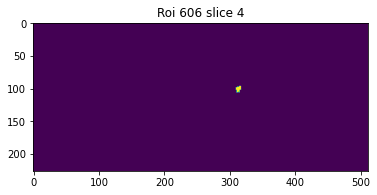

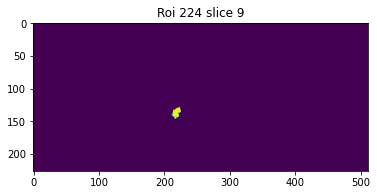

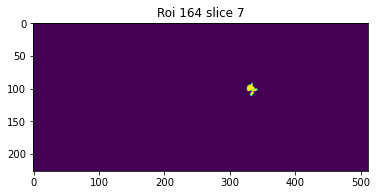

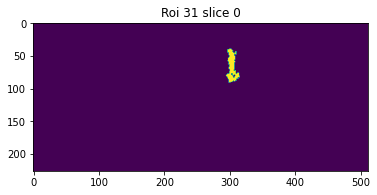

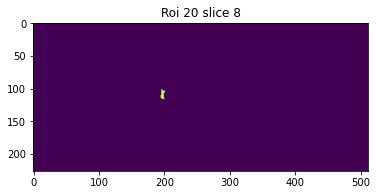

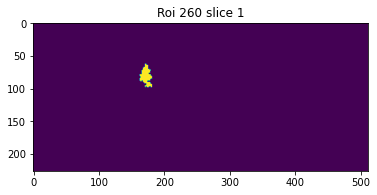

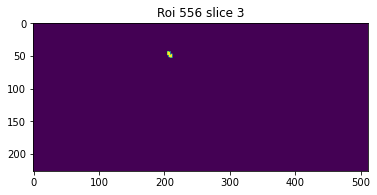

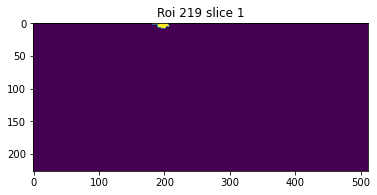

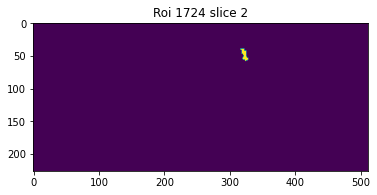

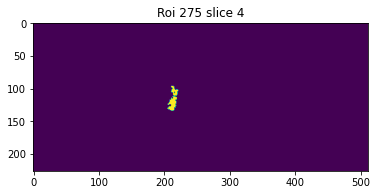

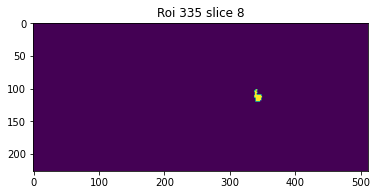

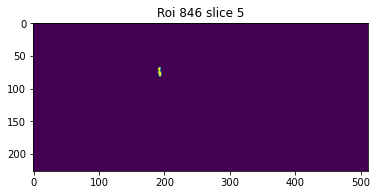

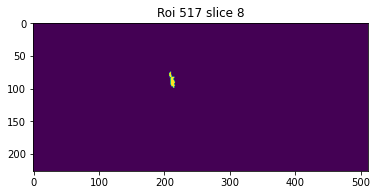

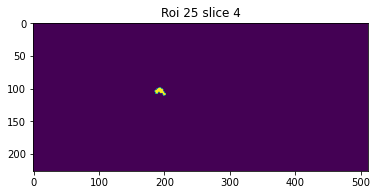

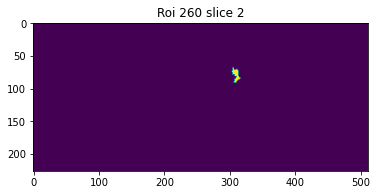

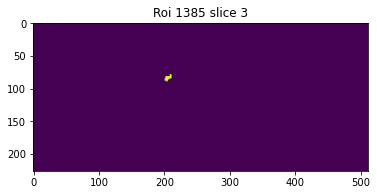

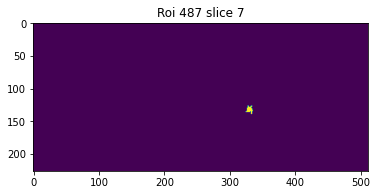

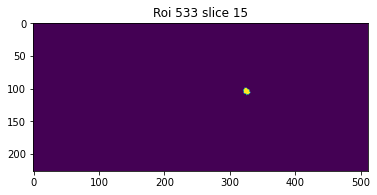

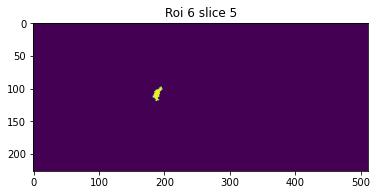

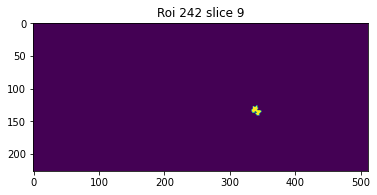

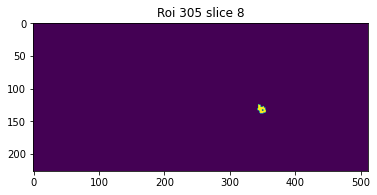

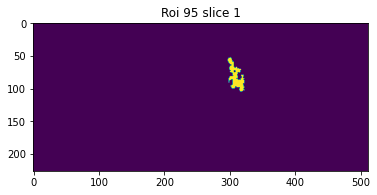

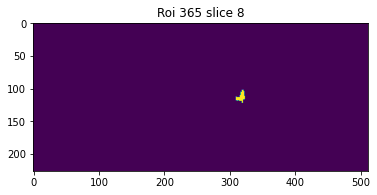

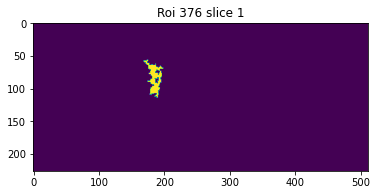

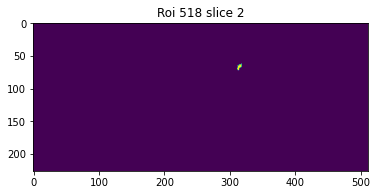

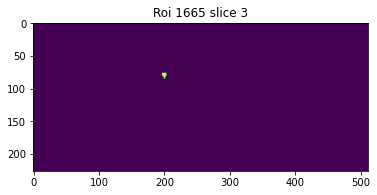

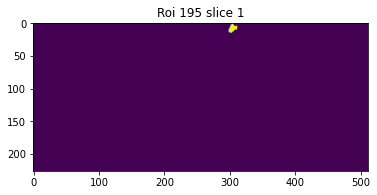

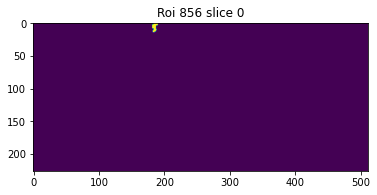

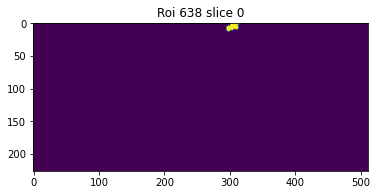

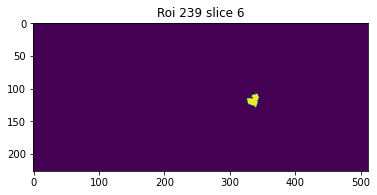

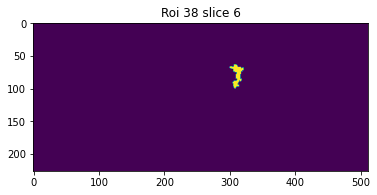

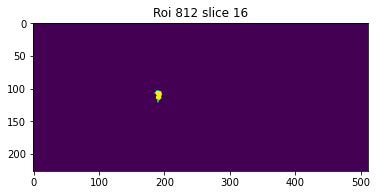

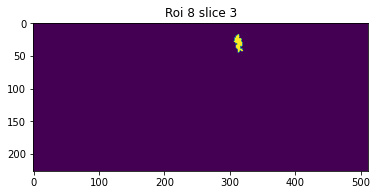

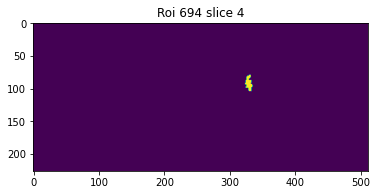

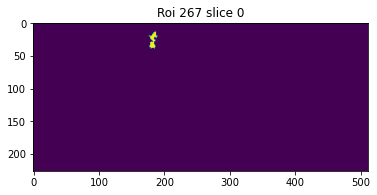

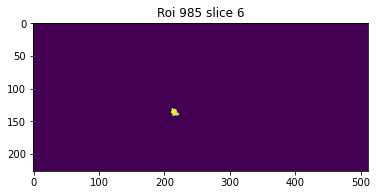

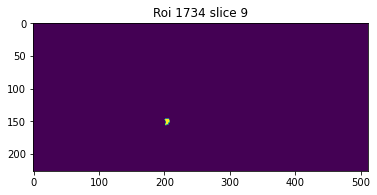

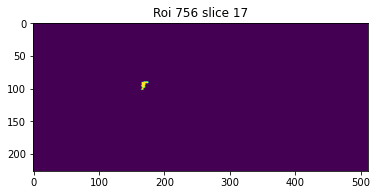

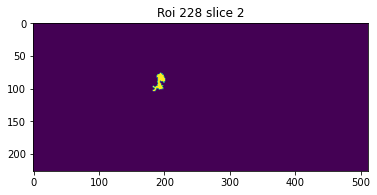

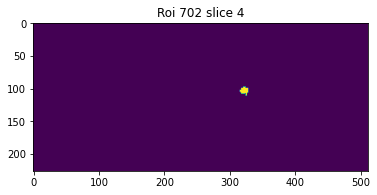

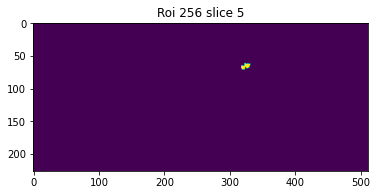

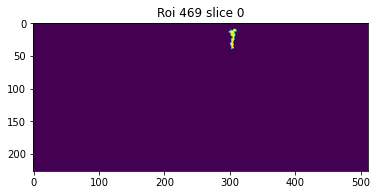

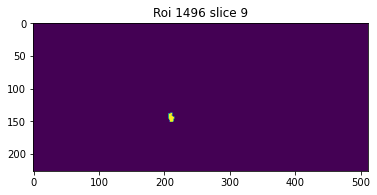

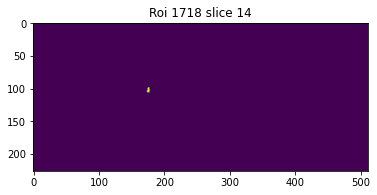

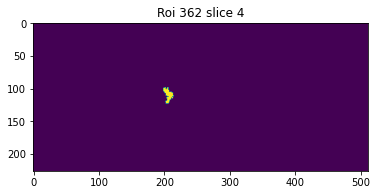

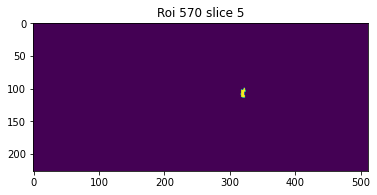

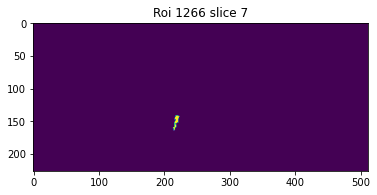

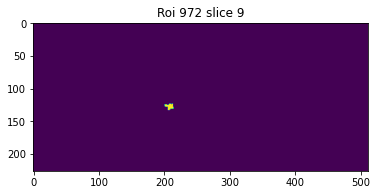

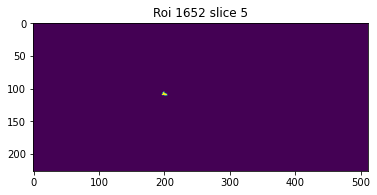

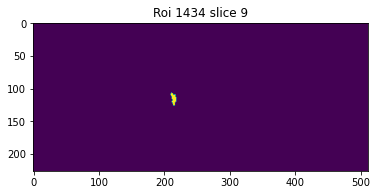

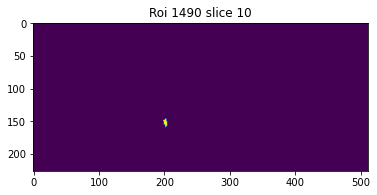

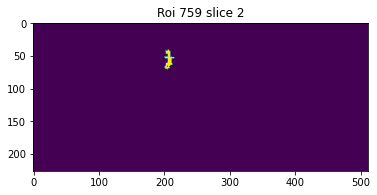

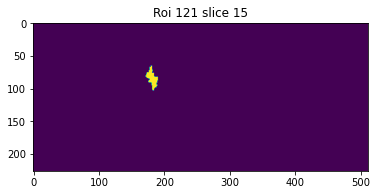

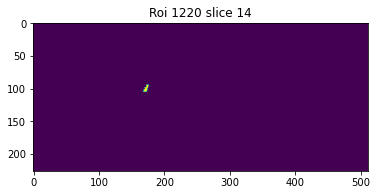

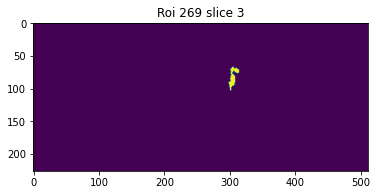

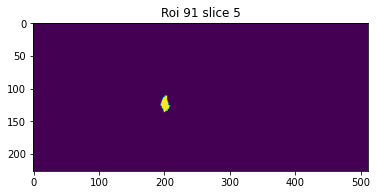

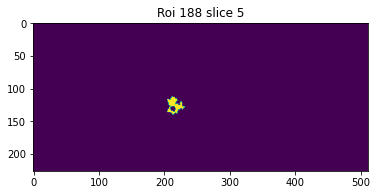

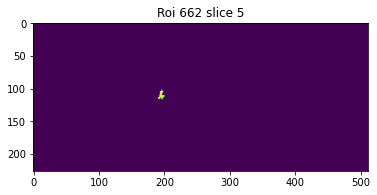

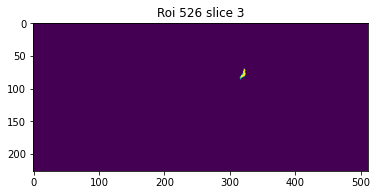

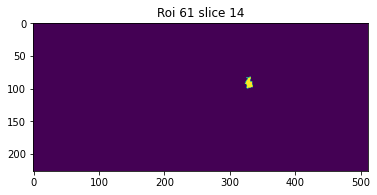

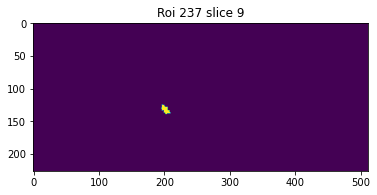

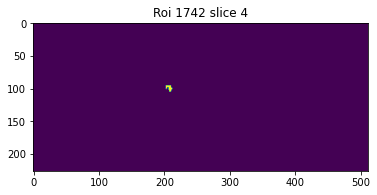

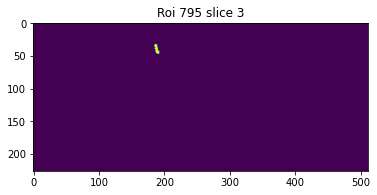

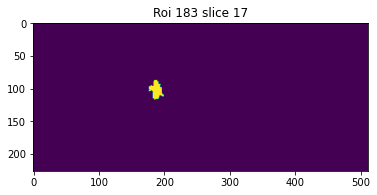

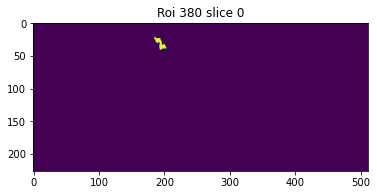

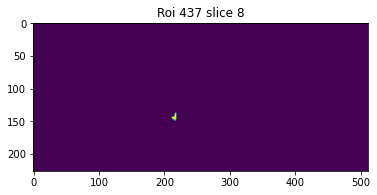

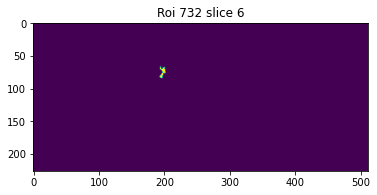

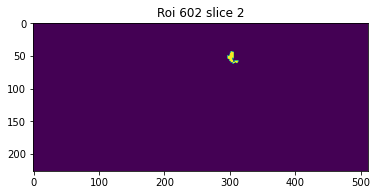

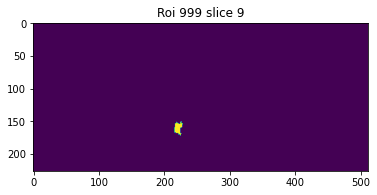

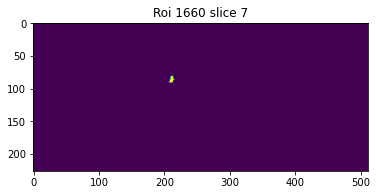

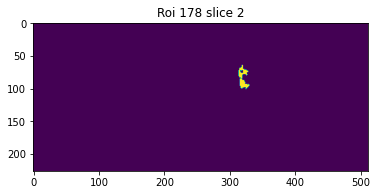

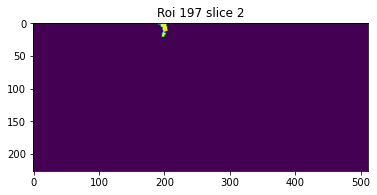

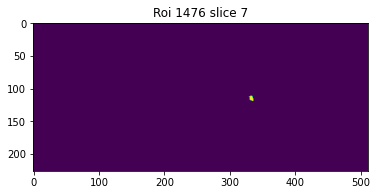

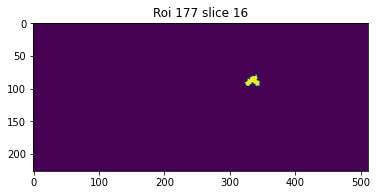

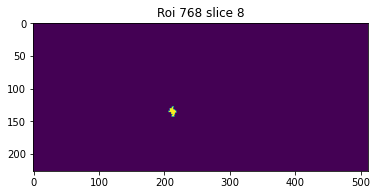

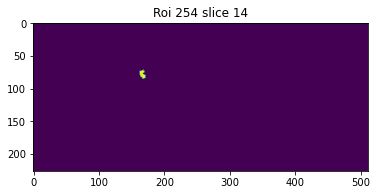

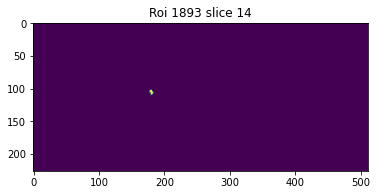

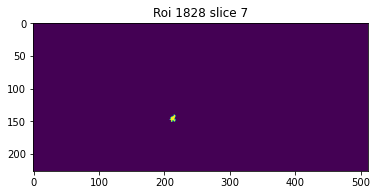

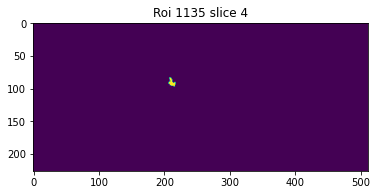

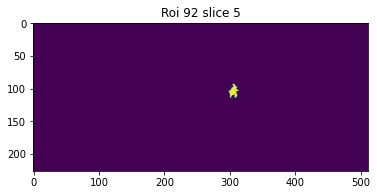

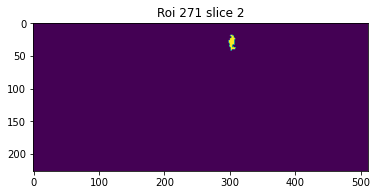

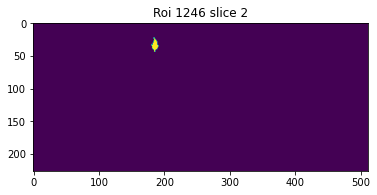

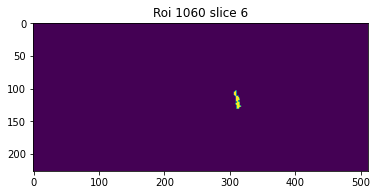

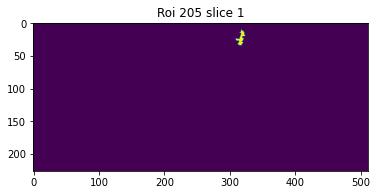

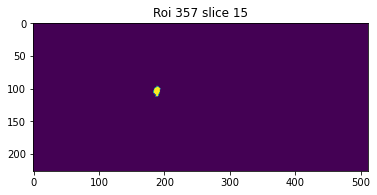

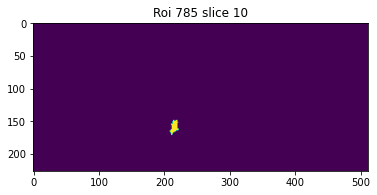

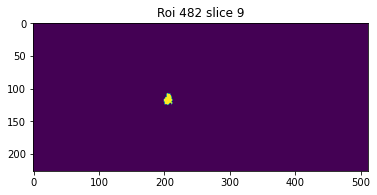

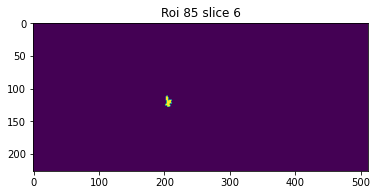

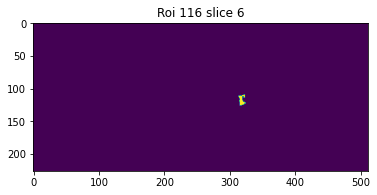

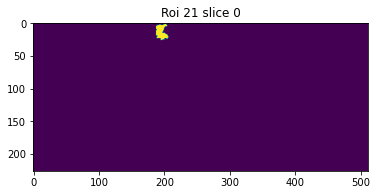

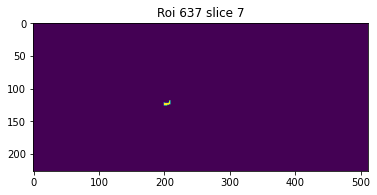

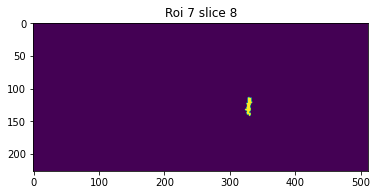

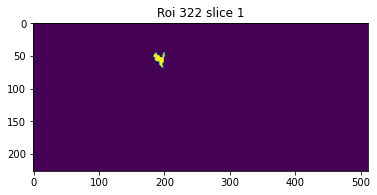

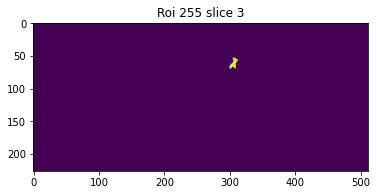

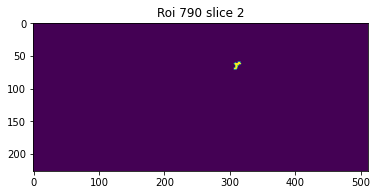

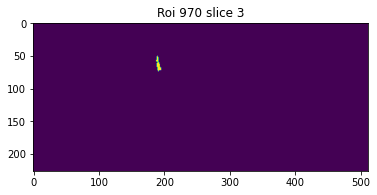

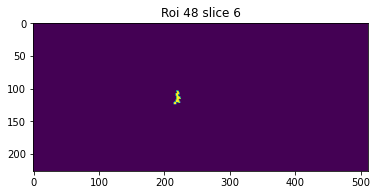

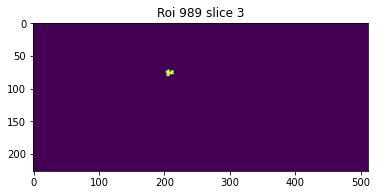

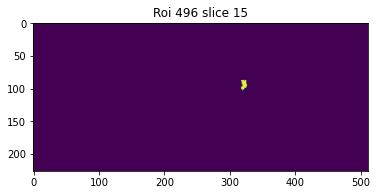

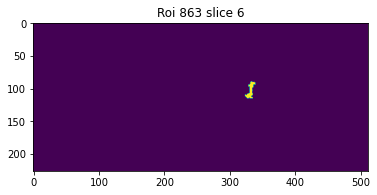

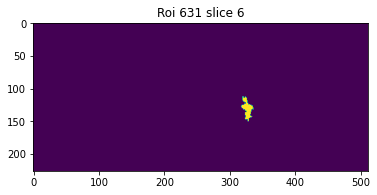

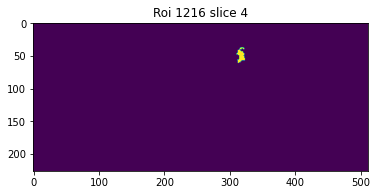

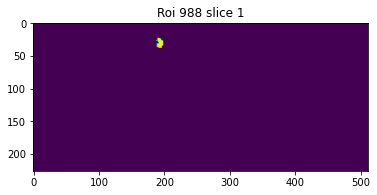

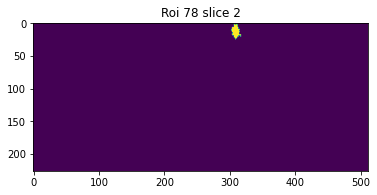

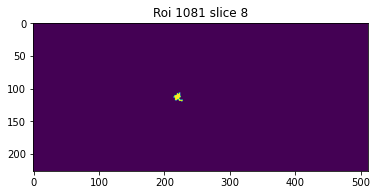

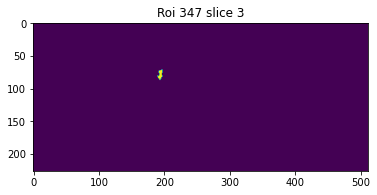

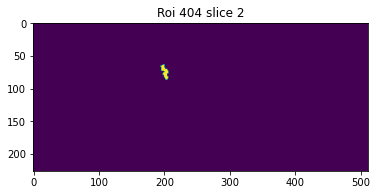

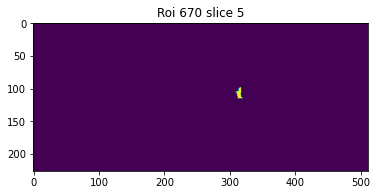

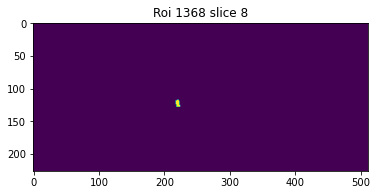

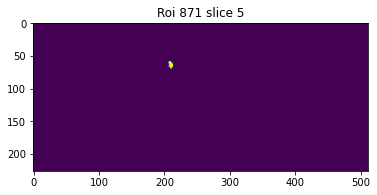

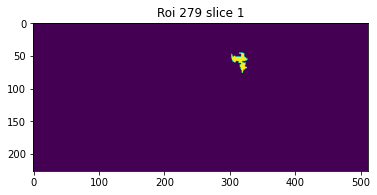

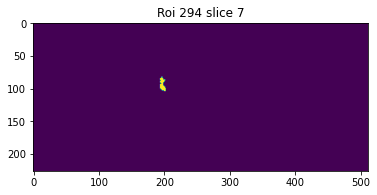

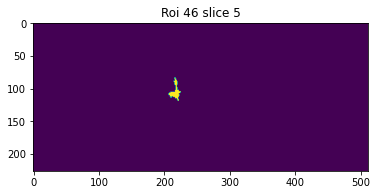

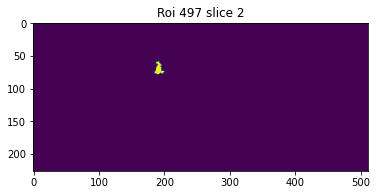

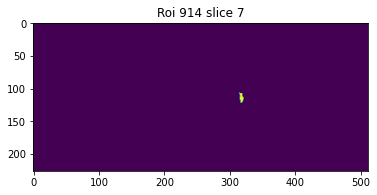

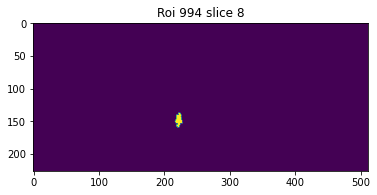

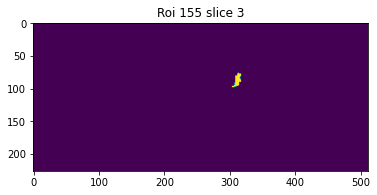

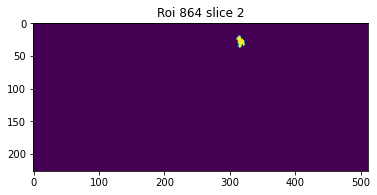

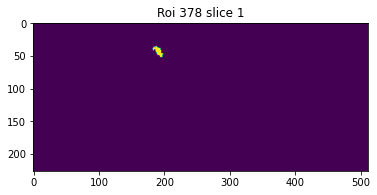

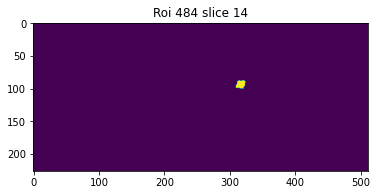

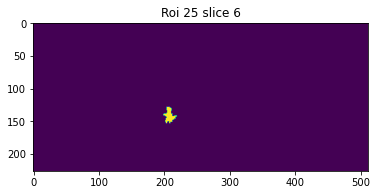

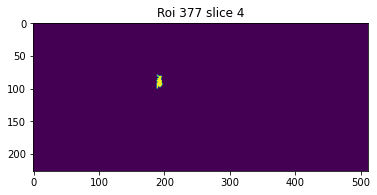

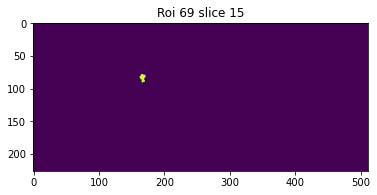

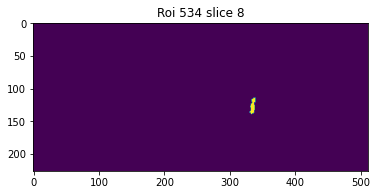

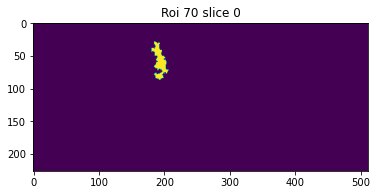

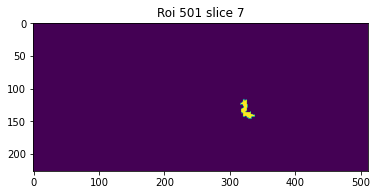

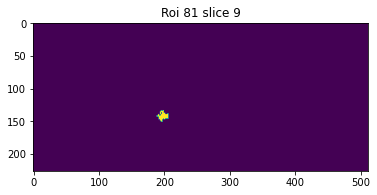

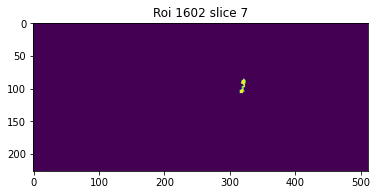

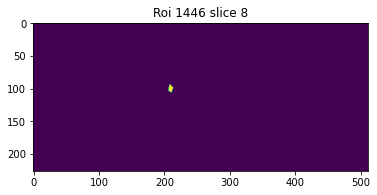

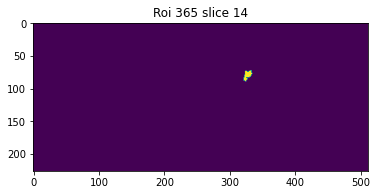

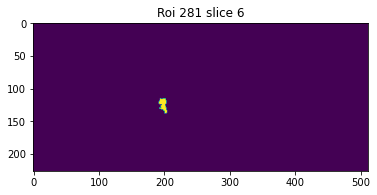

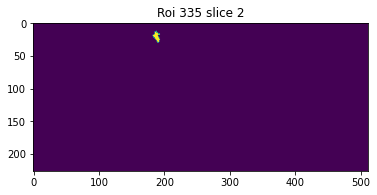

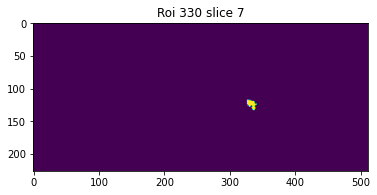

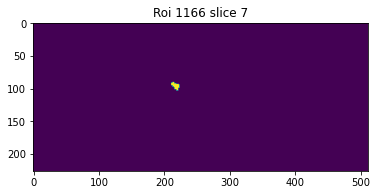

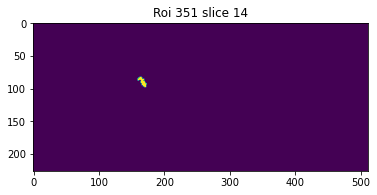

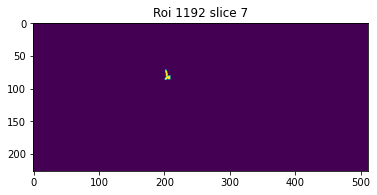

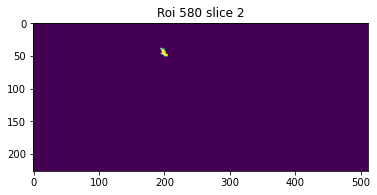

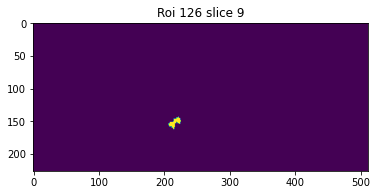

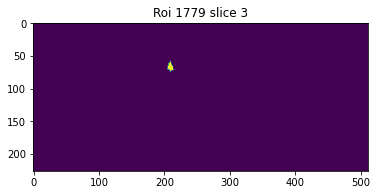

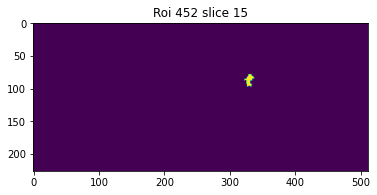

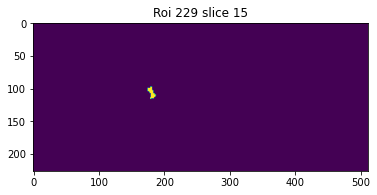

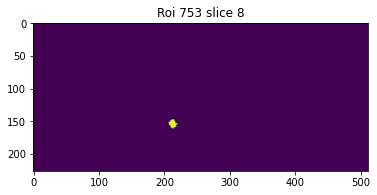

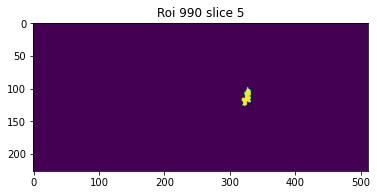

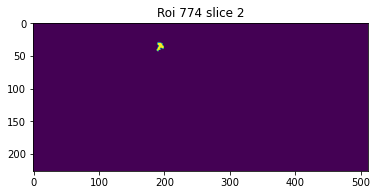

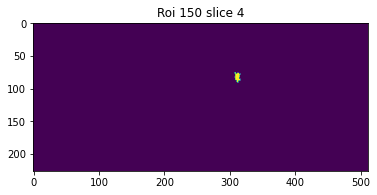

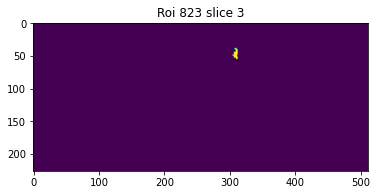

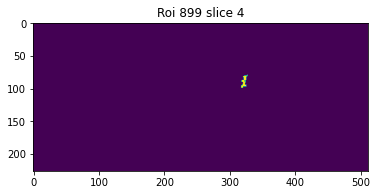

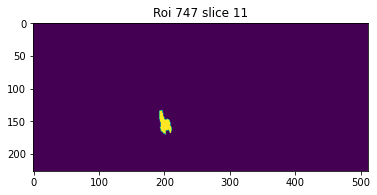

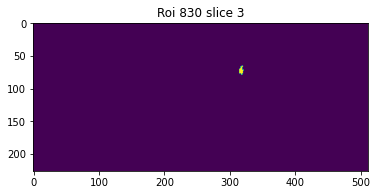

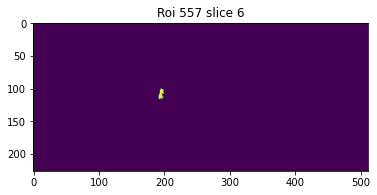

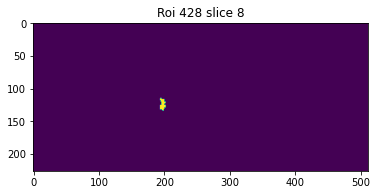

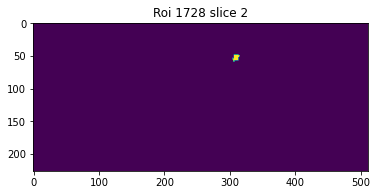

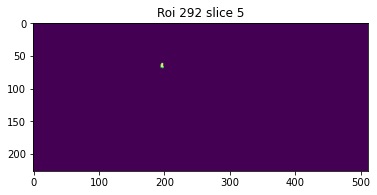

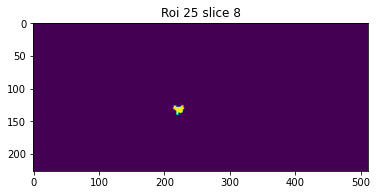

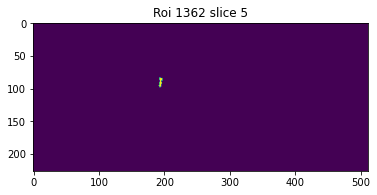

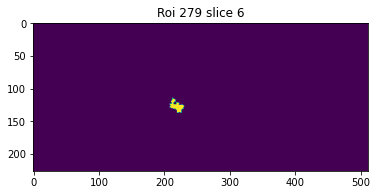

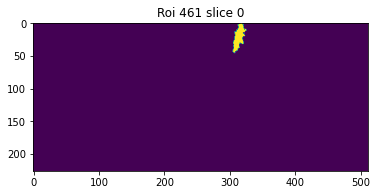

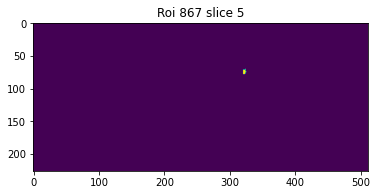

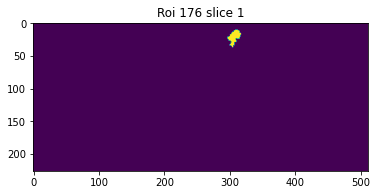

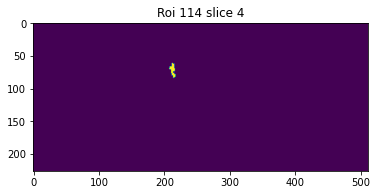

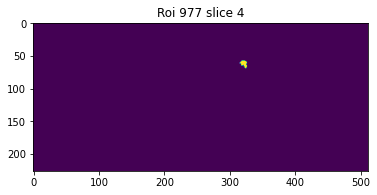

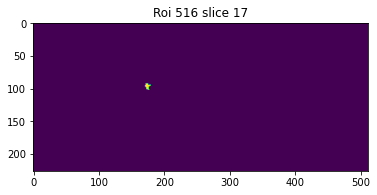

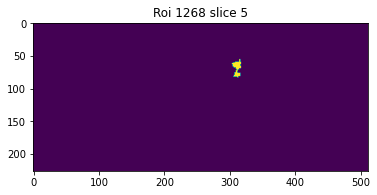

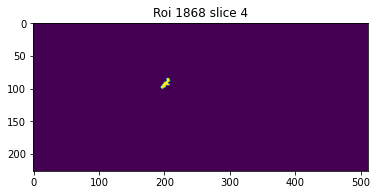

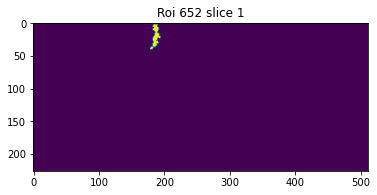

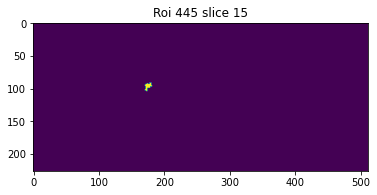

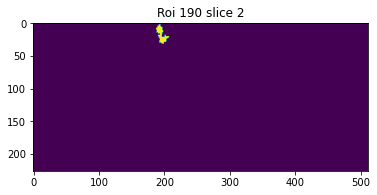

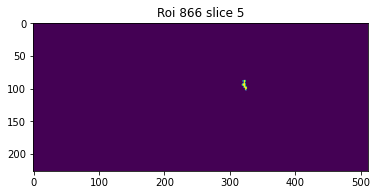

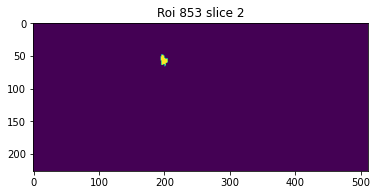

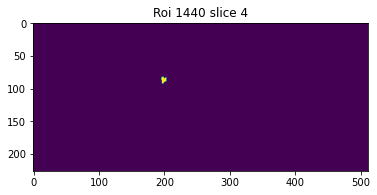

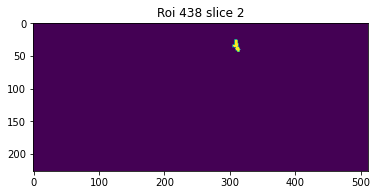

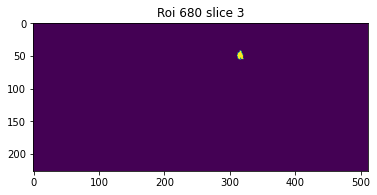

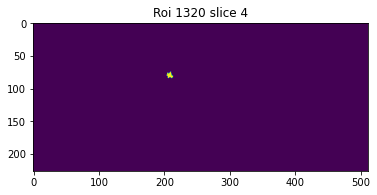

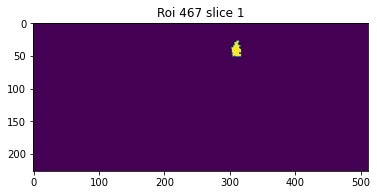

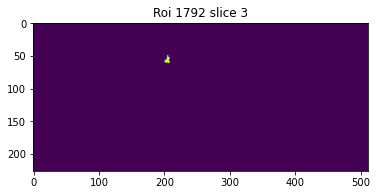

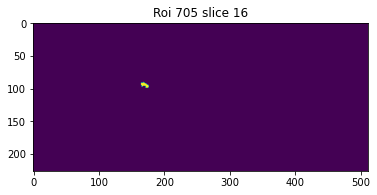

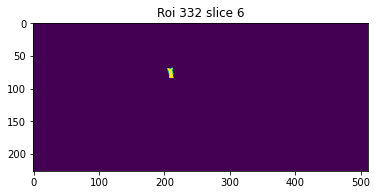

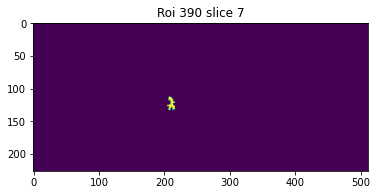

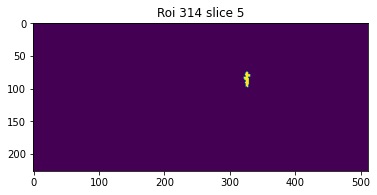

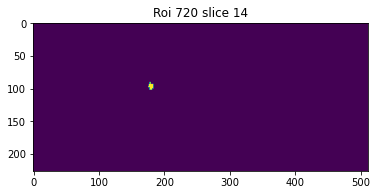

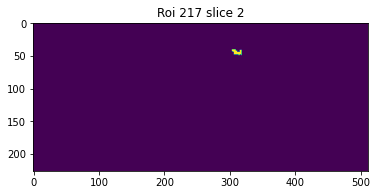

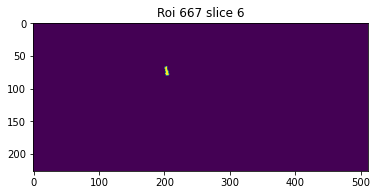

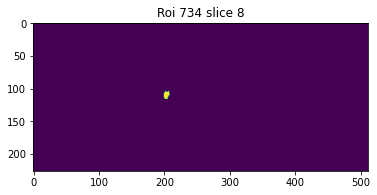

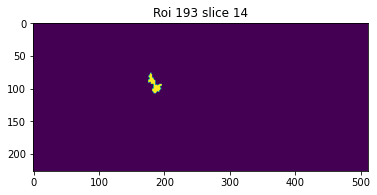

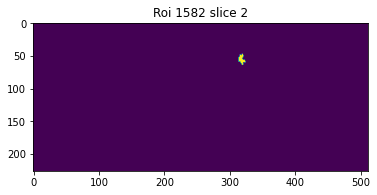

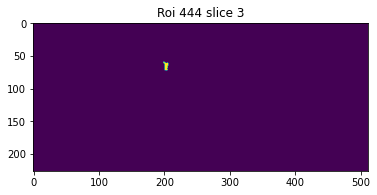

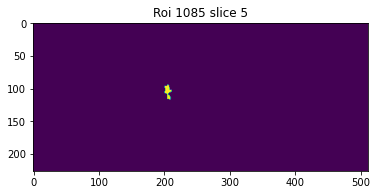

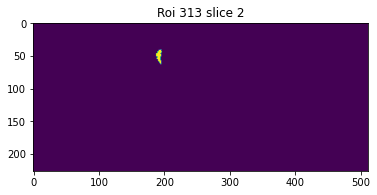

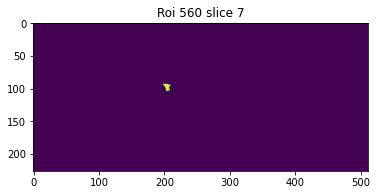

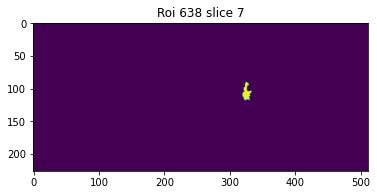

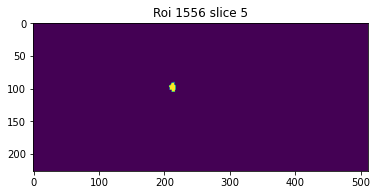

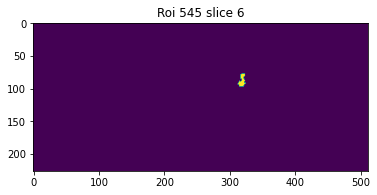

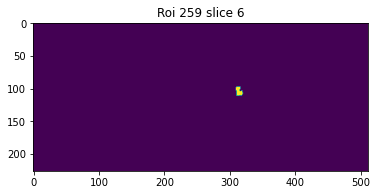

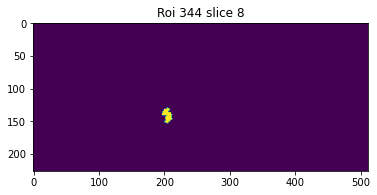

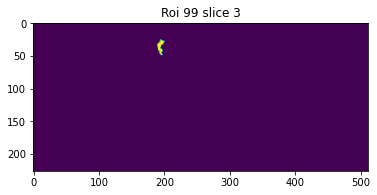

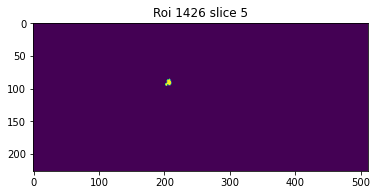

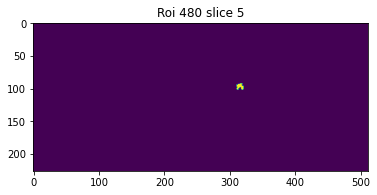

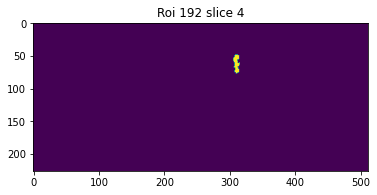

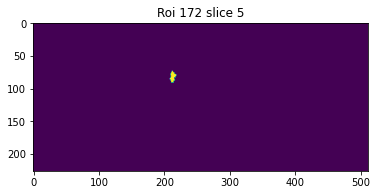

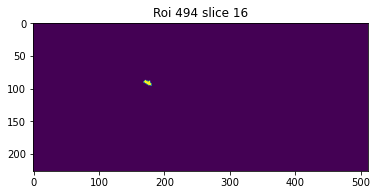

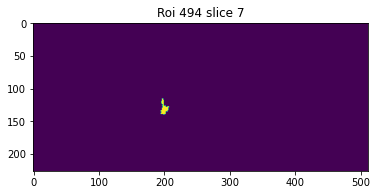

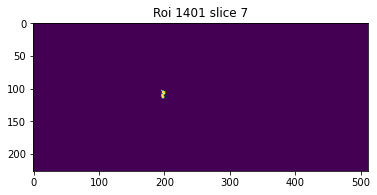

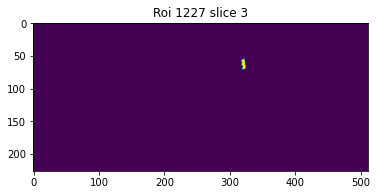

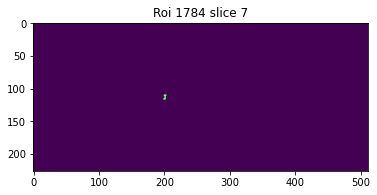

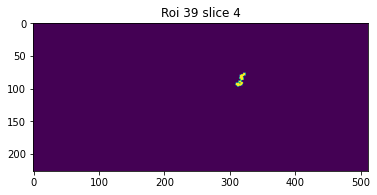

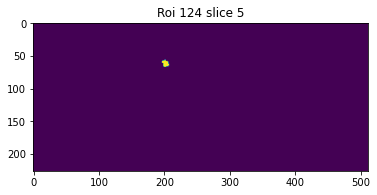

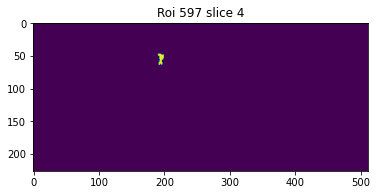

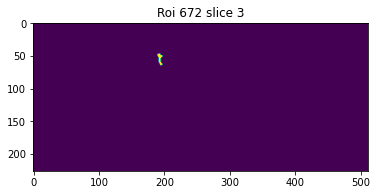

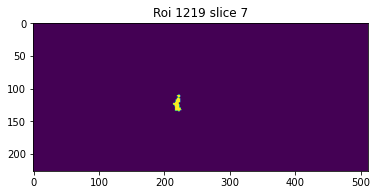

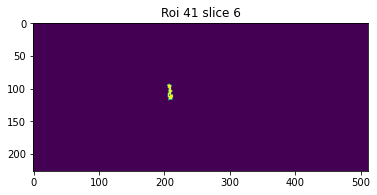

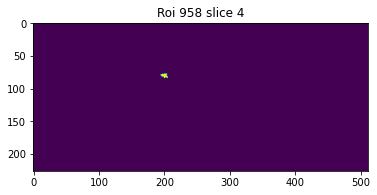

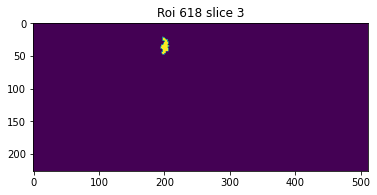

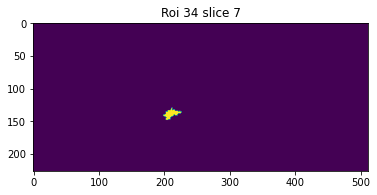

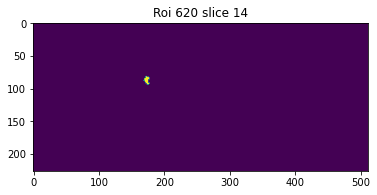

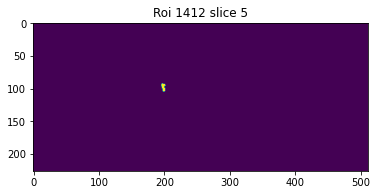

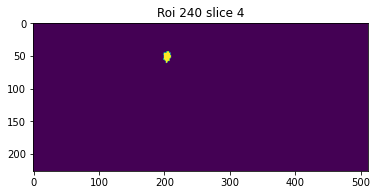

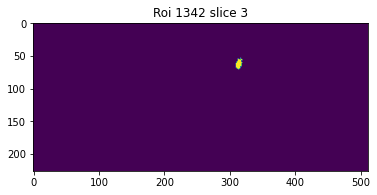

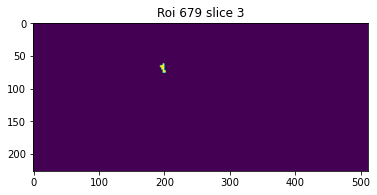

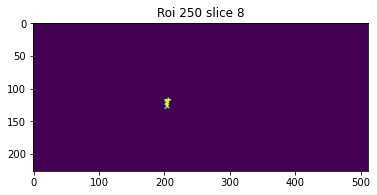

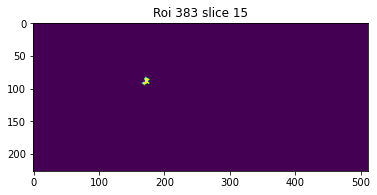

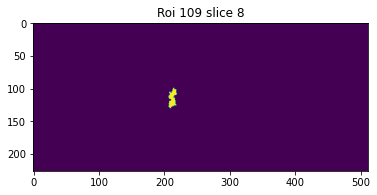

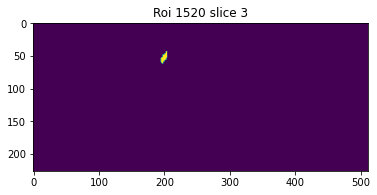

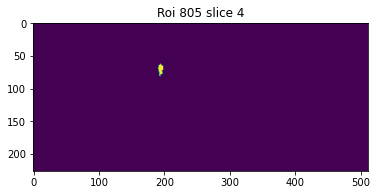

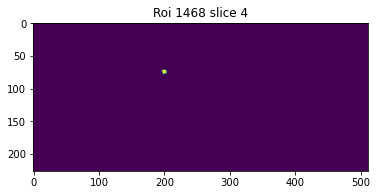

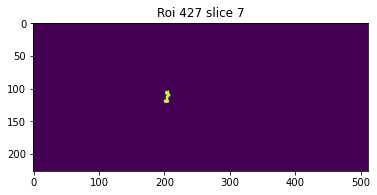

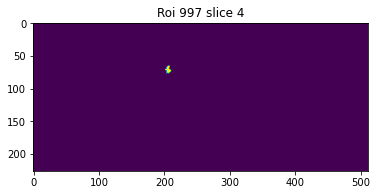

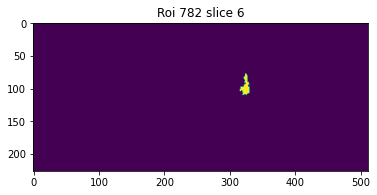

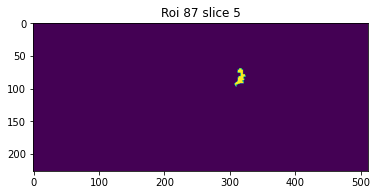

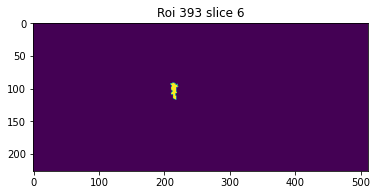

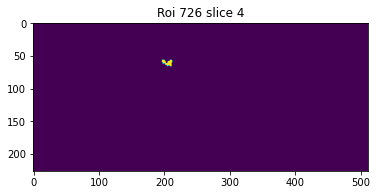

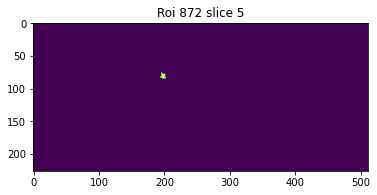

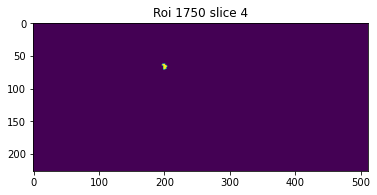

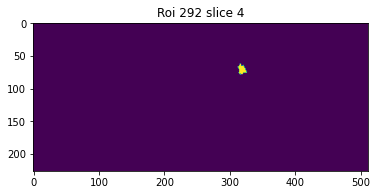

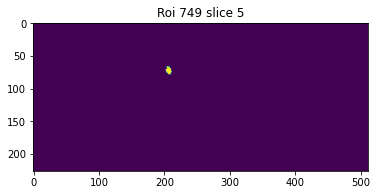

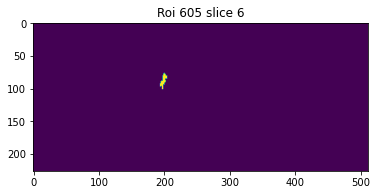

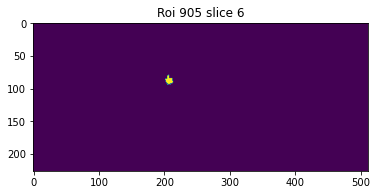

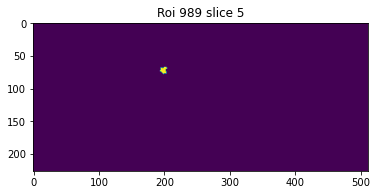

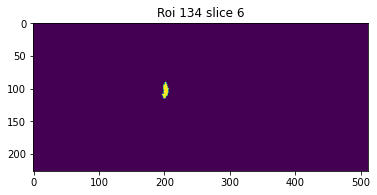

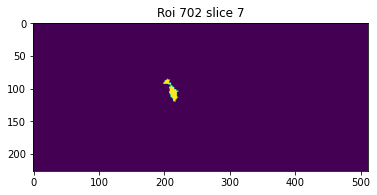

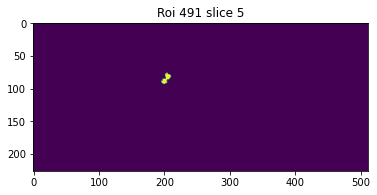

In [13]:
# sp
for i in np.arange(len(audio_correlated)):
    plt.figure()
    plt.imshow(roi_pos[:,:,slice_audio[i]]==roi_audio[i])
    plt.title('Roi {} slice {}'.format(roi_audio[i],slice_audio[i]))
    

In [27]:
#### Extract ROIs that are within the brain only
audio_roi_inside = []
for slice_idx in range(0,np.size(roi_pos,2)):
    roi_ids_in_brain = audio_rois_masked[:,:,slice_idx][brain_mask[:,:,slice_idx] == 1]
    unique_roi_ids_in_brain = np.unique(roi_ids_in_brain)
    audio_roi_inside.append(np.ma.getdata(unique_roi_ids_in_brain)+(slice_idx*1000) )


In [28]:
audio_roi_inside = np.sort(np.concatenate([arr.ravel() for arr in audio_roi_inside]))

In [29]:
df = DataFrame(audio_roi_inside.T, columns = ['ROI'])
df.to_csv('D:/Wayan/LightBead/method paper/dico data/slices/zscored/60Hz/audio_roi_06192024_a1_r1_abs30_posCorr_inside.csv')

<ipython-input-54-c68ccec06323>:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(frameon=False)


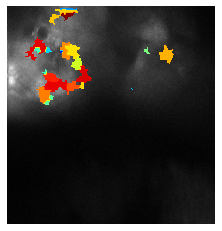

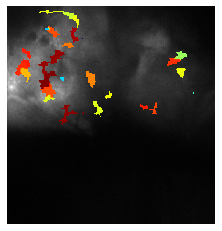

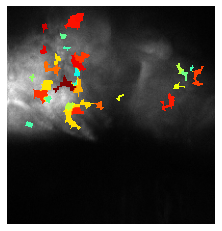

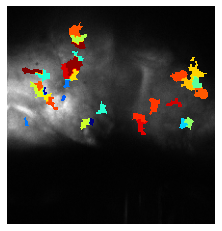

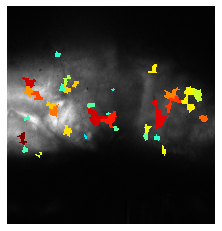

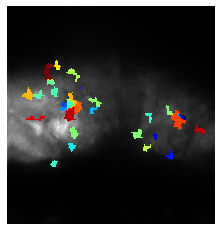

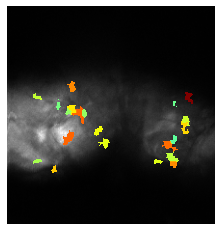

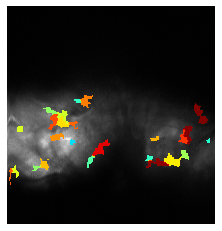

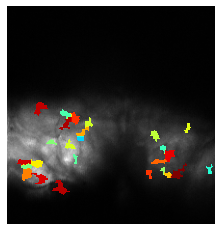

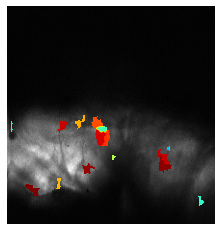

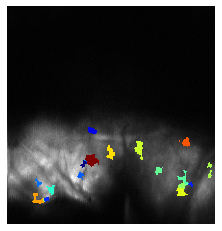

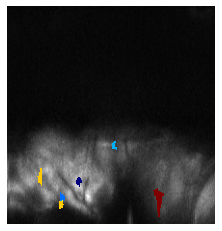

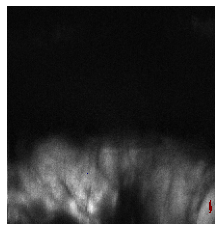

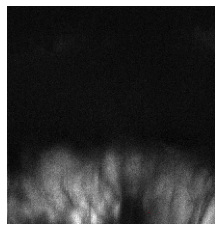

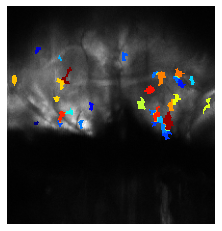

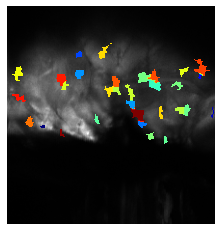

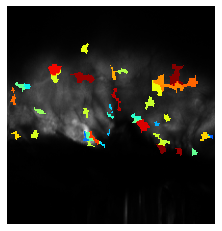

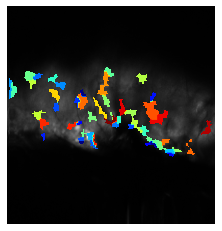

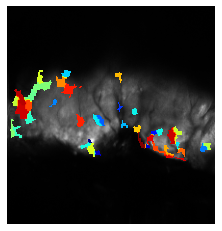

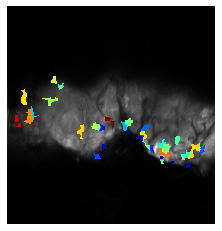

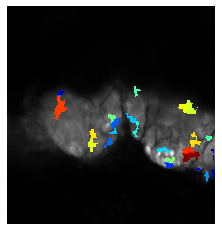

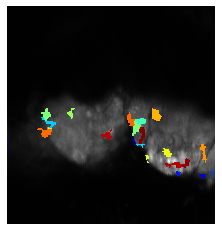

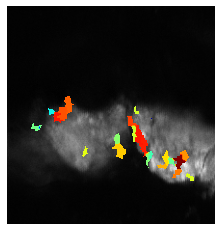

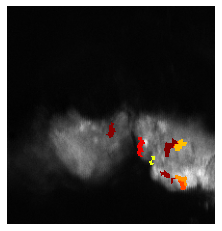

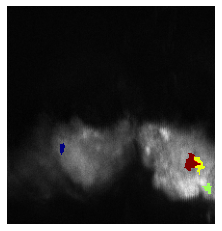

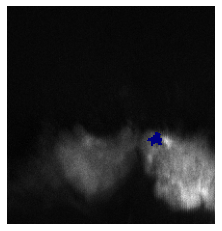

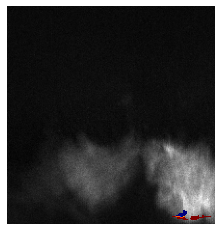

In [54]:
# Plot all audio-correlated rois for each slice
#path = 'D:/Wayan/LightBead/method paper/dico data/slices/zscored/RigE/1000/plots/12132024_6f_a2_r3/top 05/'
path = 'D:/Wayan/LightBead/method paper/dico data/slices/zscored/60Hz/06202024_a1_r2/'
for slice_idx in range(np.size(roi_pos,2)):
    matplotlib.rcParams['pdf.fonttype']=42
    plt.figure(frameon=False)
    im1 = plt.imshow(volume_img[:,:,slice_idx],cmap = 'gray')
    
    im2 = plt.imshow(audio_rois_masked[:,:,slice_idx], alpha = 1, cmap = 'jet') # jet cool gist_rainbow  winter_r
    #plt.title('Roi {} slice {}'.format(roi_audio[i],slice_audio[i]))
    plt.axis('off')
    #plt.title(slice_idx)
    plt.savefig(path+str(slice_idx)+'.png',dpi = 300, pad_inches=0, bbox_inches='tight')